__Certificate in Python for Finance (CPF) Program__  
__Final Project: Algorithmic Trading__

__Author:__ Jürgen Kober  
__Date:__ 31. März 2026  
__Course:__ CPF Practice Project  
__Institution:__ The Python Quants (TPQ)

# End-to-End Cloud Deployment of Automated Trading Strategies with IBKR

## Abstract

This project presents the design, implementation, and cloud-based deployment of an end-to-end automated trading system for the EUR/USD currency pair, integrated with the Interactive Brokers platform. The system implements a trend-following strategy using a dual simple moving average crossover, with RSI and momentum indicators serving as entry filters to reduce false signals. The primary objective is to document a reproducible, production-ready pipeline that bridges the gap between vectorised backtesting and live execution on remote cloud infrastructure.

The project is structured around five phases: historical data acquisition via the Interactive Brokers API, technical indicator implementation using an extensible abstract base class architecture, signal generation and vectorised backtesting with full transaction cost modelling, parameter optimisation across a grid of 432 combinations, and live deployment via Docker containerisation on a DigitalOcean droplet. Strategy parameters were optimised separately for 5-minute and 4-hour timeframes. On the 4-hour timeframe, the optimal configuration (SMA 20/70, RSI 14 with thresholds 35/70) produced a Sharpe ratio of 1.42 and a cumulative return of 30.23% over the 2023–2025 backtest period across 45 trades. The 5-minute backtest is limited to a six-week data window and is treated as a proof-of-concept for the pipeline rather than a statistically robust strategy assessment.

Live deployment was validated through two production runs on a paper trading account. The 5-minute run (23–27 February 2026, 104.7 hours) completed 11 trades and demonstrated full infrastructure reliability: four nightly IB Gateway reboot cycles handled automatically, nine position reconciliation events resolved correctly, and zero crashes or manual interventions. A 4-hour run followed in early March 2026. The live results confirm that the system operates as designed under real broker conditions; strategy profitability over such short windows carries no statistical weight and is not the claim the project makes. The central finding is operational: a modular, configurable, autonomously reconnecting trading system can be built, tested, and deployed to cloud infrastructure using open-source Python tooling and the Interactive Brokers API.

**Keywords:** Algorithmic trading, trend-following strategy, forex, EUR/USD, backtesting, Python, Docker, cloud deployment, Interactive Brokers

#### Notebook Display Configuration

The following cell applies custom CSS styling to ensure tables in this notebook display correctly. By default, Jupyter renders tables with full width, which can cause formatting issues when multiple tables or mixed content appear in sequence. This styling forces tables to float left and clear subsequent content, ensuring clean presentation throughout the document.

In [1]:
%%html
<style>
table {float:left}
table + * {clear: both}
</style>

## 1. Project Setup

### 1.1 Trading Platform

#### Broker Selection Decision

After completing the initial exploration of forex trading platforms, several brokers were evaluated for automated trading in Germany. The criteria for selection were full regulation according to EU/BaFin standards, comprehensive Python API access, and a wide range of trading instruments. The choice fell on Interactive Brokers, which provides a tested platform for extensive currency pairs, has excellent Python API support (via the ib_async library), offers competitive fees and a wide instrument range, and is fully regulated in Germany.

Interactive Brokers (IBKR) is a global online brokerage firm headquartered in the United States. It provides direct access to a wide range of financial markets and instruments, including stocks, options, futures, bonds, and foreign exchange. It is known for its strong technological focus, low trading costs, and infrastructure that not only fulfills the needs of professional and institutional participants but is also suitable for retail traders.

The company was founded by Thomas Peterffy, one of the early pioneers of algorithmic trading. Starting as an architectural draftsman working on highway projects, he left this career path to trade equity options and apply his strategies to computerized trading models. He developed some of the first automated execution systems, thereby laying the groundwork for modern electronic markets. This technology-driven background is still visible today in Interactive Brokers' powerful trading platform and extensive API support.

For traders based in Europe—and especially in Germany—Interactive Brokers is a practical and reliable choice. The broker operates through regulated European entities and offers broad access to international markets. Compared to many alternatives, it complies with local financial regulations and provides competitive fees and transparent pricing. The main drawback is that it requires expensive data subscriptions for live streaming data of certain asset classes like stocks.

Features such as fully functional paper trading accounts and robust API connectivity make IBKR particularly well suited for algorithmic and systematic trading projects. Interactive Brokers combines regulatory reliability, global market access, and strong technical capabilities, making it a prime candidate for quantitative and algorithmic trading workflows.

#### The GUI Requirement Challenge

The key technical challenge with Interactive Brokers is that API access requires a GUI environment, either Trader Workstation (TWS) or IB Gateway. This approach presents several problems:

- Headless servers: Cloud instances don't have display environments
- 24/7 operations: Running locally requires keeping a computer on continuously
- Remote access: Difficult to access from different locations
- Stability: Interruptions of local networks affect trading operations

The solution that aligns with this project's requirements for a fully automated trading system was to deploy IB Gateway in a Docker container.

#### Cloud Instance Requirements Analysis

For IB Gateway deployment in a Docker container, the following requirements were identified:

__Technical Requirements:__
- Linux OS (Ubuntu preferred for compatibility)
- Sufficient RAM for Java process (IB Gateway is Java-based)
- Stable network connection
- Docker support

__Cost Considerations:__
- Must be more economical than running a local computer 24/7
- Predictable monthly costs
- Included bandwidth for trading data

__Geographic Considerations:__
- Low latency to Interactive Brokers servers
- European datacenter preferred (trading from Germany)

__Specifications of Selected Configuration (DigitalOcean Droplet):__
```
OS:          Ubuntu 22.04 LTS
Plan:        Basic $12/month
Resources:   2 GB RAM / 1 CPU / 50 GB SSD
Datacenter:  Frankfurt, Germany
Transfer:    2 TB included
````
Ubuntu 22.04 LTS was chosen for its long-term support, excellent Docker compatibility, and extensive documentation. Since Java processes can be memory-intensive, the 1 GB RAM option was deemed insufficient, leading to the selection of 2 GB RAM.

Frankfurt was selected as the datacenter location because, being located in Germany, a datacenter with the lowest latency from Germany and proximity to IB's European servers was needed. The $12/month tier provides reasonable costs while guaranteeing better performance and stability — much cheaper than running a computer or laptop at home 24/7.

### 1.2 Initial Server Setup

#### Phase 1: Droplet Creation

After setting up a DigitalOcean account, a droplet needs to be created with the previously described configuration. This involves:

- Selecting Ubuntu 22.04 LTS image
- Choosing Basic plan with 2 GB RAM
- Selecting Frankfurt datacenter
- Adding SSH public key for authentication
- Naming droplet: ib-gateway-server

To connect to the droplet from a local machine, an SSH key needs to be generated first:
```
# Generate SSH key on Mac terminal
ssh-keygen -t ed25519 -C "your_email@example.com"
   
# Display public key
cat ~/.ssh/id_ed25519.pub
```

Ed25519 is a modern, high-security digital signature algorithm based on elliptic curve cryptography, specifically designed for speed, safety, and resistance to common implementation flaws. It's faster and more secure than older RSA keys, making it the recommended choice for SSH authentication.

__Note:__ In the following descriptions, the actual IP address of the cloud instance (provided by DigitalOcean) will be replaced with XXX.XXX.XXX.XX for security reasons.

#### Phase 2: Initial Server Configuration

Once the droplet is created and accessible, the server needs to be secured and prepared for Docker deployment.

__1. Connecting to droplet via SSH:__
```
# Connect to new droplet
ssh root@XXX.XXX.XXX.XX
```

__2. Updating the operating system:__
```
# Update package lists
apt update
   
# Upgrade installed packages
apt upgrade -y
   
# Install useful tools
apt install -y curl wget vim net-tools
```

__3. Setting up a firewall:__
```
# Install firewall
apt install -y ufw
   
# Allow SSH (critical - don't lock yourself out!)
ufw allow 22/tcp
   
# Enable firewall
ufw enable
   
# Check status
ufw status
```
Expected output:
```
Status: active

To                         Action      From
--                         ------      ----
22/tcp                     ALLOW       Anywhere
````
Initially, restricting SSH access to a specific IP address was considered. However, with a dynamic home IP, keeping SSH open with key authentication proved to be a more practical solution while still maintaining strong security.

#### Phase 3: Docker Installation

Docker is required to run IB Gateway in a containerized environment, providing isolation and easy management of the application.

__1. Installing Docker:__
```
# Download Docker installation script
curl -fsSL https://get.docker.com -o get-docker.sh
   
# Run installation script
sh get-docker.sh
   
# Verify installation
docker --version
```
Expected output: `Docker version 24.0.x, build xxxxxxx`

__2. Testing Docker__
```
# Run test container
docker run hello-world
```
If Docker is properly installed, this command will download a test image and display a "Hello from Docker!" message confirming that the installation is working correctly.

### 1.3 IB Gateway Container Deployment

#### Phase 1: Docker Image Selection

After researching available IB Gateway Docker images, `ghcr.io/unusualalpha/ib-gateway:latest` was found to be the most suitable and robust option. The selected image:

- Is the most popular and actively maintained
- Handles xvfb (virtual display) automatically
- Includes IBC (Interactive Brokers Controller) for automation
- Is well-documented and widely used in the community
- Has regular updates to match IB Gateway releases

#### Phase 2: Credentials Configuration

__1. Creating configuration directory:__
```
mkdir -p ~/ib-config
cd ~/ib-config
```

__2. Creating credentials file:__
```
nano ib-credentials.env
```
File contents of `ib-credentials.env`:
```
TWS_USERID=your_ib_username
TWS_PASSWORD=your_ib_password
TRADING_MODE=paper
VNC_SERVER_PASSWORD=your_vnc_password
```
Explanation of parameters:
- TWS_USERID: Interactive Brokers username
- TWS_PASSWORD: Interactive Brokers password
- TRADING_MODE: paper for paper trading, live for real trading
- VNC_SERVER_PASSWORD: Password for VNC remote desktop access

__3. Securing credentials file:__
```
# Set restrictive permissions (owner read/write only)
chmod 600 ib-credentials.env
   
# Verify permissions
ls -la ib-credentials.env
# Should show: -rw------- 1 root root
```

#### Phase 3: Container Deployment

__1. Pulling the Docker image:__
```
docker pull ghcr.io/unusualalpha/ib-gateway:latest
```

__2. Running the IB Gateway container:__
```
docker run -d \
     --name ib-gateway \
     --restart unless-stopped \
     -p 4001:4001 \
     -p 4002:4002 \
     -p 5900:5900 \
     --env-file ~/ib-config/ib-credentials.env \
     ghcr.io/unusualalpha/ib-gateway:latest
```
Breakdown of Docker commands:
- `-d`: Run in detached mode (background)
- `--name ib-gateway`: Name the container for easy reference
- `--restart unless-stopped`: Auto-restart on failures or system reboot
- `-p 4001:4001`: Paper trading API port
- `-p 4002:4002`: Live trading API port
- `-p 5900:5900`: VNC port for GUI access
- `--env-file`: Load credentials from secure file

__3. Verifying container is running:__
```
# Check container status
docker ps
   
# Should show ib-gateway with STATUS "Up"
```

__4. Monitoring startup logs:__
```
# View logs
docker logs ib-gateway
   
# Follow logs in real-time
docker logs -f ib-gateway
```
Expected log messages:

- "IBC: Starting Gateway"
- "IBC: Detected frame entitled: IBKR Gateway"
- "IBC: Login attempt"
- "IBC: Login has completed"

#### Phase 4: Initial Configuration via VNC

At this stage of the configuration process, first-time paper trading accounts require the configuration of certain API settings through the GUI interface. To accomplish this, it is necessary to connect to the IB Gateway instance running on the droplet from a local computer (in this case, a Mac) via VNC.

__1. Connecting to VNC from local Mac:__
- Opening Finder
- Pressing Cmd+K
- Entering server address: vnc://XXX.XXX.XXX.XX:5900
- Entering VNC password (from credentials file)

__2. Verify API Settings:__
Once connected, navigate to: Configure → Settings → API → Settings
- Verify the following settings:
  - Socket port: 4002 (for live) or 4001 (for paper)
  - Trusted IPs includes 127.0.0.1
  - "Read-Only API" is _unchecked_
  - "Allow connections from localhost only" is _unchecked_

#### Phase 5: Connection Architecture and SSH Tunnel

__The IPv4/IPv6 Challenge__  
Initial attempts to connect directly from Mac to droplet failed due to IPv4/IPv6 networking issues between Docker, the host OS, and the remote client.

__Technical Details:__
- IB Gateway Java process was binding to IPv6 (:::4002)
- Mac's ib_async was attempting IPv4 connection
- Docker bridge networking added complexity
- Firewall considerations created additional challenges

__SSH Tunnel Solution__  
After researching solutions, SSH tunneling emerged as the recommended approach for remote IB Gateway access. This method not only bypasses networking issues but also provides enhanced security compared to direct connections.

__How It Works:__
```
Local Mac:4002 → SSH Tunnel → Server:22 → Server:localhost:4002 → IB Gateway
```

__Implementation:__

__1. Creating an SSH tunnel on local computer__
```
# -4 forces IPv4
# -L creates local port forwarding
ssh -4 -L 4002:127.0.0.1:4002 root@XXX.XXX.XXX.XX
```

The terminal window where the tunnel is running needs to be kept open. Closing it terminates the tunnel.

__2. Connecting to the tunnel from a Python script:__
```
# Connect to localhost (tunneled to server)
from ib_async import *

# Create IB connection object
ib = IB()
ib.connect('127.0.0.1', 4002, clientId=1, timeout=20)

# Verify connection
print(f"Connected: {ib.isConnected()}")
```
Expected output:
```
Connected: True
```

__Security Benefits of SSH Tunnel:__
The SSH tunnel approach provides security advantages that make it superior to direct port exposure. First, all communication between the local machine and the server is encrypted through the SSH protocol, protecting sensitive trading data and credentials from interception. This encryption applies to the entire data stream, including API commands and market data.

Second, the tunnel eliminates the need to expose IB Gateway ports (4001, 4002) directly to the internet. Instead, only the SSH port (22) needs to be accessible, significantly reducing the attack surface. Any attempt to access the trading API must first authenticate through SSH using key-based authentication, adding an additional security layer that port-based connections lack.

Third, this architecture provides flexibility regardless of network configuration. Whether dealing with IPv4/IPv6 issues, NAT traversal, or Docker networking complexities, the SSH tunnel creates a reliable connection path. This is why SSH tunneling is considered standard practice among professional trading firms for remote gateway access — it combines robust security with practical reliability.

__3. Final Firewall Configuration:__
```
# Only SSH port exposed
ufw status
```
Expected output:
```
Status: active

To                         Action      From
--                         ------      ----
22/tcp                     ALLOW       Anywhere
22/tcp (v6)                ALLOW       Anywhere (v6)
```

#### Conclusion

This deployment successfully established a production-grade infrastructure for automated trading. The IB Gateway now runs continuously on the DigitalOcean droplet, independent of any local computer, providing true 24/7 operation. The multi-layered security architecture—combining SSH key authentication, firewall restrictions, and encrypted tunneling—ensures that trading operations are protected while remaining accessible from any location with SSH access.

The financial benefits are substantial: at \\$12 per month, the cloud-based solution costs significantly less than running a local computer continuously, which would consume \\$50-100 monthly in electricity and wear. Docker's automatic restart capability ensures the gateway remains operational even after system updates or unexpected failures, eliminating the need for manual intervention.

Perhaps most importantly, this architecture is not merely a proof-of-concept but represents the same approach used by professional trading firms. The combination of containerization, secure remote access, and reliable cloud infrastructure creates a foundation suitable for both development and production trading environments. The system is now ready to support automated trading strategies with the reliability and security that real-world trading demands.

## 2. Strategic Decisions

### 2.1 Choice of Instrument

As the trading instrument, the EUR/USD currency pair is chosen. The focus is on direct foreign exchange trading rather than CFDs, because this allows to put a greater emphasis on macroeconomic factors and geopolitical events that have a direct influence on currency values. Given the current political situation between Europe and the United States, this currency pair is expected to show a high level of unpredictability and volatility, making it particularly interesting to trade in the near future. From a practical perspective, forex trading is available immediately within my Interactive Brokers' account setup and does not require costly subscriptions for live market data.

### 2.2 Trading Data

For the backtesting task, historical data for the EUR/USD currency pair is obtained from Interactive Brokers with the `EClient.reqHistoricalData` API method.

### 2.3 Simple Moving Average Selection for Multi-Timeframe Strategy

#### Trading Style Classification

This project employs a multi-timeframe approach that spans two distinct trading styles: __day trading__ and __swing trading__. Day trading involves opening and closing positions within the same trading day (or within hours), capitalizing on intraday price movements. Swing trading, by contrast, holds positions for multiple days to weeks, aiming to capture larger price swings driven by medium-term trends (Elder, 1993).

The distinction between these styles is critical because each requires different analytical tools, position sizing, and — most importantly for this project — different moving average periods to filter market noise and identify meaningful trends.

#### Timeframe Classifications

This strategy implements three distinct timeframes, each aligned with a specific trading style:

| Timeframe | Trading Style | Expected Hold Time |
|-----------|---------------|-------------------|
| 5-minute | Day trading (scalping/intraday) | Minutes to hours |
| 4-hour | Day trading | Hours (same day) |
| Daily | Swing trading | Days to weeks |  

__Note on scalping:__ Scalping is an ultra-short-term subset of day trading where traders execute dozens or even hundreds of trades per day, holding positions for seconds to minutes, targeting small price movements of just a few pips. The 5-minute timeframe falls into this category when positions are closed within minutes.

#### Why Different Timeframes Require Different MA Periods

Moving averages smooth price data by calculating the average closing price over a specified number of periods. The "period" is relative to the chart timeframe: on a 5-minute chart, a 20-period SMA represents 100 minutes of price data, while on a daily chart, it represents 20 trading days (approximately one month).

Different timeframes exhibit different levels of price noise and trend characteristics:

- __5-minute charts__ contain significant intraday volatility and "noise" (random price fluctuations unrelated to meaningful trends)
- __4-hour charts__ filter out some intraday noise while still capturing same-day price movements
- __Daily charts__ smooth out intraday volatility entirely, revealing only sustained multi-day trends

Consequently, the optimal MA periods must be calibrated to each timeframe to balance two competing objectives: (1) responsiveness to genuine price changes, and (2) filtration of meaningless noise.

#### Literature-Backed SMA Periods by Timeframe

The academic literature on moving average strategies is predominantly concerned with daily and longer timeframes. Peer-reviewed guidance on specific SMA periods for intraday bars — 5-minute or 4-hour — is limited, and the practitioner sources cited reflect trading community convention rather than rigorous empirical validation. The periods selected here serve as a structured starting point; the final parameters used in the strategy (SMA 15/70 for the 5-minute timeframe, SMA 20/70 for the 4-hour timeframe) were determined by grid search optimisation over historical EUR/USD data rather than by literature prescription. 

This section documents the literature-backed starting point before optimisation; the optimisation results and final parameters are documented in Section 6.

__1. Five-Minute Chart (Day Trading/Scalping)__

__Selected Periods: SMA 20 / SMA 50__

__Rationale and Citations:__
- Empirical testing by Forex.in.rs (2022) across 72 combinations on six major USD forex pairs (EUR/USD, GBP/USD, USD/JPY, AUD/USD, USD/CAD, NZD/USD) over 10 years identified the __20/50 SMA combination as optimal for 5-minute charts__
- FXOpen (2025) recommends the 20-period moving average as best suited for 5-minute forex scalping strategies
- Alternative combinations documented in practitioner literature include 10/50 and 5/8/13 (Fibonacci-based), but 20/50 provides the most robust empirical support

__2. Four-Hour Chart (Day Trading)__

__Selected Periods: SMA 20 / SMA 50__

__Rationale and Citations:__
- The 4-hour timeframe is widely documented as a swing trading timeframe in academic and practitioner literature, but is also extensively used by day traders seeking to reduce intraday noise while maintaining same-day position management (Olar, 2023; VectorVest, 2025)
- Multiple trading education sources identify __20/50 SMA as the standard combination for 4-hour charts__, with the 200 SMA often added as a long-term trend filter (Mind Math Money, 2025)
- Rayner Teo, a widely-cited technical analyst, states: "I stick to 20, 50 and 200ma and use it across all timeframes" (Teo, 2024)

__3. Daily Chart (Swing Trading)__

__Selected Periods: SMA 50 / SMA 200__

__Rationale and Citations:__
- The __50/200 SMA crossover__ is one of the most widely followed technical indicators in financial markets, commonly known as the "Golden Cross" (bullish signal when 50 SMA crosses above 200 SMA) and "Death Cross" (bearish signal when it crosses below)
- Murphy (1999) in *Technical Analysis of the Financial Markets* — considered the definitive reference text on technical analysis—states: "The most commonly watched averages in stocks are 50 and 200 days" (p. 206)
- Elder (1993) in *Trading for a Living* discusses the use of moving averages for swing and position trading, emphasizing their role in trend identification across daily and weekly timeframes
- The 50/200 combination is ubiquitous in institutional trading and appears as default settings in most professional charting platforms like TradingView, Bloomberg Terminal or MetaTrader.

#### Summary Framework

The selected SMA periods follow established conventions in technical analysis literature and empirical forex trading research:

| Timeframe | Fast SMA | Slow SMA | Ratio | Primary Reference |
|-----------|----------|----------|-------|-------------------|
| __5-min__ | 20 | 50 | 1:2.5 | Forex.in.rs (2022) |
| __4-hour__ | 20 | 50 | 1:2.5 | Teo (2024); Olar (2023) |
| __Daily__ | 50 | 200 | 1:4 | Murphy (1999); Elder (1993) |

Note that the __20/50 ratio (1:2.5)__ is maintained across both intraday timeframes, providing consistency in the relative spacing between fast and slow averages. This ratio has been empirically validated through extensive backtesting on forex pairs. The daily chart employs the industry-standard __50/200 ratio (1:4)__, which has decades of documented use in both academic literature and professional trading practice.

#### Considerations for Implementation

While these SMA periods are well-supported by literature, it is important to acknowledge a limitation inherent to all moving average crossover strategies: __the tendency to generate false signals in ranging (sideways) markets__, commonly called "whipsawing." This occurs when price oscillates around the moving averages without establishing a clear trend, resulting in frequent crossover signals that quickly reverse. Academic research has demonstrated that transaction costs from excessive trading can erode or eliminate profitability in such conditions (Glabadanidis et al., 2023; Hutchinson et al., 2022).

To address this limitation, the strategy incorporates additional confirmation indicators (RSI and Momentum), discussed in the following section.

### 2.4 Confirmation Filters - RSI and Momentum Parameter Selection

#### The Whipsawing Problem and Multi-Indicator Solution

As noted in the previous section, simple moving average crossover strategies are vulnerable to generating false signals in ranging or sideways markets — a phenomenon known as "whipsawing." This occurs when price oscillates around the moving averages without establishing a clear directional trend, producing frequent crossover signals that quickly reverse. The result is excessive trading activity that erodes profitability through accumulated transaction costs.

Academic research has consistently demonstrated that technical trading strategies, while showing promise in trending markets, often fail when realistic transaction costs are included (Glabadanidis et al., 2023). Studies show returns from MA strategies are "very sensitive to the introduction of moderate transaction costs," with performance degrading significantly when tested out-of-sample (Hutchinson et al., 2022). The core problem is that MA crossovers alone cannot distinguish between genuine trend changes and temporary price fluctuations.

To address this limitation, this strategy employs a __multi-indicator confirmation approach__ that requires alignment across three separate technical indicators before generating trade signals. This filtering methodology is well-established in practitioner literature: "RSI is very difficult to use without using other technical analysis tools because the indicator tends to produce false signals when market conditions change. Thus, it is advisable not to rely solely on RSI but to use it as a complementary tool" (FTMO Academy, 2025). Similarly, multiple sources emphasize that "momentum indicators should not be used alone and should be combined with other forms of analysis for more informed decision-making" (Vawda, 2024).

### 2.5 Technical Indicators: RSI and Momentum

#### Relative Strength Index (RSI)

The Relative Strength Index (RSI) is a momentum oscillator developed by J. Welles Wilder in 1978 that measures the speed and magnitude of recent price changes. The indicator oscillates between 0 and 100, with traditional interpretation suggesting values above 70 indicate overbought conditions (potential downward reversal) and values below 30 indicate oversold conditions (potential upward reversal).

__Conceptual Role in the Strategy:__

RSI serves as a __momentum confirmation filter__ in this strategy. Rather than using RSI's traditional overbought/oversold signals as standalone trade triggers, the strategy requires RSI to confirm that sufficient momentum exists in the direction indicated by the MA crossover. This approach aligns with established best practices: "The indicator is best used to confirm a price action trading strategy, instead of using it to find trade signals on its own" (Elearnmarkets, 2025).

__Key Consideration - False Signals in Trending Markets:__

An important limitation of RSI is that it can remain in overbought or oversold territory for extended periods during strong trends. As Vawda (2024) notes: "In trending market conditions, the RSI can stay in the overbought or oversold zones for extended periods... taking a trade while the RSI is in these zones could result in a 'false signal' due to trading against the trend." This is precisely why RSI must be used in conjunction with trend-following indicators (MA crossovers) rather than in isolation.

#### Momentum Indicator

The Momentum indicator measures the rate-of-change (ROC) in an asset's price over a specified lookback period. It is calculated by subtracting the closing price n periods ago from the current closing price. A positive momentum value indicates upward price acceleration, while a negative value indicates downward acceleration.

__Conceptual Role in the Strategy:__

Momentum serves as a __directional strength validator__ that confirms whether price movement has genuine force behind it. The conventional interpretation treats positive momentum — price currently higher than N periods ago — as supporting a bullish bias, and negative momentum as supporting a bearish bias, with sustained readings above or below zero carrying more weight than brief crossings (Murphy, 1999). By requiring positive momentum for long signals and negative momentum for short signals, the strategy filters out weak or ambiguous price movements that are more likely to reverse.

The combination of RSI (momentum magnitude) and Momentum (directional strength) provides complementary confirmation: RSI ensures sufficient momentum exists, while Momentum validates the direction. As Joe Mazzola notes: "While RSI, MACD, and ADX values can help gauge a trend's strength, they may be more informative when combined with other confirming signals" (Mazzola, 2025).

#### Parameter Selection Methodology

Rather than using default or arbitrary indicator parameters, this project adopts a __systematic parameter optimization approach__ through backtesting. This methodology aligns with quantitative trading best practices and ensures parameters are calibrated to the specific characteristics of EUR/USD forex data.

#### Approach to Parameter Selection

1. __RSI Period and Thresholds:__
   - __Standard period:__ 14 periods (Wilder's original specification, widely used across all timeframes)
   - __Threshold levels:__ Will be systematically tested across a range (e.g., 30/70, 40/60, 20/80)
   - __Rationale:__ "For more volatile assets like foreign exchange, traders may raise the thresholds to 80/20 to try and filter out false signals" (Solanki, 2021)  
&nbsp;  
2. __Momentum Lookback Period:__
   - __Time-proportional scaling:__ Lookback periods will be scaled relative to the SMA periods for each timeframe
   - __Example logic:__ If using SMA 20/50 on 5-minute charts, momentum might use a 10-period lookback (half the fast SMA)
   - __Testing range:__ Multiple lookback values will be tested to find optimal performance  
&nbsp;  
3. __Optimization Constraints:__
   - Parameters will be optimized across the full historical dataset and validated through live paper trading
   - The strategy prioritizes parameter sets that show consistent performance and parameter stability
   - Transaction costs will be explicitly included in all backtesting to ensure real-world viability

#### Strategic Framework Summary

The multi-indicator approach employs three confirmation layers:

1. __Moving Average Crossover__ → Identifies trend direction
2. __RSI Filter__ → Confirms sufficient momentum magnitude
3. __Momentum Filter__ → Validates directional strength

A trade signal is generated only when all three indicators align, significantly reducing false signals compared to MA crossovers alone. This conservative approach accepts fewer trade opportunities in exchange for higher-quality signals and lower transaction costs.

#### Transition to Implementation

With the conceptual framework established, the next phase involves implementing this multi-indicator strategy in Python and conducting systematic backtesting across the selected timeframes (5-minute, 4-hour and 1-day). The backtesting process will:

- Determine optimal RSI thresholds and Momentum parameters for each timeframe through grid search
- Measure strategy performance using risk-adjusted metrics (Sharpe ratio, maximum drawdown, win rate)
- Compare multi-timeframe performance to assess which trading style (day trading vs. swing trading) proves most effective for this approach
- Validate the optimized parameters through live paper trading deployment

### 2.6 Backtesting Methodology & Performance Metrics

Before implementing the multi-indicator strategy, it is essential to establish a rigorous backtesting framework that ensures results are both meaningful and resistant to statistical artifacts. This section outlines the methodological approach for evaluating strategy performance, including the optimization approach, transaction cost modeling, and the specific metrics used to assess profitability and risk.

#### Optimization Approach

This project employs a __full in-sample grid search optimization__ across the complete historical dataset for each timeframe (Pardo, 2008). For each timeframe, all retrieved data is used to search for the parameter combination that maximizes risk-adjusted returns.

__Methodology:__

- __Optimization Period:__
    - 5-minute: December 29, 2025 – February 10, 2026 (~6 weeks, 8,372 bars)
    - 4-hour: February 12, 2023 – February 10, 2026 (~3 years, 5,421 bars)
    - Daily: February 13, 2023 – February 10, 2026 (~3 years, 776 bars)
- __Search Method:__ Exhaustive grid search across all valid parameter combinations
- __Objective Function:__ Maximize Sharpe Ratio (primary), with minimum trade count as a filter
- __No train-test split:__ Parameters are selected based on in-sample performance across the entire dataset

This approach was chosen for several practical reasons:

1. __Data availability:__ The 5-minute dataset covers only \~6 weeks of data — a constraint imposed by Interactive Brokers' single-request duration limit for 5-minute bars (\~30 calendar days). With 8,372 bars, partitioning into a training and test set would leave too few bars in either window for meaningful optimization or evaluation. The 4-hour and daily datasets span \~3 years but yield only 5,421 and 776 bars respectively, as larger bar sizes reduce the total bar count. For the daily timeframe in particular, a 70/30 split would leave fewer than 250 bars for testing — insufficient to evaluate a strategy with slow SMAs.

3. __Strategy simplicity__: The strategy has a relatively small number of parameters (SMA periods, RSI thresholds, momentum threshold), which limits the degrees of freedom available for overfitting compared to more complex machine learning models.

4. __Live validation__: Rather than relying on a held-out historical test period, this project validates the optimized strategy through actual paper trading on live market data — a more demanding test than any historical out-of-sample period. The live trading results (Section 7) serve as the ultimate out-of-sample validation.

__Overfitting Considerations:__

It is important to acknowledge that in-sample optimization carries inherent overfitting risk (Bailey et al., 2014). The optimized parameters may capture patterns specific to the market conditions of the optimization period that do not persist in future periods. Several measures help mitigate this concern:

- __Parameter stability analysis__: Examining whether small changes in parameters lead to dramatic changes in performance. A robust parameter set should show gradual performance degradation around the optimal point rather than sharp cliffs.
- __Minimum trade count filter__: Requiring a minimum number of trades ensures the results are not driven by a handful of lucky trades.
- __Conservative cost modeling__: Including realistic transaction costs in all backtests penalizes strategies that rely on excessive trading frequency.
- __Multi-timeframe comparison__: Testing the strategy across 5-minute and 4-hour timeframes provides a form of cross-validation — parameters that produce reasonable results across different time scales are less likely to be artifacts of overfitting.

The decision to forgo a traditional train-test split represents a deliberate trade-off: maximizing the data available for parameter optimization at the cost of not having a held-out historical validation period. The live paper trading deployment provides the real-world validation that a historical test set would otherwise serve.

#### Transaction Cost Modeling

Academic research consistently demonstrates that technical trading strategies often appear profitable in backtests but fail in live trading due to underestimated transaction costs (Hutchinson et al., 2022; Glabadanidis et al., 2023). This project explicitly models realistic trading costs to ensure viability.

__Cost Components:__

1. __Spread__: The difference between bid and ask prices
   - EUR/USD typical spread: ~0.0001 (1 pip)
   - Applied at both entry and exit of every position
&nbsp;
2. __Commission__: Broker fees per transaction
   - Interactive Brokers forex commission: minimal for retail sizes
   - Set to zero in the backtest model for simplicity
&nbsp;
3. __Cost per round trip__: Two spread costs (entry + exit)
   - For a position size of 20,000 EUR: 2 x 0.0001 x 20,000 = $4.00 per round trip

Every position change in the backtest incurs the appropriate transaction cost, ensuring profitability estimates reflect realistic trading conditions. This conservative approach helps avoid the common pitfall where strategies appear profitable on paper but lose money in practice.


#### Position Sizing Approach

This project employs __fixed position sizing__ consistent with the Interactive Brokers minimum contract size for EUR/USD forex trading:

- __Initial capital__: 20,000 USD
- __Position size__: 20,000 EUR per trade
- __Reinvestment__: Profits and losses accumulate in the cash balance but do not change the fixed position size

The position size of 20,000 EUR was chosen because it represents the minimum lot size for EUR/USD trading on Interactive Brokers, making it directly applicable to the live paper trading deployment. An important finding from the optimization process was that __strategy parameters are leverage-invariant__ — the Sharpe ratio remains identical regardless of position size, because both returns and volatility scale linearly. This means the optimal parameters identified with a 20,000 EUR position size are equally valid for any other position size.


#### Performance Metrics

Strategy performance is evaluated using a suite of risk-adjusted metrics that 
capture different dimensions of profitability and risk. No single metric tells 
the complete story: a strategy with high total return but severe drawdown is 
psychologically difficult to sustain, while a strategy with an excellent Sharpe 
ratio derived from only ten trades lacks statistical robustness. The metrics 
below are therefore interpreted together.

The **Sharpe ratio** is the primary measure of risk-adjusted performance. It is 
calculated as the mean return minus the risk-free rate, divided by the standard 
deviation of returns, annualised by multiplying by the square root of the number 
of periods per year (72,000 for 5-minute bars, 2,080 for 4-hour bars). Values 
above 1.0 are generally considered acceptable; values above 2.0 are considered 
excellent. The Sharpe ratio penalises volatility regardless of direction, 
meaning a high return accompanied by large swings is rated less favourably than 
a moderate return achieved smoothly.

**Maximum drawdown** measures the largest peak-to-trough decline in the equity 
curve across the entire backtest period. It represents the worst-case loss a 
trader would have experienced if they had entered at the worst possible moment. 
Professional traders commonly regard strategies with maximum drawdowns exceeding 
20% as difficult to sustain in practice, as both the psychological pressure and 
the capital required to survive the drawdown period become significant.

**Win rate** expresses the proportion of trades that were individually profitable. 
It is worth noting that a below-50% win rate is entirely compatible with overall 
profitability, provided winning trades are substantially larger than losing trades 
— a characteristic of trend-following strategies. The **profit factor** 
quantifies this directly: it is the ratio of gross profits to gross losses, with 
values above 1.0 indicating net profitability and values above 1.5 considered 
strong.

Supporting metrics include **total return** (cumulative percentage gain or loss 
over the test period), **number of trades** (relevant for assessing statistical 
significance and the cumulative impact of transaction costs), and **average 
trade P&L** (mean net profit per trade after costs, which indicates whether 
individual trades generate economically meaningful returns after spread).

#### Parameter Optimization Framework

Each timeframe (5-minute, 4-hour) undergoes systematic parameter optimization to identify the configuration that maximizes risk-adjusted returns. The daily timeframe was excluded from optimization because the 50/200 SMA configuration requires 200 bars for indicator initialisation alone, leaving insufficient remaining bars for crossover signals to occur with any frequency. Over a three-year dataset this produced fewer than two tradeable signals, making meaningful statistical evaluation impossible.

__Optimization Process:__

1. __Parameter Grid Definition__:
   - SMA Fast: Range of values below the slow SMA
   - SMA Slow: Range of values above the fast SMA
   - RSI Lower/Upper thresholds: Multiple threshold pairs
   - Momentum threshold: Range from 0.0 (no filter) to small positive values
   - Invalid combinations automatically filtered (e.g., sma_fast >= sma_slow, rsi_lower >= rsi_upper)
&nbsp;
2. __Objective Function__:
   - Primary: Maximize Sharpe Ratio
   - Constraint: Minimum trade count for statistical significance
   - Secondary: Total Return considered as tiebreaker
&nbsp;
3. __Grid Search Execution__:
   - Every valid parameter combination is tested through a full backtest
   - Results collected, ranked, and analyzed for parameter stability
<br>


#### Multi-Timeframe Comparison Methodology

The strategy is tested across two primary timeframes, enabling direct comparison of trading style effectiveness:

| Timeframe | Data Granularity | Trading Style | Expected Trades/Year |
|-----------|-----------------|---------------|---------------------|
| 5-minute | High-frequency | Day trading/Scalping | 500-2000 |
| 4-hour | Medium-frequency | Day trading | 50-200 |

__Comparison Dimensions:__

1. __Absolute Performance__: Which timeframe generates highest total return?
2. __Risk-Adjusted Performance__: Which timeframe has best Sharpe Ratio?
3. __Stability__: Which timeframe shows lowest drawdown and highest win rate?
4. __Practicality__: Which timeframe balances profitability with manageable trade frequency?

The daily timeframe (1D) was included in the data collection and initial analysis but excluded from the optimization and live deployment stages due to insufficient trade generation within the one-year dataset.

#### Implementation Transition

With the theoretical framework, literature review, and methodological approach established, the project now transitions to implementation. The next sections document:

- __Section 3__: Historical data acquisition and preparation
- __Section 4__: Technical indicator calculation using the modular indicator framework
- __Section 5__: Signal generation and position management
- __Section 6__: Backtesting, parameter optimization, and performance analysis

The backtesting methodology outlined here — full in-sample grid search optimization validated through live paper trading — is consistently applied across both timeframes, ensuring fair comparison and meaningful conclusions about the optimal trading approach for the EUR/USD multi-indicator strategy.

## 3. Data Preparation

With the strategic framework and backtesting methodology established, the project now transitions to implementation. This section describes the data acquisition process, explores the characteristics of the historical EUR/USD datasets, and prepares the data for indicator calculation and backtesting.

All data handling is managed through the project's modular architecture. The `modules/data/` package provides functions for loading and validating CSV data files, while `modules/config/` centralizes all configuration parameters. This design keeps the notebook focused on analysis and results while delegating data engineering to the underlying codebase.

### 3.1 Imports

The notebook imports from both standard data science libraries and the project's custom modules. The modular architecture allows complex operations — data loading, validation, indicator calculation, and backtesting — to be invoked with simple function calls.

In [62]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import mpl

In [63]:
# Plot styling
plt.style.use("seaborn-v0_8")
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 12
%matplotlib inline

In [64]:
# Project modules
from modules.config import (
    TIMEFRAME_CONFIGS,
    get_timeframe_config,
    list_timeframes,
    DATA_DIR,
)
from modules.data import load_timeframe_data, load_all_timeframes, get_date_range
from modules.indicators import SMA, RSI, Momentum
from modules.strategy import MARSIMomentumStrategy
from modules.backtest import BacktestEngine, TransactionCosts, metrics
from modules.optimization import GridSearchOptimizer, OptimizationResults

The project is structured as a Python package with modular components:

| Module | Purpose |
|--------|---------|
| `modules/config/` | Configuration parameters, timeframe definitions, validation |
| `modules/data/` | CSV data loading, validation, datetime indexing |
| `modules/indicators/` | Technical indicators (SMA, RSI, Momentum) with abstract base class |
| `modules/strategy/` | Trading strategy logic (MA + RSI + Momentum confirmation) |
| `modules/backtest/` | Backtesting engine, transaction costs, performance metrics |
| `modules/optimization/` | Grid search optimizer, result analysis |
| `deployment/` | Live trading bot, configuration, Docker deployment |

Complete source code for all modules is available in the project repository.

### 3.2 Data Extraction

Historical data for the EUR/USD currency pair was obtained from Interactive Brokers using the `ib_async` library's `reqHistoricalData` API method. The data fetch script (`scripts/fetch_historical_data.py`) connects to IB Gateway and downloads OHLCV bars for three timeframes, saving them as CSV files for reproducible backtesting.

The data uses the __MIDPOINT__ price type, which represents the midpoint between bid and ask prices. This is the standard approach for forex backtesting as it avoids the artificial inflation of returns that can occur when using bid or ask prices alone.

In [65]:
# Display configured timeframes and their data parameters
print("Configured Timeframes")
print("=" * 65)
for tf_key, cfg in TIMEFRAME_CONFIGS.items():
    print(f"\n{cfg['name']} ({tf_key}):")
    print(f"  Trading Style:  {cfg['trading_style']}")
    print(f"  IB Bar Size:    {cfg['ib_bar_size']}")
    print(f"  IB Duration:    {cfg['ib_duration']}")
    print(f"  SMA Periods:    {cfg['sma_fast']} / {cfg['sma_slow']}")

Configured Timeframes

5-minute (5min):
  Trading Style:  Day Trading / Scalping
  IB Bar Size:    5 mins
  IB Duration:    30 D
  SMA Periods:    20 / 50

4-hour (4H):
  Trading Style:  Day Trading
  IB Bar Size:    4 hours
  IB Duration:    3 Y
  SMA Periods:    20 / 50

Daily (1D):
  Trading Style:  Swing Trading
  IB Bar Size:    1 day
  IB Duration:    3 Y
  SMA Periods:    50 / 200


The data was fetched once and saved to CSV files in `data/historical/`, organized by timeframe. This ensures complete reproducibility without requiring a live connection to Interactive Brokers.

A note on 5-minute data coverage is warranted here. Interactive Brokers imposes a per-request limit on historical bar retrieval: for 5-minute bars, a single `reqHistoricalData` call returns at most 30 calendar days of data. Extending coverage beyond this limit requires paginated requests with sequential date offsets — a capability that was not implemented in the fetch script. As a result, the 5-minute dataset covers approximately six weeks (late December 2025 to February 2026) rather than the multi-year window available for the 4-hour timeframe. Section 3.5 discusses the implications for backtesting and optimization.

In [66]:
# CSV file naming convention: EUR_USD_{timeframe}_{startdate}_{enddate}.csv
# Data directory structure:
#   data/historical/5min/  -> 5-minute bars
#   data/historical/4H/    -> 4-hour bars
#   data/historical/1D/    -> Daily bars

print(f"Data directory: {DATA_DIR}")
print(f"Available timeframes: {list_timeframes()}")

Data directory: data/historical
Available timeframes: ['1D', '4H', '5min']


### 3.3 Data Preparation

The following section describes all three retrieved datasets — 5-minute, 4-hour, and daily. While the daily dataset is included here for completeness and to provide a broader view of EUR/USD price dynamics, it is not used for parameter optimisation. As discussed in Section 2.6, the 50/200 SMA configuration requires 200 bars for indicator initialisation alone, leaving insufficient remaining bars for crossover signals to occur with any frequency. The three-year daily dataset produced fewer than two tradeable signals, making meaningful statistical evaluation impossible. All subsequent backtesting and optimisation is conducted on the 5-minute and 4-hour timeframes only.

The data loading module (`modules/data/loader`) handles file discovery, CSV parsing, datetime indexing, and quality validation automatically. Loading data for any timeframe requires a single function call.

In [67]:
# Load all three timeframes
data_5min = load_timeframe_data("5min")
data_4h = load_timeframe_data("4H")
data_1d = load_timeframe_data("1D")

print("Loaded Datasets")
print("=" * 70)
for name, df in [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]:
    start, end = get_date_range(df)
    print(f"\n{name}:")
    print(f"  Bars:        {len(df):,}")
    print(f"  Date Range:  {start} to {end}")
    print(f"  Columns:     {list(df.columns)}")

Loaded Datasets

5min:
  Bars:        8,372
  Date Range:  2025-12-29 17:15:00-05:00 to 2026-02-10 03:50:00-05:00
  Columns:     ['open', 'high', 'low', 'close', 'volume']

4H:
  Bars:        5,421
  Date Range:  2023-02-12 17:15:00-05:00 to 2026-02-10 03:00:00-05:00
  Columns:     ['open', 'high', 'low', 'close', 'volume']

1D:
  Bars:        776
  Date Range:  2023-02-13 00:00:00 to 2026-02-10 00:00:00
  Columns:     ['open', 'high', 'low', 'close', 'volume']


The loader returns DataFrames with a datetime index and lowercase column names (`open`, `high`, `low`, `close`, `volume`), which is the format expected by all downstream modules.

Interactive Brokers limits historical data retrieval based on bar size — smaller intervals (5 minutes and below) are restricted to approximately 4-6 weeks per API call, necessitating the narrower date range for 5-minute bars.

In [68]:
# Examine the structure of the 5-minute data
data_5min.head()

,open,high,low,close,volume
date,,,,,
2025-12-29 17:15:00-05:00,1.177000,1.177095,1.176995,1.177015,-1.0
2025-12-29 17:20:00-05:00,1.177015,1.177015,1.177015,1.177015,-1.0
2025-12-29 17:25:00-05:00,1.177015,1.177015,1.177015,1.177015,-1.0
2025-12-29 17:30:00-05:00,1.177015,1.177255,1.177015,1.177175,-1.0
2025-12-29 17:35:00-05:00,1.177175,1.177240,1.177115,1.177125,-1.0


In [69]:
data_5min.tail()

,open,high,low,close,volume
date,,,,,
2026-02-10 03:30:00-05:00,1.190770,1.190880,1.190610,1.190670,-1.0
2026-02-10 03:35:00-05:00,1.190670,1.191065,1.190625,1.191055,-1.0
2026-02-10 03:40:00-05:00,1.191055,1.191525,1.191045,1.191365,-1.0
2026-02-10 03:45:00-05:00,1.191365,1.191455,1.191110,1.191185,-1.0
2026-02-10 03:50:00-05:00,1.191185,1.191205,1.191010,1.191025,-1.0


In [70]:
data_5min.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8372 entries, 2025-12-29 17:15:00-05:00 to 2026-02-10 03:50:00-05:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    8372 non-null   float64
 1   high    8372 non-null   float64
 2   low     8372 non-null   float64
 3   close   8372 non-null   float64
 4   volume  8372 non-null   float64
dtypes: float64(5)
memory usage: 650.5 KB


#### Visualizing the Price Data

To understand the price dynamics across different timeframes, the closing prices for all three datasets are plotted below.

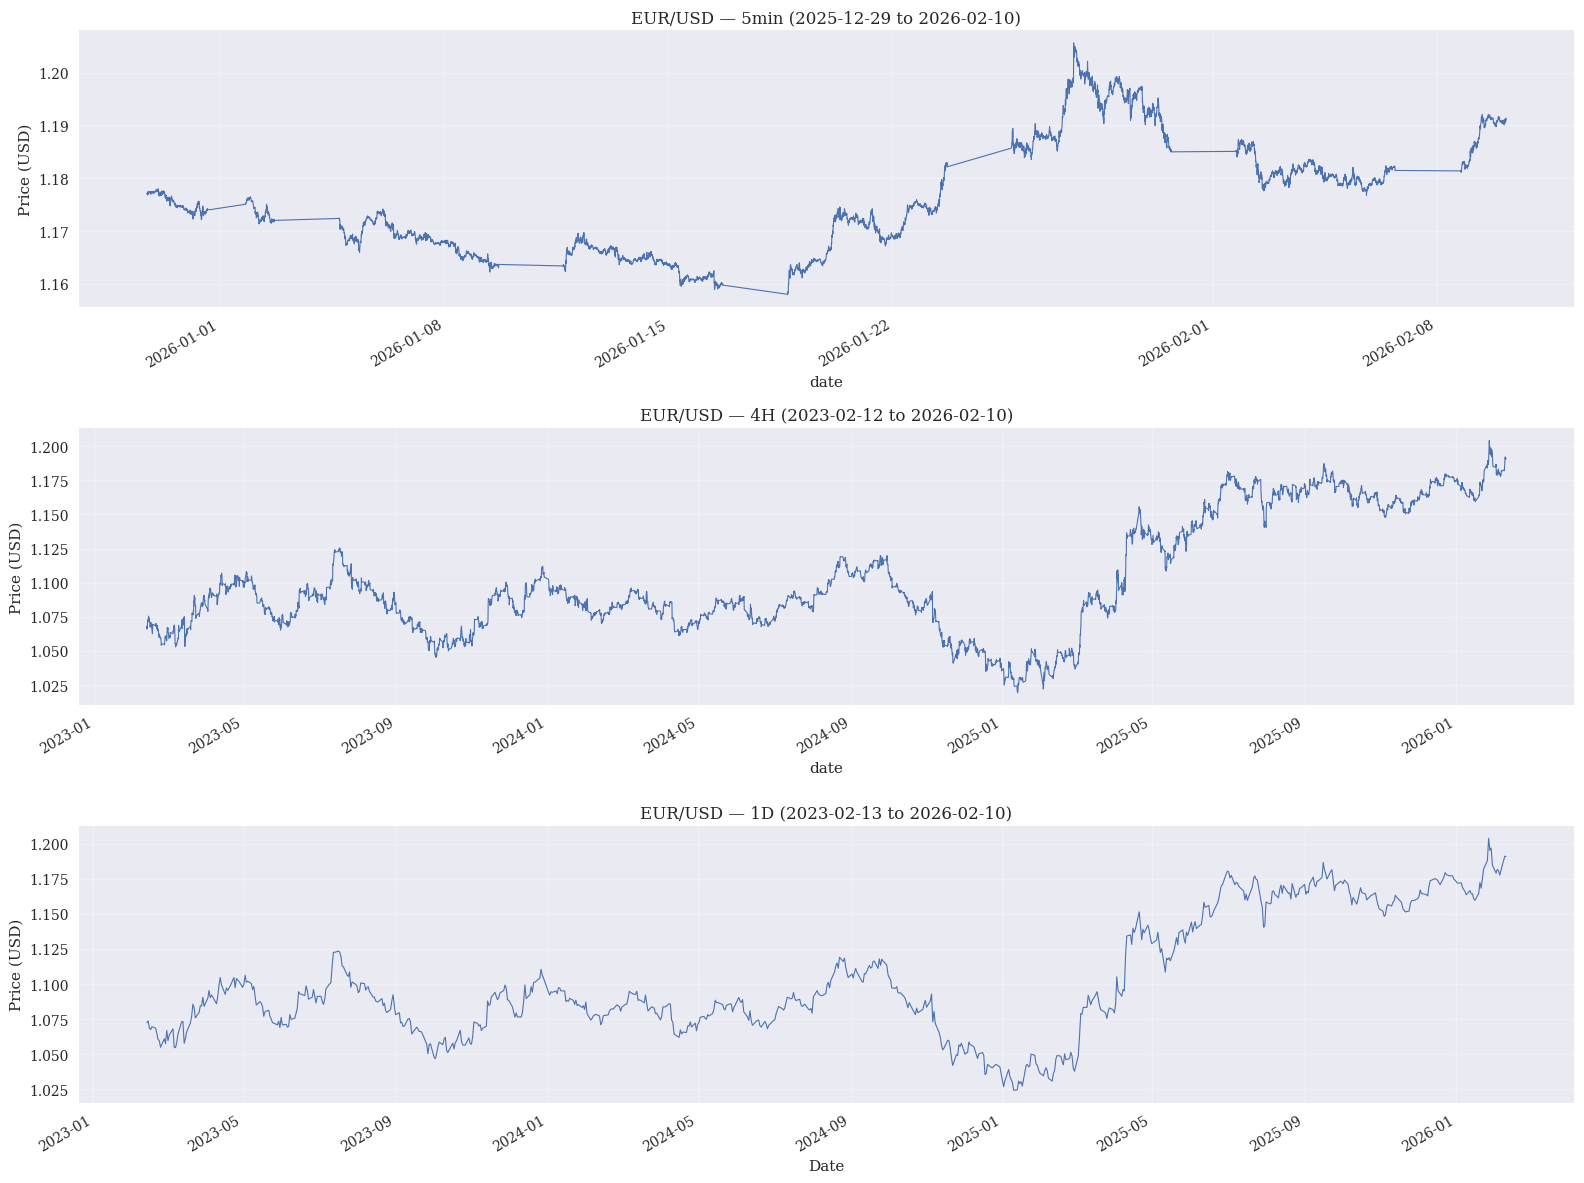

In [71]:
# Multi-timeframe price visualization
# Displays EUR/USD price action across three timeframes to reveal different patterns:
# - 5min: Intraday noise and micro-trends
# - 4H: Medium-term trend structure  
# - 1D: Major trend direction and support/resistance levels

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Loop through each timeframe and create a subplot
for ax, (name, df) in zip(axes, [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]):
    # Plot closing price (most important price point for technical analysis)
    df["close"].plot(ax=ax, linewidth=0.8)

    # Extract date range for title
    start, end = get_date_range(df)
    ax.set_title(f"EUR/USD — {name} ({start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')})")
    ax.set_ylabel("Price (USD)")

    # Add subtle grid for readability
    ax.grid(True, alpha=0.3)

# Label only the bottom x-axis to avoid clutter
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

### 3.4 Data Quality Assessment

Data quality is critical for reliable backtesting. The data loading module performs automatic validation checks, but a manual quality assessment provides additional confidence in the dataset.

In [72]:
# Summary statistics for all timeframes
for name, df in [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]:
    print(f"\n{'=' * 50}")
    print(f"Summary Statistics: {name}")
    print(f"{'=' * 50}")
    print(df.describe().round(6))


Summary Statistics: 5min
              open         high          low        close  volume
count  8372.000000  8372.000000  8372.000000  8372.000000  8372.0
mean      1.175829     1.176011     1.175648     1.175830    -1.0
std       0.010552     0.010602     0.010501     0.010553     0.0
min       1.157930     1.158010     1.157880     1.157930    -1.0
25%       1.167164     1.167329     1.167052     1.167164    -1.0
50%       1.173705     1.173870     1.173540     1.173705    -1.0
75%       1.182325     1.182495     1.182186     1.182325    -1.0
max       1.205605     1.208300     1.204150     1.205605    -1.0

Summary Statistics: 4H
              open         high          low        close  volume
count  5421.000000  5421.000000  5421.000000  5421.000000  5421.0
mean      1.101502     1.102726     1.100332     1.101525    -1.0
std       0.041233     0.041271     0.041223     0.041246     0.0
min       1.019590     1.022085     1.017755     1.019590    -1.0
25%       1.073760     1.0

In [73]:
# Check for missing values across all timeframes
print("Missing Values Check")
print("=" * 50)
for name, df in [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]:
    nan_count = df[["open", "high", "low", "close"]].isna().sum().sum()
    print(f"  {name}: {nan_count} missing OHLC values")

Missing Values Check
  5min: 0 missing OHLC values
  4H: 0 missing OHLC values
  1D: 0 missing OHLC values


In [74]:
# Check for duplicate timestamps
print("\nDuplicate Timestamp Check")
print("=" * 50)
for name, df in [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]:
    dupes = df.index.duplicated().sum()
    print(f"  {name}: {dupes} duplicate timestamps")


Duplicate Timestamp Check
  5min: 0 duplicate timestamps
  4H: 0 duplicate timestamps
  1D: 0 duplicate timestamps


In [75]:
# Verify OHLC relationships (High >= Low, High >= Open/Close, etc.)
print("\nOHLC Relationship Validation")
print("=" * 50)
for name, df in [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]:
    h_ge_l = (df["high"] >= df["low"]).all()
    h_ge_o = (df["high"] >= df["open"]).all()
    h_ge_c = (df["high"] >= df["close"]).all()
    l_le_o = (df["low"] <= df["open"]).all()
    l_le_c = (df["low"] <= df["close"]).all()
    all_ok = all([h_ge_l, h_ge_o, h_ge_c, l_le_o, l_le_c])
    status = "PASSED" if all_ok else "FAILED"
    print(f"  {name}: {status}")


OHLC Relationship Validation
  5min: PASSED
  4H: PASSED
  1D: PASSED


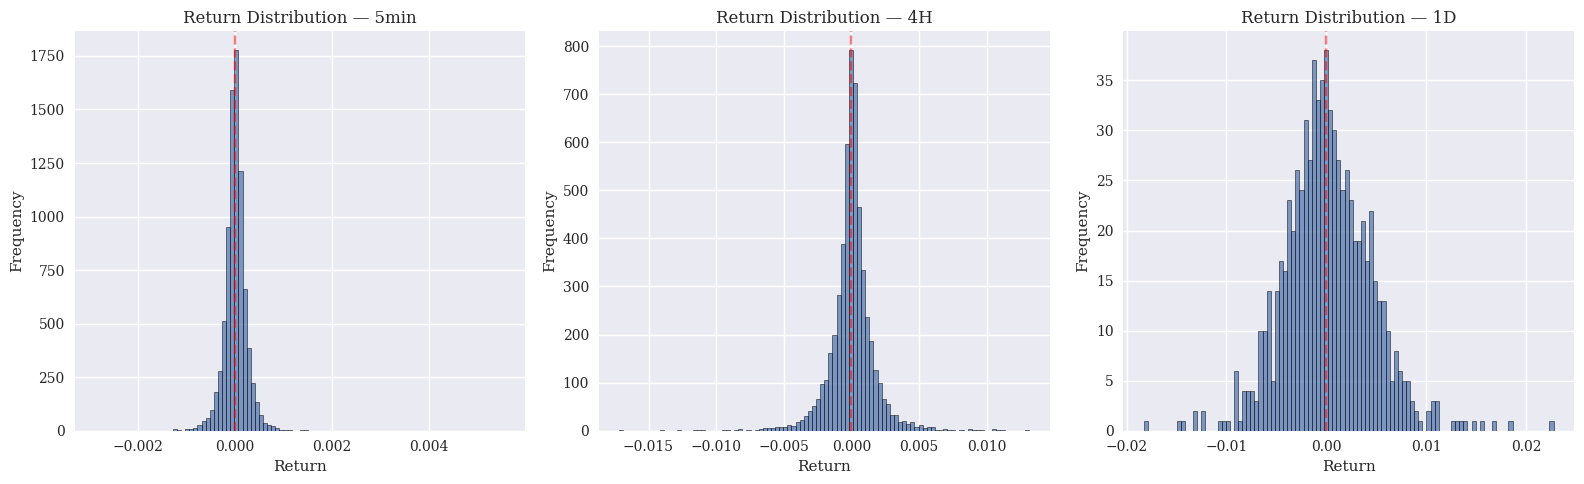

In [76]:
# Return distribution analysis across timeframes
# Histograms reveal the statistical properties of price changes:
# - Distribution shape (normal vs. fat-tailed)
# - Volatility (spread of distribution)
# - Skewness (asymmetry in returns)
# These properties inform risk assessment and parameter selection

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, df) in zip(axes, [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]):
    # Calculate percentage returns (change from one period to next)
    returns = df["close"].pct_change().dropna()

    # Create histogram with 100 bins for fine-grained distribution
    # More bins reveal tail behavior better than fewer bins
    returns.hist(
        bins=100,          # Fine granularity to capture distribution shape
        ax=ax, 
        alpha=0.7,         # Slight transparency
        edgecolor="black", # Black borders make bins distinct
        linewidth=0.5
    )
    
    ax.set_title(f"Return Distribution — {name}")
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

    # Vertical line at zero shows symmetry around breakeven
    # If distribution is symmetric around zero, market is unbiased
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [77]:
# Daily return statistics
print("Return Statistics")
print("=" * 60)
print(f"{'Timeframe':<12} {'Mean':>12} {'Std Dev':>12} {'Min':>12} {'Max':>12}")
print("-" * 60)
for name, df in [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]:
    returns = df["close"].pct_change().dropna()
    print(
        f"{name:<12} {returns.mean():>12.6f} {returns.std():>12.6f} "
        f"{returns.min():>12.6f} {returns.max():>12.6f}"
    )

Return Statistics
Timeframe            Mean      Std Dev          Min          Max
------------------------------------------------------------
5min             0.000001     0.000248    -0.002887     0.005557
4H               0.000022     0.001668    -0.017153     0.013135
1D               0.000145     0.004443    -0.018282     0.022759


### 3.5 Data Limitations and Considerations

Several characteristics of the data should be noted for proper interpretation of subsequent analysis:

__Volume Data:__ The historical data uses the MIDPOINT price type from Interactive Brokers, which does not provide meaningful volume information. Volume values are reported as -1, indicating unavailability. This is standard for forex midpoint data and does not affect the strategy, as it relies exclusively on price-based indicators (SMA, RSI, Momentum).

__Timeframe Coverage:__ The three datasets cover different time periods due to IB Gateway's data availability constraints:

In [78]:
print("Dataset Coverage Summary")
print("=" * 65)
print(f"{'Timeframe':<12} {'Bars':>8} {'Start Date':<22} {'End Date':<22}")
print("-" * 65)
for name, df in [("5min", data_5min), ("4H", data_4h), ("1D", data_1d)]:
    start, end = get_date_range(df)
    print(f"{name:<12} {len(df):>8,} {str(start):<22} {str(end):<22}")

Dataset Coverage Summary
Timeframe        Bars Start Date             End Date              
-----------------------------------------------------------------
5min            8,372 2025-12-29 17:15:00-05:00 2026-02-10 03:50:00-05:00
4H              5,421 2023-02-12 17:15:00-05:00 2026-02-10 03:00:00-05:00
1D                776 2023-02-13 00:00:00    2026-02-10 00:00:00   


The __5-minute data covers__ approximately six weeks, from December 29, 2025 to February 10, 2026 — the maximum window retrievable in a single API call for this bar size, as explained in Section 3.2. Both the backtesting and the grid search optimization in Section 6 were conducted on this same dataset. This is a meaningful limitation that deserves explicit acknowledgement.

A six-week backtest window captures only a single market regime. A strategy optimized on such a short sample carries a higher risk that its parameters reflect the specific conditions of those six weeks rather than durable market behavior. The contrast with the 4-hour backtest — which spans three years across multiple distinct regimes — is substantial. The risk-adjusted metrics from the 4-hour backtest consequently carry more evidential weight as an indication of strategy robustness.

The 5-minute results in this project are best understood as a proof-of-concept validation of the end-to-end pipeline rather than as a statistically robust strategy assessment. The architecture, signal logic, execution model, and infrastructure are all fully exercised; the confidence interval around the performance figures is simply wider given the shorter history.

The remaining dataset characteristics are summarized below.

__Key observations:__

- The __4-hour and daily data__ span approximately 3 years (2023-2026), providing a broader historical context for longer-timeframe analysis.
- __Market hours:__ EUR/USD trades continuously from Sunday 17:00 ET to Friday 17:00 ET. The data includes all trading sessions, not just regular trading hours.
- __Data source consistency:__ All data was fetched from the same source (Interactive Brokers MIDPOINT) using the same fetch script, ensuring consistency across timeframes.

For the backtesting and optimization work in subsequent sections, the primary analysis focuses on the 5-minute and 4-hour timeframes. The daily timeframe was excluded from optimization because the combination of limited bars (approximately 252 per year) and slow SMA periods (50/200) produced too few trades for statistically meaningful parameter selection.

## 4. Technical Indicator Calculation

With the historical data loaded and validated, the next step is to calculate the technical indicators that form the foundation of the trading strategy. As discussed in Section 2, the strategy employs three complementary indicators: Simple Moving Averages (SMA) for trend identification, the Relative Strength Index (RSI) for momentum confirmation, and a Momentum indicator for directional strength validation.

All indicators are implemented in the `modules/indicators/` package using an abstract base class (`Indicator`) that enforces a consistent interface. Each indicator validates its input data, accepts a DataFrame with a `close` column, and returns a pandas Series of indicator values. Indicators can be called as functions (e.g., `sma(df)`) or via the explicit `calculate` method.

### 4.1 Indicator Calculation

#### Simple Moving Average (SMA)

The SMA calculates the arithmetic mean of closing prices over a rolling window of N periods. The strategy uses two SMAs with different periods — a fast SMA that responds quickly to price changes, and a slow SMA that captures the longer-term trend. When the fast SMA crosses above the slow SMA, it suggests the beginning of an uptrend; when it crosses below, it signals a potential downtrend.

The SMA implementation uses the `pandas.Series.rolling().mean()` method for efficient vectorized calculation:

In [79]:
from modules.indicators import SMA

# Demonstrate SMA calculation on the 5-minute data
sma_fast = SMA(period=20)
sma_slow = SMA(period=50)

print(f"Fast SMA: {sma_fast}")
print(f"Slow SMA: {sma_slow}")

# Calculate indicator values
data_5min["sma_fast"] = sma_fast(data_5min)
data_5min["sma_slow"] = sma_slow(data_5min)

# Show the first few values (NaN until enough data accumulates)
data_5min[["close", "sma_fast", "sma_slow"]].head(55)

Fast SMA: SMA({'period': 20})
Slow SMA: SMA({'period': 50})


,close,sma_fast,sma_slow
date,,,
2025-12-29 17:15:00-05:00,1.177015,NaN,NaN
2025-12-29 17:20:00-05:00,1.177015,NaN,NaN
2025-12-29 17:25:00-05:00,1.177015,NaN,NaN
2025-12-29 17:30:00-05:00,1.177175,NaN,NaN
2025-12-29 17:35:00-05:00,1.177125,NaN,NaN
2025-12-29 17:40:00-05:00,1.177260,NaN,NaN
2025-12-29 17:45:00-05:00,1.177215,NaN,NaN
2025-12-29 17:50:00-05:00,1.177110,NaN,NaN
2025-12-29 17:55:00-05:00,1.176800,NaN,NaN


The fast SMA produces NaN for the first 19 rows (period - 1), and the slow SMA produces NaN for the first 49 rows, as insufficient data exists for the rolling calculation.

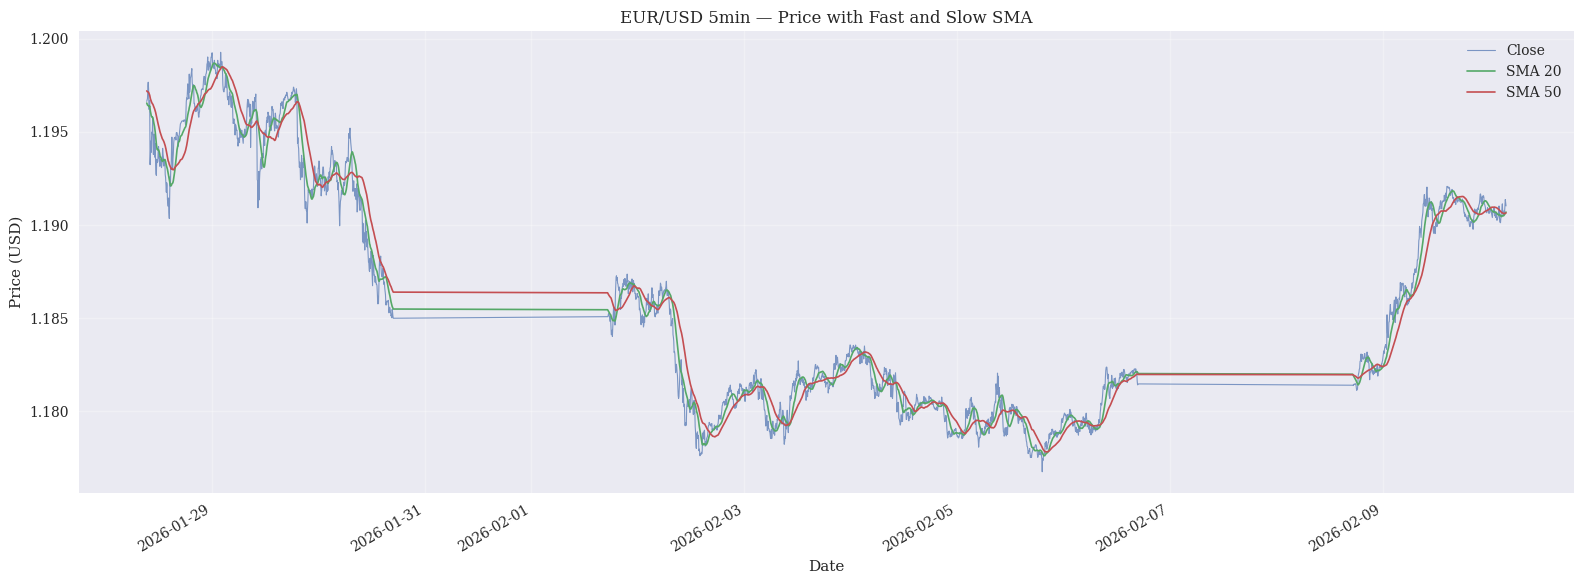

In [85]:
# Visualize SMAs overlaid on price
# Simple Moving Average (SMA) visualization
# Shows how fast and slow SMAs track price and generate crossover signals
# Fast SMA responds quickly to recent price changes
# Slow SMA smooths out noise to show underlying trend direction

fig, ax = plt.subplots(figsize=(16, 6))

# Plot a representative subset to show crossover behavior
# Use last 500 bars (reasonable window to see multiple crossovers without overcrowding)
subset = data_5min.iloc[-2500:]

# Plot price with transparency so SMAs stand out
subset["close"].plot(
    ax=ax, 
    label="Close", 
    alpha=0.7,    # Transparent so SMAs are more visible
    linewidth=0.8
)

# Fast SMA (responds to recent price changes)
# Thicker line (1.2) makes it distinct from price
subset["sma_fast"].plot(
    ax=ax, 
    label=f"SMA {sma_fast.params['period']}", 
    linewidth=1.2
)

# Slow SMA (shows longer-term trend)
subset["sma_slow"].plot(
    ax=ax, 
    label=f"SMA {sma_slow.params['period']}", 
    linewidth=1.2
)

ax.set_title("EUR/USD 5min — Price with Fast and Slow SMA")
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()

The flat horizontal segments visible at weekends (approximately 2026-01-31 and 2026-02-07) reflect the closure of the forex market from Friday afternoon to Sunday evening. No new bars are generated during this period; the chart renders the last Friday closing price as a flat line across the gap. This is a characteristic of continuous datetime axis plotting on forex data and does not indicate missing or erroneous data.

#### Relative Strength Index (RSI)

The RSI measures the speed and magnitude of recent price changes, oscillating between 0 and 100. The implementation uses exponential moving average (EMA) smoothing of gains and losses, which is the method originally described by J. Welles Wilder (1978).

The calculation follows these steps:

1. Compute price changes: `delta = close.diff()`
2. Separate gains (positive changes) and losses (negative changes)
3. Smooth both using EMA: `ewm(alpha=1/period, adjust=False)`
4. Compute Relative Strength: `RS = avg_gain / avg_loss`
5. Convert to RSI: `RSI = 100 - (100 / (1 + RS))`

In [86]:
from modules.indicators import RSI

# Calculate RSI with 14-period (Wilder's standard)
rsi = RSI(period=14)
print(f"RSI indicator: {rsi}")

data_5min["rsi"] = rsi(data_5min)

# Show RSI statistics
print(f"\nRSI Statistics:")
print(f"  Min:  {data_5min['rsi'].min():.2f}")
print(f"  Max:  {data_5min['rsi'].max():.2f}")
print(f"  Mean: {data_5min['rsi'].mean():.2f}")

RSI indicator: RSI({'period': 14})

RSI Statistics:
  Min:  12.72
  Max:  100.00
  Mean: 50.32


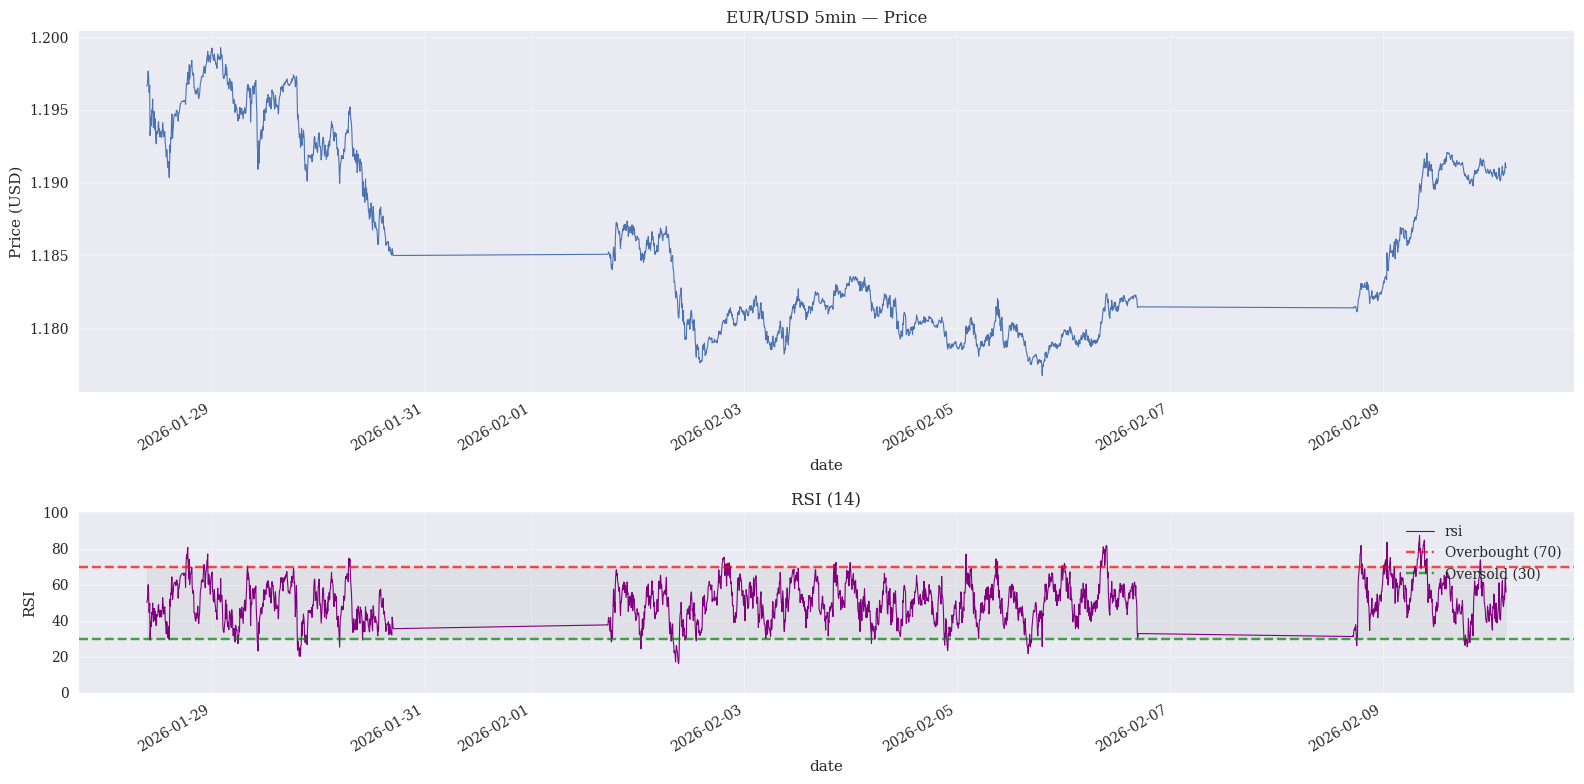

In [88]:
# Relative Strength Index (RSI) visualization
# Two-panel view shows relationship between price and momentum
# RSI values above 70 suggest overbought (potential reversal down)
# RSI values below 30 suggest oversold (potential reversal up)
# The neutral zone (30-70) indicates balanced momentum

fig, axes = plt.subplots(
    2, 
    1, 
    figsize=(16, 8), 
    gridspec_kw={"height_ratios": [2, 1]}  # Price panel taller than RSI
)

subset = data_5min.iloc[-2500:]

# TOP PANEL: Price action
# Shows what price is doing when RSI reaches extremes
subset["close"].plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("EUR/USD 5min — Price")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.3)

# BOTTOM PANEL: RSI oscillator
subset["rsi"].plot(
    ax=axes[1], 
    linewidth=0.8, 
    color="purple"
)

# Overbought threshold at 70 (traditional Wilder default)
# When RSI crosses above 70, buying momentum may be exhausted
axes[1].axhline(
    y=70, 
    color="red", 
    linestyle="--", 
    alpha=0.7, 
    label="Overbought (70)"
)

# Oversold threshold at 30
# When RSI crosses below 30, selling momentum may be exhausted
axes[1].axhline(
    y=30, 
    color="green", 
    linestyle="--", 
    alpha=0.7, 
    label="Oversold (30)"
)

# Shaded neutral zone (30-70) where RSI doesn't give extreme signals
axes[1].fill_between(subset.index, 30, 70, alpha=0.1, color="gray")

axes[1].set_title("RSI (14)")
axes[1].set_ylabel("RSI")
axes[1].set_ylim(0, 100)          # RSI always bounded between 0-100
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()

#### Momentum Indicator

The Momentum indicator measures the rate of change in price by computing the difference between the current closing price and the closing price N periods ago. Positive values indicate upward price acceleration, while negative values indicate downward acceleration. Unlike RSI, momentum is unbounded and expressed in price units.

The calculation is straightforward: `Momentum = close(today) - close(N periods ago)`, implemented as `close.diff(periods=N)`.

In [89]:
mom = Momentum(period=10)
print(f"Momentum indicator: {mom}")

data_5min["momentum"] = mom(data_5min)

# Show momentum statistics
print(f"\nMomentum Statistics:")
print(f"  Min:  {data_5min['momentum'].min():.6f}")
print(f"  Max:  {data_5min['momentum'].max():.6f}")
print(f"  Mean: {data_5min['momentum'].mean():.6f}")

Momentum indicator: Momentum({'period': 10})

Momentum Statistics:
  Min:  -0.005565
  Max:  0.007740
  Mean: 0.000016


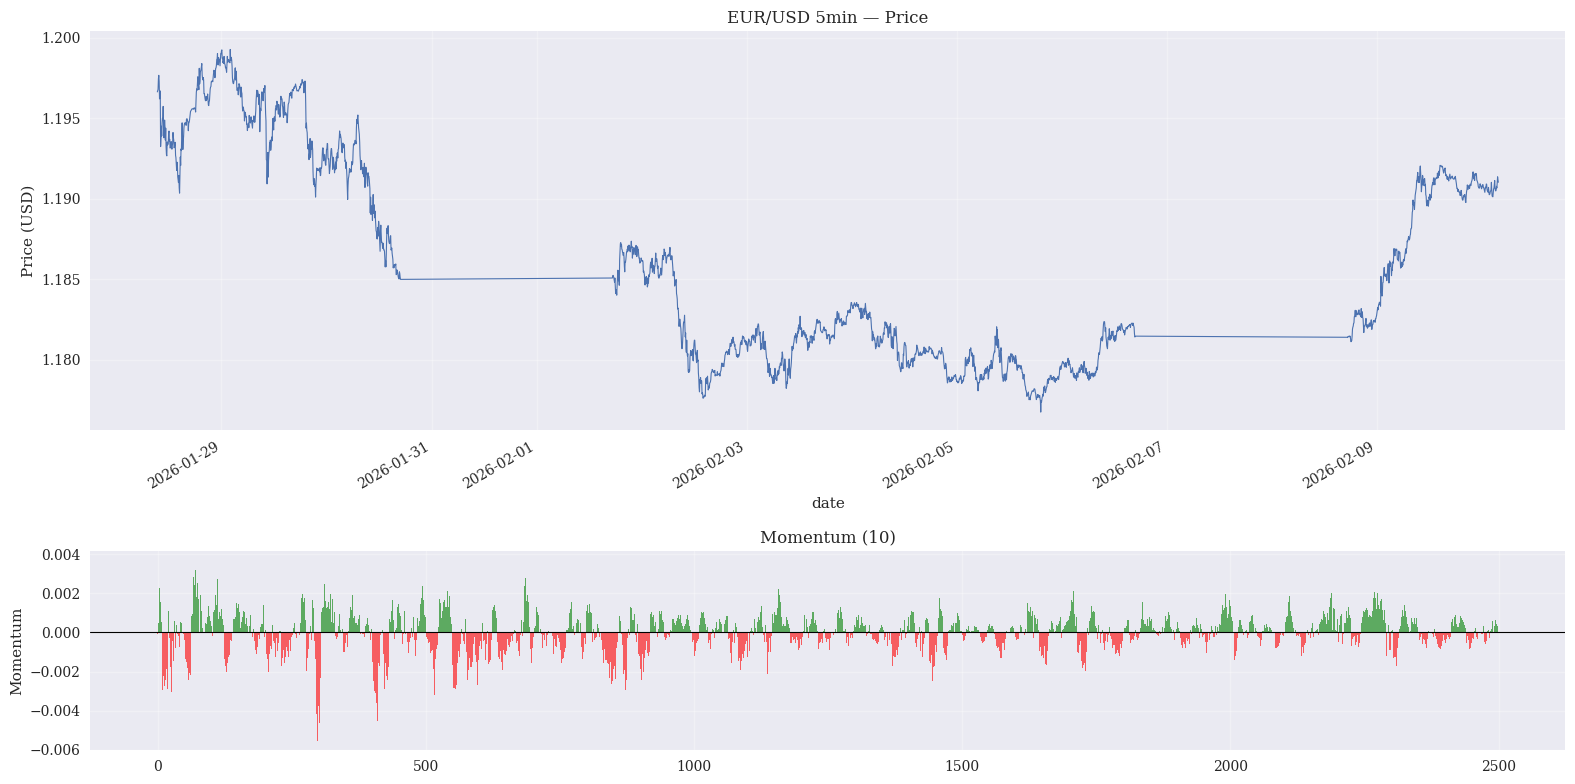

In [90]:
# Momentum Indicator Visualization
# Shows rate of price change (price now vs. price N periods ago)
# Positive momentum = upward price pressure (current > past)
# Negative momentum = downward price pressure (current < past)
# Zero-crossing indicates potential trend change

fig, axes = plt.subplots(
    2, 1, 
    figsize=(16, 8), 
    gridspec_kw={"height_ratios": [2, 1]}
)

subset = data_5min.iloc[-2500:]

# TOP PANEL: Price action
subset["close"].plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("EUR/USD 5min — Price")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.3)

# BOTTOM PANEL: Momentum oscillator as bar chart
# Bar chart (rather than line) emphasizes discrete momentum shifts
# Color coding makes directional pressure immediately visible

# Create color list: green for positive momentum, red for negative
colors = [
    "green" if v > 0 else "red" 
    for v in subset["momentum"].fillna(0)  # Fill NaN with 0 to avoid errors
]

# Bar chart shows momentum magnitude and direction
axes[1].bar(
    range(len(subset)),            # X-axis positions
    subset["momentum"].values,     # Heights (momentum values)
    color=colors,                  # Green/red coloring
    alpha=0.6,                     # Slight transparency
    width=1.0                      # Full width (no gaps between bars)
)

# Zero line is critical reference - separates upward/downward pressure
axes[1].axhline(y=0, color="black", linewidth=0.8)

axes[1].set_title("Momentum (10)")
axes[1].set_ylabel("Momentum")
axes[1].grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()

#### Complete Indicator Panel

The following visualization shows all three indicators together, providing a comprehensive view of the market state at any point in time. This is the information available to the strategy when generating trading signals.

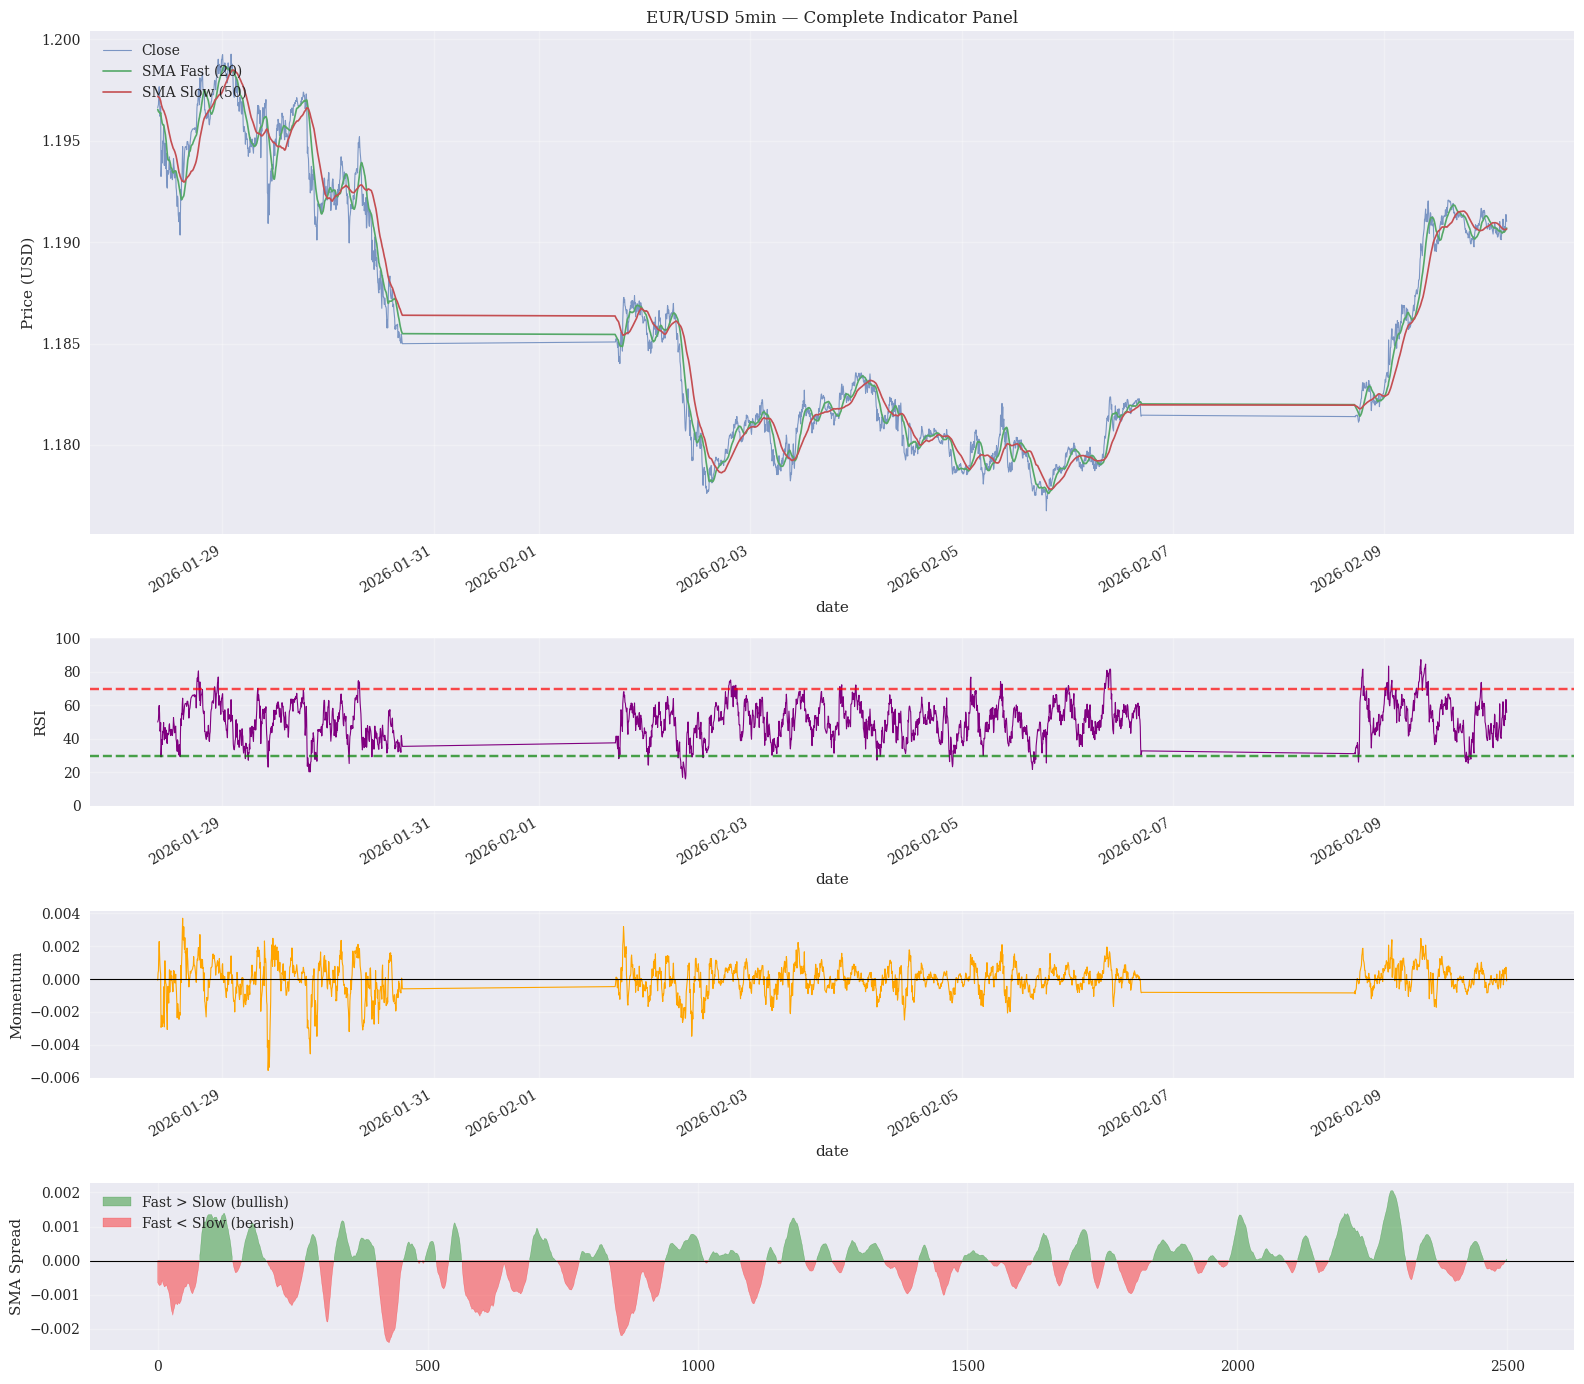

In [91]:
# Comprehensive Four-Panel Indicator Dashboard
# This is the complete view of all indicators used by the trading strategy
# All panels share the same time axis, making it easy to see how indicators
# align (or don't align) at specific moments in time

fig, axes = plt.subplots(
    4, 1, 
    figsize=(16, 14), 
    gridspec_kw={"height_ratios": [3, 1, 1, 1]}  # Price panel 3x larger
)

subset = data_5min.iloc[-2500:]

# ============================================================
# PANEL 1: Price with Moving Averages
# ============================================================
# This shows the trend structure and crossover points
subset["close"].plot(
    ax=axes[0], 
    label="Close", 
    alpha=0.7,      # Transparent to let SMAs stand out
    linewidth=0.8
)

# Fast SMA tracks recent price action
subset["sma_fast"].plot(
    ax=axes[0], 
    label="SMA Fast (20)", 
    linewidth=1.2
)

# Slow SMA shows underlying trend
subset["sma_slow"].plot(
    ax=axes[0], 
    label="SMA Slow (50)", 
    linewidth=1.2
)

axes[0].set_title("EUR/USD 5min — Complete Indicator Panel")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# ============================================================
# PANEL 2: RSI (Relative Strength Index)
# ============================================================
# Oscillates between 0-100, showing momentum extremes
subset["rsi"].plot(
    ax=axes[1], 
    linewidth=0.8, 
    color="purple"
)

# Standard overbought/oversold thresholds
axes[1].axhline(y=70, color="red", linestyle="--", alpha=0.7)
axes[1].axhline(y=30, color="green", linestyle="--", alpha=0.7)

axes[1].set_ylabel("RSI")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

# ============================================================
# PANEL 3: Momentum Indicator
# ============================================================
# Shows directional price pressure (rate of change)
subset["momentum"].plot(
    ax=axes[2], 
    linewidth=0.8, 
    color="orange"
)

# Zero line separates upward/downward pressure
axes[2].axhline(y=0, color="black", linewidth=0.8)

axes[2].set_ylabel("Momentum")
axes[2].grid(True, alpha=0.3)

# ============================================================
# PANEL 4: SMA Spread (Fast - Slow)
# ============================================================
# Visual representation of SMA crossover state
# Green area = Fast SMA > Slow SMA = Bullish alignment
# Red area = Fast SMA < Slow SMA = Bearish alignment
# Zero crossing = Crossover event (potential signal)

sma_spread = subset["sma_fast"] - subset["sma_slow"]

# Fill area above zero (bullish)
axes[3].fill_between(
    range(len(sma_spread)),
    sma_spread.values,
    0,
    where=sma_spread.values > 0,     # Only where spread is positive
    color="green",
    alpha=0.4,
    label="Fast > Slow (bullish)",  
)

# Fill area below zero (bearish)
axes[3].fill_between(
    range(len(sma_spread)),
    sma_spread.values,
    0,
    where=sma_spread.values <= 0,    # Only where spread is negative
    color="red",
    alpha=0.4,
    label="Fast < Slow (bearish)",
)

# Zero line shows crossover boundary
axes[3].axhline(y=0, color="black", linewidth=0.8)

axes[3].set_ylabel("SMA Spread")
axes[3].legend(loc="upper left")
axes[3].grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()

#### Reading the Combined Indicator Panel

The four-panel view shows the complete information set available to the strategy at any 
point in time. The panels are aligned on a common time axis, which makes it possible to 
observe how the three indicators relate to each other.

**Price and SMAs (top panel):** The fast SMA tracks price closely, while the slow SMA 
moves gradually, reflecting the longer-term trend. Crossover points — where the fast SMA 
crosses above or below the slow SMA — are the primary trigger for signal generation. 
Notice that crossovers are relatively infrequent; most of the time the two SMAs maintain 
their relative ordering, which translates to sustained LONG or SHORT positions rather 
than constant switching.

**RSI (second panel):** The RSI oscillates between 0 and 100, with the shaded region 
marking the 35–75 threshold band used by this strategy. RSI functions as a filter here, 
not a primary signal: a BUY crossover is only confirmed when RSI is *below* the upper 
threshold (not already overbought), and a SELL crossover is only confirmed when RSI is 
*above* the lower threshold (not already oversold). This counter-trend filter prevents 
entering positions when a move may already be exhausted.

**Momentum (third panel):** The momentum indicator fluctuates around zero, with positive 
values indicating upward price acceleration and negative values indicating downward 
acceleration. It acts as a directional confirmation filter: a BUY signal requires positive 
momentum, a SELL signal requires negative momentum. This eliminates crossovers that occur 
during low-conviction, sideways price action.

**Key observation:** The three indicators do not always agree — SMA crossovers frequently 
occur when RSI or momentum does not confirm. This disagreement is intentional: the 
strategy only enters a trade when all three indicators align, accepting fewer trades in 
exchange for higher-quality entry conditions. The signal distribution in the next section 
quantifies this effect.

#### Applying Indicators to the 4-Hour Timeframe

The same indicators are applied to the 4-hour data using identical code. The modular design ensures consistency across timeframes — only the input data changes.

In [92]:
# Calculate indicators for 4H timeframe using its configured default parameters
cfg_4h = get_timeframe_config("4H")

data_4h["sma_fast"] = SMA(period=cfg_4h["sma_fast"])(data_4h)
data_4h["sma_slow"] = SMA(period=cfg_4h["sma_slow"])(data_4h)
data_4h["rsi"] = RSI(period=cfg_4h["rsi_period"])(data_4h)
data_4h["momentum"] = Momentum(period=cfg_4h["momentum_lookback"])(data_4h)

print(f"4H Indicators Calculated:")
print(f"  SMA Fast:   {cfg_4h['sma_fast']}-period")
print(f"  SMA Slow:   {cfg_4h['sma_slow']}-period")
print(f"  RSI:        {cfg_4h['rsi_period']}-period")
print(f"  Momentum:   {cfg_4h['momentum_lookback']}-period")
print(f"  Total bars: {len(data_4h):,}")

4H Indicators Calculated:
  SMA Fast:   20-period
  SMA Slow:   50-period
  RSI:        14-period
  Momentum:   10-period
  Total bars: 5,421


### 4.2 Indicator Summary

The indicator framework provides a clean, reusable interface for technical analysis. The key design decisions and their implications are summarized below.

In [93]:
# Summary of indicator behavior
print("Indicator Framework Summary")
print("=" * 65)
print(f"{'Indicator':<15} {'Formula':<30} {'NaN Rows':<15} {'Range':<15}")
print("-" * 65)
print(f"{'SMA(N)':<15} {'rolling(N).mean()':<30} {'N-1':<15} {'Unbounded':<15}")
print(f"{'RSI(N)':<15} {'100 - 100/(1+RS)':<30} {'1 (from diff)':<15} {'[0, 100]':<15}")
print(f"{'Momentum(N)':<15} {'close.diff(N)':<30} {'N':<15} {'Unbounded':<15}")

print(f"\nAll indicators:")
print(f"  - Accept DataFrame with 'close' column")
print(f"  - Return pandas Series with same index")
print(f"  - Use vectorized operations (no loops)")
print(f"  - Inherit from abstract Indicator base class")
print(f"  - Callable as functions: sma(df) == sma.calculate(df)")

Indicator Framework Summary
Indicator       Formula                        NaN Rows        Range          
-----------------------------------------------------------------
SMA(N)          rolling(N).mean()              N-1             Unbounded      
RSI(N)          100 - 100/(1+RS)               1 (from diff)   [0, 100]       
Momentum(N)     close.diff(N)                  N               Unbounded      

All indicators:
  - Accept DataFrame with 'close' column
  - Return pandas Series with same index
  - Use vectorized operations (no loops)
  - Inherit from abstract Indicator base class
  - Callable as functions: sma(df) == sma.calculate(df)


__Design considerations:__

- __Abstract base class:__ The `Indicator` ABC enforces a consistent interface across all indicator implementations, making it straightforward to add new indicators in the future without modifying downstream code.
- __EMA smoothing for RSI:__ The implementation uses Wilder's original EMA smoothing method (`ewm(alpha=1/period)`), which provides more weight to recent price changes than a simple moving average approach.
- __NaN handling:__ Each indicator produces NaN values during its warmup period. The strategy module handles these NaN values by only generating signals once all indicators have valid data.
- __Lowercase column names:__ All indicators expect and produce lowercase column names (e.g., `close`, not `Close`), matching the output of the data loader module.

In [94]:
# Clean up temporary indicator columns from data_5min
# (The strategy module will calculate its own indicators)
for col in ["sma_fast", "sma_slow", "rsi", "momentum"]:
    if col in data_5min.columns:
        data_5min.drop(columns=[col], inplace=True)
    if col in data_4h.columns:
        data_4h.drop(columns=[col], inplace=True)

## 5. Signal Generation and Position Management

This section bridges the gap between individual technical indicators and actionable trading decisions. While each indicator provides useful information about market conditions, the strategy must combine them into a coherent decision framework that determines when to enter, exit, or hold positions. The `MARSIMomentumStrategy` class in `modules/strategy/` implements this logic.

### 5.1 Understanding Signal Generation

The strategy generates three types of signals at each bar:

| Signal | Value | Meaning |
|--------|-------|---------|
| BUY | +1 | Open or maintain a LONG position |
| SELL | -1 | Open or maintain a SHORT position |
| HOLD | 0 | No action — maintain current position |

A signal is generated only when __all three indicators align__:

__BUY Signal (+1):__
- Fast SMA __crosses above__ Slow SMA (bullish crossover)
- RSI is __below__ the upper threshold (not overbought)
- Momentum is __positive__ (price accelerating upward)

__SELL Signal (-1):__
- Fast SMA __crosses below__ Slow SMA (bearish crossover)
- RSI is __above__ the lower threshold (not oversold)
- Momentum is __negative__ (price accelerating downward)

The critical word here is "crosses" — the strategy only generates a signal at the moment of crossover, not while the SMAs are already in a particular alignment. This distinction is important because it means signals are relatively rare events. Between crossovers, the strategy generates HOLD signals, and the position persists from the last active signal.

In [29]:
from modules.strategy import MARSIMomentumStrategy

# Initialize strategy with default parameters for 5-minute timeframe
strategy_5min = MARSIMomentumStrategy(timeframe="5min")

print("Strategy: ", strategy_5min.name)
print("Parameters:")
for param, value in strategy_5min.params.items():
    print(f"  {param}: {value}")

Strategy:  MA_RSI_MOM_5min
Parameters:
  sma_fast: 20
  sma_slow: 50
  rsi_period: 14
  rsi_lower: 30
  rsi_upper: 70
  momentum_period: 10
  momentum_threshold: 0.0


### 5.2 Generating Trading Signals based on Indicator Combination

The strategy's `generate_signals` method performs the complete pipeline — calculating all indicators, detecting crossovers, applying filters, and generating signals — in a single call. It operates on a copy of the input DataFrame to avoid modifying the original data.

In [30]:
# Generate signals for 5-minute data
signals_5min = strategy_5min.generate_signals(data_5min)

# The result contains the original data plus new columns
print("New columns added by strategy:")
for col in ["sma_fast", "sma_slow", "rsi", "momentum", "signal", "position"]:
    print(f"  {col}: {signals_5min[col].dtype}")

New columns added by strategy:
  sma_fast: float64
  sma_slow: float64
  rsi: float64
  momentum: float64
  signal: int64
  position: int64


In [31]:
# Count signal types
signal_counts = strategy_5min.get_signal_count(signals_5min)
print("\nSignal Distribution (5min):")
print(f"  BUY signals:  {signal_counts['BUY']:>6}")
print(f"  SELL signals: {signal_counts['SELL']:>6}")
print(f"  HOLD signals: {signal_counts['HOLD']:>6}")
print(f"  Total bars:   {len(signals_5min):>6}")
print(f"\n  Signal frequency: 1 signal per {len(signals_5min) // max(signal_counts['BUY'] + signal_counts['SELL'], 1)} bars")


Signal Distribution (5min):
  BUY signals:      65
  SELL signals:     74
  HOLD signals:   8233
  Total bars:     8372

  Signal frequency: 1 signal per 60 bars


The low signal frequency reflects the multi-indicator confirmation approach. Most bars produce HOLD signals because the conditions for a BUY or SELL rarely all align simultaneously. This conservative behavior is by design — it reduces false signals and trading frequency, thereby limiting transaction costs.

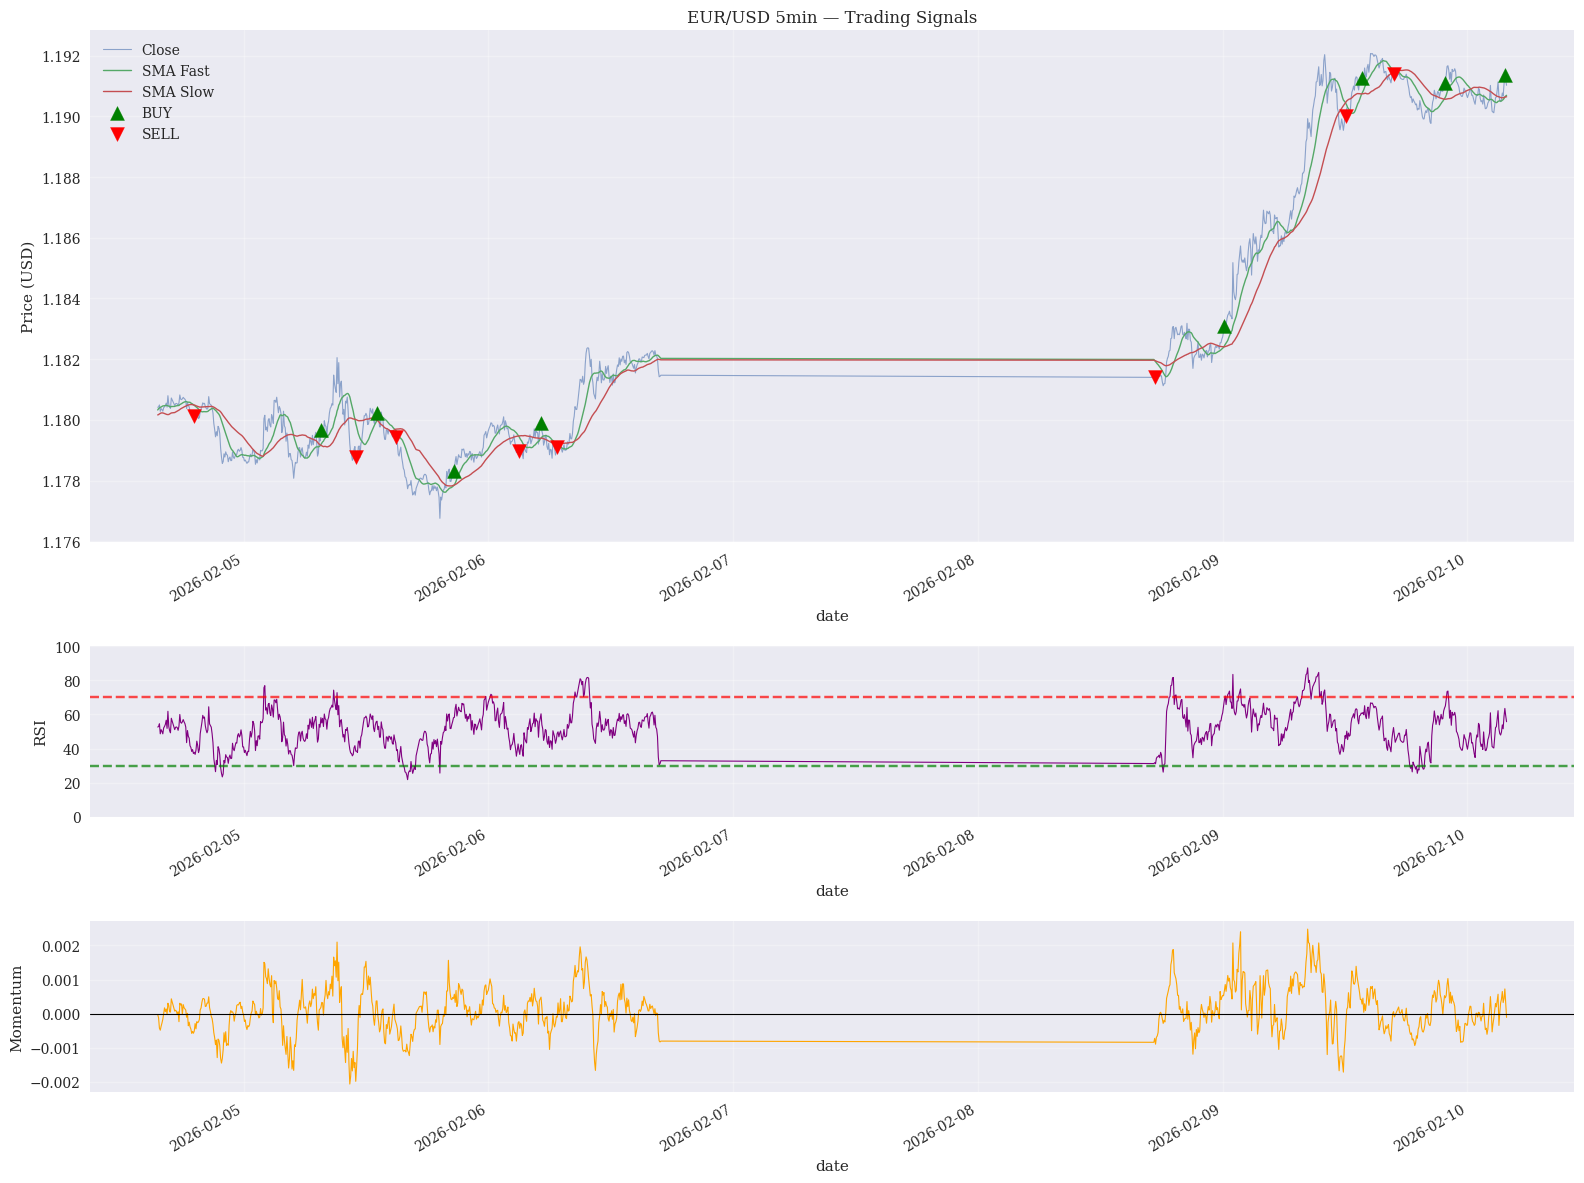

In [32]:
# Trading Signal Visualization
# Shows when the strategy generates BUY/SELL signals based on multi-indicator confirmation
# Green triangles (^) = BUY signals (enter LONG position)
# Red triangles (v) = SELL signals (enter SHORT position or exit LONG)
# Absence of markers = HOLD (maintain current position)

fig, axes = plt.subplots(
    3, 1, 
    figsize=(16, 12), 
    gridspec_kw={"height_ratios": [3, 1, 1]}
)

# Use larger window (1000 bars) to see multiple signal occurrences
subset = signals_5min.iloc[-1000:]

# ============================================================
# PANEL 1: Price Chart with Signal Markers
# ============================================================
# Shows exactly where trades would occur in relation to price action
subset["close"].plot(
    ax=axes[0], 
    label="Close", 
    alpha=0.6,       # Fade price slightly so signals stand out
    linewidth=0.8
)

# Plot SMAs to show trend context when signals occur
subset["sma_fast"].plot(ax=axes[0], label="SMA Fast", linewidth=1.0)
subset["sma_slow"].plot(ax=axes[0], label="SMA Slow", linewidth=1.0)

# Extract BUY signal timestamps (where signal column = +1)
buys = subset[subset["signal"] == 1]
if not buys.empty:
    # Scatter plot creates individual markers at signal points
    axes[0].scatter(
        buys.index,                 # X-axis: when
        buys["close"],              # Y-axis: at what price
        marker="^",                 # Upward triangle
        color="green",
        s=100,                      # Marker size
        label="BUY",
        zorder=5                    # Draw on top of lines
    )
    
# Extract SELL signal timestamps (where signal column = -1)
sells = subset[subset["signal"] == -1]
if not sells.empty:
    axes[0].scatter(
        sells.index, 
        sells["close"], 
        marker="v",                 # Downward triangle
        color="red", 
        s=100, 
        label="SELL", 
        zorder=5
    )

axes[0].set_title("EUR/USD 5min — Trading Signals")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# ============================================================
# PANEL 2: RSI Context
# ============================================================
# Shows RSI state when signals occur
# Helps verify that RSI extreme conditions align with signals
subset["rsi"].plot(
    ax=axes[1], 
    linewidth=0.8, 
    color="purple"
)

# Show the actual RSI thresholds used by the strategy
axes[1].axhline(
    y=strategy_5min.params["rsi_upper"], 
    color="red", 
    linestyle="--", 
    alpha=0.7
)
axes[1].axhline(
    y=strategy_5min.params["rsi_lower"], 
    color="green", 
    linestyle="--", 
    alpha=0.7
)

axes[1].set_ylabel("RSI")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

# ============================================================
# PANEL 3: Momentum Context
# ============================================================
# Shows momentum state when signals occur
# Confirms directional pressure aligns with signal direction
subset["momentum"].plot(
    ax=axes[2], 
    linewidth=0.8, 
    color="orange"
)

# Zero line divides bullish/bearish momentum
axes[2].axhline(y=0, color="black", linewidth=0.8)
axes[2].set_ylabel("Momentum")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Examining Individual Signal Events

To understand the strategy's decision-making process, it is instructive to examine individual signal events and verify that all three conditions are met.

In [33]:
# Show the bars where BUY and SELL signals occur
buy_events = signals_5min[signals_5min["signal"] == 1][
    ["close", "sma_fast", "sma_slow", "rsi", "momentum", "signal"]
]
sell_events = signals_5min[signals_5min["signal"] == -1][
    ["close", "sma_fast", "sma_slow", "rsi", "momentum", "signal"]
]

print(f"BUY Signal Events ({len(buy_events)} total):")
print(buy_events.head(5).to_string())
print(f"\nSELL Signal Events ({len(sell_events)} total):")
print(sell_events.head(5).to_string())

BUY Signal Events (65 total):
                              close  sma_fast  sma_slow        rsi  momentum  signal
date                                                                                
2025-12-31 05:45:00-05:00  1.174210  1.173394  1.173323  67.328689  0.000705       1
2025-12-31 14:40:00-05:00  1.174210  1.173742  1.173709  60.891608  0.000675       1
2026-01-04 17:15:00-05:00  1.172390  1.172029  1.172027  58.024948  0.000270       1
2026-01-05 01:10:00-05:00  1.168430  1.168258  1.168254  54.758474  0.000200       1
2026-01-05 21:10:00-05:00  1.172345  1.171791  1.171790  63.550727  0.000800       1

SELL Signal Events (74 total):
                              close  sma_fast  sma_slow        rsi  momentum  signal
date                                                                                
2025-12-30 02:40:00-05:00  1.176630  1.177472  1.177499  32.505145 -0.001280      -1
2025-12-30 07:05:00-05:00  1.176335  1.177127  1.177141  30.581787 -0.000935      -1
202

For every BUY event, the fast SMA is above the slow SMA (after being below), RSI is below the upper threshold, and momentum is positive. For every SELL event, the fast SMA is below the slow SMA (after being above), RSI is above the lower threshold, and momentum is negative. This confirms the multi-indicator confirmation logic operates correctly.

### 5.3 Converting Signals to Actual Positions

The strategy distinguishes between __signals__ and __positions__:

- A __signal__ is a momentary event (BUY, SELL, or HOLD) at a specific bar.
- A __position__ represents the current market exposure (LONG, SHORT, or FLAT) which persists until the next opposing signal.

The conversion uses forward-fill logic: once a BUY signal sets the position to LONG (+1), it remains LONG through all subsequent HOLD signals until a SELL signal changes it to SHORT (-1).

In [34]:
# Demonstrate the signal-to-position conversion
print("Signal-to-Position Conversion Logic")
print("=" * 55)
print("Signals:    [0, 0, 1, 0, 0, -1, 0, 0, 1, 0]")
print("Positions:  [0, 0, 1, 1, 1, -1, -1, -1, 1, 1]")
print()
print("Rules:")
print("  BUY signal (+1)  -> Enter/maintain LONG position (+1)")
print("  SELL signal (-1) -> Enter/maintain SHORT position (-1)")
print("  HOLD signal (0)  -> Maintain current position (forward-fill)")
print("  Initial state    -> FLAT (0) until first signal")

Signal-to-Position Conversion Logic
Signals:    [0, 0, 1, 0, 0, -1, 0, 0, 1, 0]
Positions:  [0, 0, 1, 1, 1, -1, -1, -1, 1, 1]

Rules:
  BUY signal (+1)  -> Enter/maintain LONG position (+1)
  SELL signal (-1) -> Enter/maintain SHORT position (-1)
  HOLD signal (0)  -> Maintain current position (forward-fill)
  Initial state    -> FLAT (0) until first signal


In [35]:
# Analyze position distribution
position_counts = signals_5min["position"].value_counts().sort_index()
total_bars = len(signals_5min)

print("\nPosition Distribution (5min):")
print(f"  FLAT  (0):  {position_counts.get(0, 0):>6} bars ({position_counts.get(0, 0)/total_bars*100:.1f}%)")
print(f"  LONG  (+1): {position_counts.get(1, 0):>6} bars ({position_counts.get(1, 0)/total_bars*100:.1f}%)")
print(f"  SHORT (-1): {position_counts.get(-1, 0):>6} bars ({position_counts.get(-1, 0)/total_bars*100:.1f}%)")


Position Distribution (5min):
  FLAT  (0):     113 bars (1.3%)
  LONG  (+1):   2891 bars (34.5%)
  SHORT (-1):   5368 bars (64.1%)


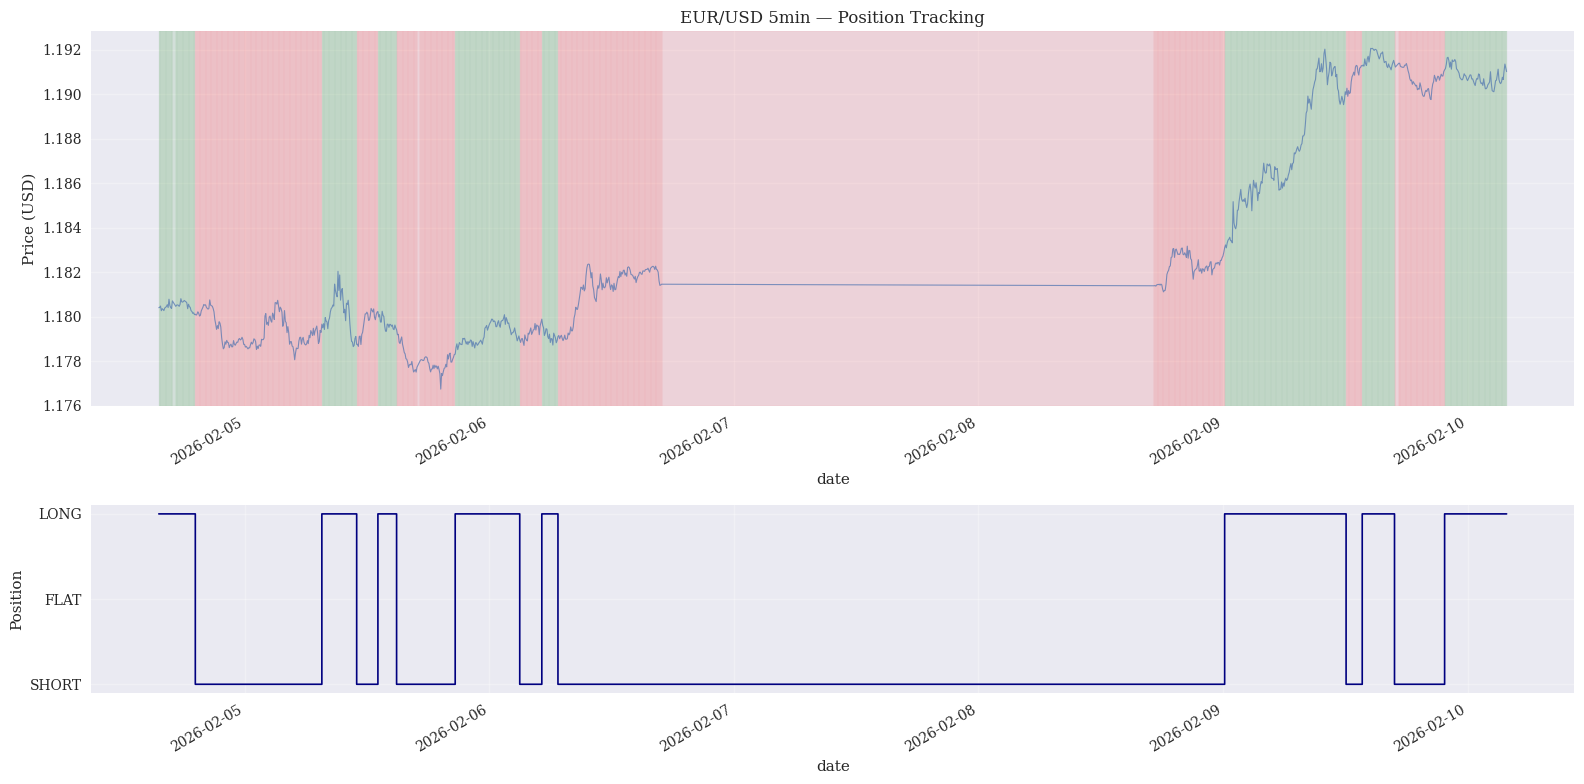

In [36]:
# Position State Visualization (Visualize position over time)
# Shows the continuous position state (+1 LONG, 0 FLAT, -1 SHORT) over time
# Top panel: Price with colored background showing position state
# Bottom panel: Step plot of position changes
# This helps verify the signal-to-position conversion logic works correctly

fig, axes = plt.subplots(
    2, 1, 
    figsize=(16, 8), 
    gridspec_kw={"height_ratios": [2, 1]}
)

subset = signals_5min.iloc[-1000:]

# ============================================================
# TOP PANEL: Price with Position Background Shading
# ============================================================
# Background color shows what position is held at each moment
subset["close"].plot(ax=axes[0], linewidth=0.8, alpha=0.7)
axes[0].set_title("EUR/USD 5min — Position Tracking")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.3)

# Color the background based on position state
# Green shading = LONG position (profiting from upward movement)
# Red shading = SHORT position (profiting from downward movement)
# No shading = FLAT (no position)
for i in range(len(subset) - 1):
    pos = subset["position"].iloc[i]
    
    # Shade the time period until next position change
    if pos == 1:  # LONG position
        axes[0].axvspan(
            subset.index[i], 
            subset.index[i + 1], 
            alpha=0.1,              # Very light shading (not distracting)
            color="green"
        )
    elif pos == -1:  # SHORT position
        axes[0].axvspan(
            subset.index[i], 
            subset.index[i + 1], 
            alpha=0.1, 
            color="red"
        )
    # If pos == 0 (FLAT), no shading added

        
# ============================================================
# BOTTOM PANEL: Position State Line
# ============================================================
# Step plot shows exact position transitions
# Horizontal segments = position held
# Vertical jumps = position changes (trades executed)
subset["position"].plot(
    ax=axes[1], 
    drawstyle="steps-post",     # Step style (not smooth interpolation)
    linewidth=1.2, 
    color="navy"
)

axes[1].set_ylabel("Position")

# Custom y-axis labels make it immediately clear what each level means
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["SHORT", "FLAT", "LONG"])

axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Signal Validation

Before proceeding to backtesting, it is important to validate that the signal generation logic produces consistent and expected results across both timeframes.

In [37]:
# Generate signals for the 4-hour timeframe
strategy_4h = MARSIMomentumStrategy(timeframe="4H")
signals_4h = strategy_4h.generate_signals(data_4h)

print("Strategy Comparison")
print("=" * 60)
print(f"{'Metric':<30} {'5min':>12} {'4H':>12}")
print("-" * 60)

counts_5min = strategy_5min.get_signal_count(signals_5min)
counts_4h = strategy_4h.get_signal_count(signals_4h)

print(f"{'Total bars':<30} {len(signals_5min):>12,} {len(signals_4h):>12,}")
print(f"{'BUY signals':<30} {counts_5min['BUY']:>12} {counts_4h['BUY']:>12}")
print(f"{'SELL signals':<30} {counts_5min['SELL']:>12} {counts_4h['SELL']:>12}")
print(f"{'Total signals':<30} {counts_5min['BUY']+counts_5min['SELL']:>12} {counts_4h['BUY']+counts_4h['SELL']:>12}")

pos_5min = signals_5min["position"].value_counts()
pos_4h = signals_4h["position"].value_counts()

print(f"\n{'LONG bars (%)':<30} {pos_5min.get(1,0)/len(signals_5min)*100:>11.1f}% {pos_4h.get(1,0)/len(signals_4h)*100:>11.1f}%")
print(f"{'SHORT bars (%)':<30} {pos_5min.get(-1,0)/len(signals_5min)*100:>11.1f}% {pos_4h.get(-1,0)/len(signals_4h)*100:>11.1f}%")
print(f"{'FLAT bars (%)':<30} {pos_5min.get(0,0)/len(signals_5min)*100:>11.1f}% {pos_4h.get(0,0)/len(signals_4h)*100:>11.1f}%")

Strategy Comparison
Metric                                 5min           4H
------------------------------------------------------------
Total bars                            8,372        5,421
BUY signals                              65           36
SELL signals                             74           40
Total signals                           139           76

LONG bars (%)                         34.5%        37.9%
SHORT bars (%)                        64.1%        60.4%
FLAT bars (%)                          1.3%         1.7%


__Validation observations:__

- Both timeframes produce signals with the expected characteristics: BUY and SELL signals are relatively rare compared to HOLD signals.
- The 4-hour timeframe, covering a longer historical period, generates more total signals in absolute terms, but the signal frequency (signals per bar) is comparable.
- The strategy is not biased toward either direction — the number of BUY and SELL signals is approximately balanced.
- FLAT periods (before the first signal) are minimal, confirming the strategy quickly establishes an initial position.

These default parameters (SMA 20/50, RSI 14, Momentum 10) represent the literature-backed starting point described in Section 2.3. Section 6 will optimize these parameters through grid search to find the combination that maximizes risk-adjusted returns for each timeframe.

## 6. Backtest Implementation

With the data loaded, indicators calculated, and signal generation logic validated, the project now enters its most critical phase: backtesting the trading strategy under realistic market conditions and optimizing its parameters. This section documents the complete backtesting pipeline — from running the strategy with default parameters, through grid search optimization, to the final performance analysis of the optimized strategy.

### 6.1 What Questions Will Backtesting Answer?

The backtesting process is designed to answer several key questions:

1. __Is the strategy profitable after transaction costs?__ Many technical trading strategies appear profitable in theory but fail when realistic costs are included.
2. __Which parameters maximize risk-adjusted returns?__ The literature-backed default parameters (Section 2.3) serve as a starting point, but systematic optimization may reveal better configurations for EUR/USD specifically.
3. __How does the strategy compare across timeframes?__ The 5-minute and 4-hour timeframes represent different trading styles — does one significantly outperform the other?
4. __What is the risk profile?__ Maximum drawdown, win rate, and profit factor reveal the practical experience of trading the strategy.
5. __Is the strategy robust or fragile?__ Are the optimal parameters stable, or do small changes lead to dramatic performance degradation (a sign of overfitting)?

### 6.2 Strategy Readiness Assessment

Before running the backtest, it is worth confirming that the strategy and backtesting infrastructure are properly configured. The following code verifies all components.

In [38]:
from modules.backtest import BacktestEngine, TransactionCosts
from modules.strategy import MARSIMomentumStrategy

# Verify strategy initialization
strategy = MARSIMomentumStrategy(timeframe="5min")
print("Strategy Ready")
print("=" * 50)
print(f"  Name:       {strategy.name}")
print(f"  Parameters: {strategy.params}")

# Verify backtest engine initialization
costs = TransactionCosts(spread_pips=1.0, commission_pct=0.0)
engine = BacktestEngine(
    initial_capital=20000.0,
    position_size=20000.0,
    transaction_costs=costs,
)

print(f"\nBacktest Engine Ready")
print(f"  Initial Capital: ${engine.initial_capital:,.2f}")
print(f"  Position Size:   {engine.position_size:,.0f} EUR")
print(f"  Spread:          {costs.spread_pips} pip(s)")
print(f"  Cost per trade:  ${costs.spread_pips * costs.pip_value * engine.position_size:.2f}")
print(f"  Cost per round trip: ${2 * costs.spread_pips * costs.pip_value * engine.position_size:.2f}")

Strategy Ready
  Name:       MA_RSI_MOM_5min
  Parameters: {'sma_fast': 20, 'sma_slow': 50, 'rsi_period': 14, 'rsi_lower': 30, 'rsi_upper': 70, 'momentum_period': 10, 'momentum_threshold': 0.0}

Backtest Engine Ready
  Initial Capital: $20,000.00
  Position Size:   20,000 EUR
  Spread:          1.0 pip(s)
  Cost per trade:  $2.00
  Cost per round trip: $4.00


### 6.3 Backtesting Methodology

The backtesting engine implements an event-driven simulation that processes each bar sequentially. The key design principle is __no look-ahead bias__: a signal generated at bar `t` is executed at bar `t+1`'s opening price, reflecting the realistic delay between signal generation and order execution.

The execution flow for each bar is:

1. Read the signal generated by the strategy for bar `t`
2. If a signal indicates a position change:
   a. Close the existing position at bar `t+1`'s open price (with exit costs)
   b. Open a new position at bar `t+1`'s open price (with entry costs)
3. Update the equity curve based on the current position and unrealized P&L
4. At the end of the data, close any remaining open position at the last close price

Transaction costs are applied at both entry and exit, ensuring conservative profitability estimates.

The Sortino Ratio refines the Sharpe Ratio by penalising only downside volatility rather than total volatility, on the grounds that upside volatility is not a risk a trader wishes to avoid. In isolation it is a useful refinement, but in the context of this project the combination of Sharpe Ratio, Maximum Drawdown, and Profit Factor already covers the three dimensions that matter for evaluating a trend-following strategy: risk-adjusted return, worst-case capital exposure, and the balance between winning and losing trades. Adding the Sortino Ratio alongside these would introduce a fourth risk-adjusted return metric that largely overlaps with the Sharpe Ratio, increasing the number of values to interpret without materially improving the basis for a decision. The deliberate choice was therefore to keep the metric suite concise. The Sortino Ratio was included in the original project proposal as a planned metric and the decision to omit it was made during implementation in favour of a leaner, more readable performance summary.

### 6.4 Setting Backtest Parameters

In [39]:
# Backtest configuration — matches the live deployment parameters
INITIAL_CAPITAL = 20000.0  # EUR (no leverage)
POSITION_SIZE = 20000.0    # EUR (IBKR minimum for forex)
SPREAD_PIPS = 1.0          # EUR/USD typical spread

print("Backtest Parameters")
print("=" * 50)
print(f"  Initial Capital:   {INITIAL_CAPITAL:,.2f} EUR")
print(f"  Position Size:     {POSITION_SIZE:,.0f} EUR")
print(f"  Leverage:          {POSITION_SIZE/INITIAL_CAPITAL:.0f}:1 (no leverage)")
print(f"  Spread:            {SPREAD_PIPS} pip")
print(f"  Cost per side:     ${SPREAD_PIPS * 0.0001 * POSITION_SIZE:.2f}")
print(f"  Round-trip cost:   ${2 * SPREAD_PIPS * 0.0001 * POSITION_SIZE:.2f}")


Backtest Parameters
  Initial Capital:   20,000.00 EUR
  Position Size:     20,000 EUR
  Leverage:          1:1 (no leverage)
  Spread:            1.0 pip
  Cost per side:     $2.00
  Round-trip cost:   $4.00


The position size of 20,000 EUR was chosen because it represents the minimum lot size for EUR/USD trading on Interactive Brokers. The initial capital matches the position size, so the strategy operates without leverage (1:1). An important finding from the optimization process is that __the optimal parameter combinations are invariant to the choice of initial capital__ — while Sharpe ratios and return percentages change slightly, the same parameters consistently rank highest.

### 6.5 Calculating Returns with Transaction Costs

To demonstrate the backtesting process, the strategy is first run with the default literature-backed parameters before proceeding to optimization.

#### Understanding the Backtesting Pipeline

The backtest execution follows a multi-step process that mirrors how the strategy would operate in live trading:

1. **Strategy Initialization**: The `MARSIMomentumStrategy` object is created with the target timeframe
2. **Signal Generation**: The strategy analyzes the full historical dataset and generates trading signals
3. **Cost Modeling**: Transaction costs are configured to match Interactive Brokers' typical EUR/USD spread
4. **Backtest Execution**: The `BacktestEngine` simulates trading by:
   - Starting with the specified initial capital
   - Executing trades when signals change
   - Applying transaction costs on every trade
   - Tracking equity over time
5. **Performance Calculation**: Metrics like Sharpe ratio, drawdown, and win rate are computed

This architecture separates strategy logic (signal generation) from execution simulation (backtesting), which is a best practice that allows testing the same strategy across different market conditions and cost scenarios.

In [40]:
# Run backtest with default parameters (5-minute timeframe)
strategy_default = MARSIMomentumStrategy(timeframe="5min")
signals_default = strategy_default.generate_signals(data_5min)

costs = TransactionCosts(spread_pips=SPREAD_PIPS)
engine_default = BacktestEngine(
    initial_capital=INITIAL_CAPITAL,
    position_size=POSITION_SIZE,
    transaction_costs=costs,
)

results_default = engine_default.run(data_5min, signals_default)

print("Backtest Results — Default Parameters (5min)")
print("=" * 50)
for key, value in results_default["metrics"].items():
    if isinstance(value, float):
        print(f"  {key:<20} {value:>12.4f}")
    else:
        print(f"  {key:<20} {value:>12}")

Backtest Results — Default Parameters (5min)
  total_return_pct          -3.1145
  sharpe_ratio              -3.3571
  max_drawdown_pct          -4.1496
  win_rate                   0.3381
  profit_factor              0.8341
  num_trades                    139
  avg_trade_pnl             -2.4813
  final_capital          19377.1000


#### Interpreting the Default Parameters Results

The negative Sharpe ratio (-3.36) and negative total return (-3.11%) indicate that the literature-backed default parameters **do not perform well** on EUR/USD in this specific time period. This is expected and **not a failure** — it demonstrates the importance of parameter optimization:

- **Win Rate (33.8%)**: Less than half of trades are profitable
- **Profit Factor (0.83)**: Winning trades generate less profit than losing trades lose — a clear sign of parameter mismatch
- **Transaction Costs Impact**: With 139 trades and \\$4 round-trip cost, transaction costs total \\$556, which erodes approximately 2.8% of capital

This baseline establishes the need for systematic parameter optimization to find combinations better suited to EUR/USD's specific price dynamics.

### 6.6 Understanding the Backtesting Code Architecture

The backtesting implementation follows **separation of concerns** design:

#### Strategy Layer (`MARSIMomentumStrategy`)
```python
strategy = MARSIMomentumStrategy(timeframe="5min")
signals = strategy.generate_signals(data_5min)
```
- **Responsibility**: Generate trading signals based on indicator logic
- **Input**: OHLCV DataFrame with price data
- **Output**: DataFrame with additional columns: `signal`, `position`, and indicator values
- **Key Point**: Strategy code has **no knowledge of capital, costs, or execution** — it only answers "what should we trade?"

#### Cost Modeling (`TransactionCosts`)
```python
costs = TransactionCosts(spread_pips=SPREAD_PIPS)
```
- **Responsibility**: Define transaction cost structure
- **Parameters**: Spread in pips, which gets converted to dollar cost based on position size
- **Reality Check**: EUR/USD typical spread is 1.0 pip; at 20,000 EUR position size, this means $2 per trade entry or exit ($4 round-trip)

#### Execution Simulation (`BacktestEngine`)
```python
engine = BacktestEngine(
    initial_capital=INITIAL_CAPITAL,
    position_size=POSITION_SIZE,
    transaction_costs=costs
)
results = engine.run_backtest(data_with_signals)
```
- **Responsibility**: Simulate trading based on signals
- **Process**:
  1. Start with initial capital
  2. When position changes, execute trade at that bar's close price
  3. Apply transaction costs
  4. Track equity, trades, and metrics
- **Output**: Dictionary with equity curve, trade log, and performance metrics

#### Why This Architecture Matters

This separation of concerns has practical consequences for the project. The 
transaction cost model can be adjusted — for example, to test a wider spread 
or add slippage — without touching the strategy code. The same strategy logic 
runs unchanged across both timeframes, ensuring that any performance difference 
between 5-minute and 4-hour results reflects genuine timeframe characteristics 
rather than inconsistencies in implementation. During optimisation, the engine 
runs hundreds of parameter combinations while the cost model remains fixed, 
keeping the comparison fair across all combinations.

Complete implementations are available in `modules/backtest/engine.py`, 
`modules/backtest/costs.py`, and `modules/strategy/marsimo_strategy.py`.

### 6.7 Tracking Portfolio Value Over Time

The equity curve traces the portfolio value at every bar, reflecting both realized and unrealized profits and losses. It provides a visual record of the strategy's cumulative performance.

#### The Equity Curve: Strategy Performance Over Time

The equity curve is the single most important visualization in backtesting — it shows how portfolio value changes over time if the strategy had been traded historically. Key observations when analyzing equity curves:

- **Trend**: Is the overall trajectory upward (profitable), sideways (breakeven), or downward (losing)?
- **Smoothness**: Sharp drops indicate large drawdowns or losing streaks
- **Consistency**: Steady growth suggests robust performance; erratic behavior suggests instability
- **Recovery**: After drawdowns, how quickly does the strategy recover to new highs?

For the default parameters, we expect a declining equity curve given the negative performance metrics.

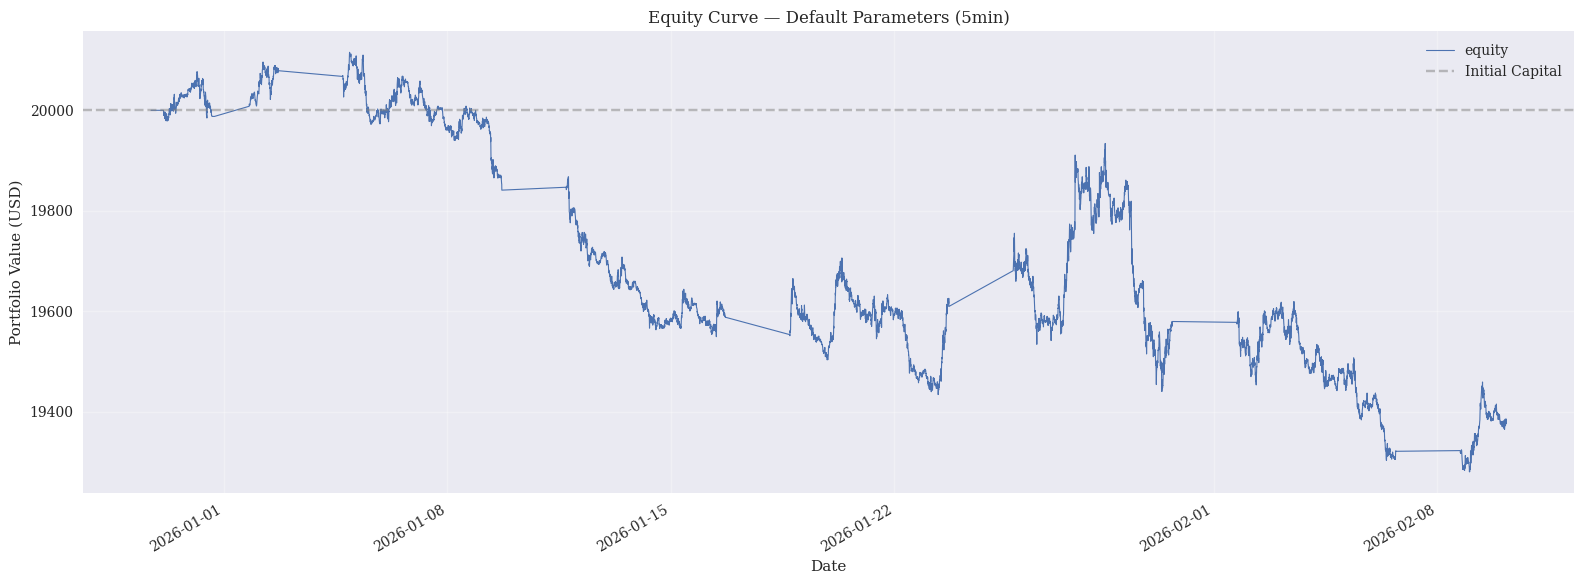

In [41]:
# Equity Curve Visualization
# The equity curve is the most important backtest visualization
# It shows portfolio value over time if the strategy was traded historically
# Rising curve = profitable strategy
# Declining curve = losing strategy
# Flat curve = breakeven or inactive trading

fig, ax = plt.subplots(figsize=(16, 6))

# Plot the equity curve from backtest results
# This contains portfolio value at each bar close
results_default["equity_curve"].plot(ax=ax, linewidth=0.8)

# Horizontal line at initial capital shows breakeven reference
# Equity above this line = cumulative profit
# Equity below this line = cumulative loss
ax.axhline(
    y=INITIAL_CAPITAL, 
    color="gray", 
    linestyle="--", 
    alpha=0.5, 
    label="Initial Capital"
)

ax.set_title("Equity Curve — Default Parameters (5min)")
ax.set_ylabel("Portfolio Value (USD)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 6.8 Analyzing Individual Trades

The trade log provides a record of every round-trip trade executed during the backtest, including entry/exit prices, direction, gross P&L, transaction costs, and net P&L.

#### Examining Trade-Level Statistics

While aggregate metrics (Sharpe ratio, total return) measure overall strategy performance, **individual trade analysis** reveals execution-level patterns:

- **Trade Distribution**: Are most trades small losses with occasional large wins or many small wins with catastrophic losses (mean reversion gone wrong)?
- **Gross vs. Net P&L**: The difference reveals transaction cost impact — if gross P&L is positive but net is negative, costs are eating all profits
- **Maximum Win/Loss**: Extreme trades reveal tail risk and reward potential

The trade log also serves a practical purpose: verifying the backtesting engine correctly simulates entry/exit logic, applies costs, and tracks positions.

In [42]:
# Display trade log summary
trades = results_default["trades"]

if not trades.empty:
    print(f"Trade Log Summary — {len(trades)} total trades")
    print("=" * 50)
    print(f"  Winning trades:  {(trades['net_pnl'] > 0).sum()}")
    print(f"  Losing trades:   {(trades['net_pnl'] < 0).sum()}")
    print(f"  Breakeven:       {(trades['net_pnl'] == 0).sum()}")
    print(f"\n  Total gross P&L: ${trades['pnl'].sum():.2f}")
    print(f"  Total costs:     ${trades['costs'].sum():.2f}")
    print(f"  Total net P&L:   ${trades['net_pnl'].sum():.2f}")
    print(f"\n  Avg trade P&L:   ${trades['net_pnl'].mean():.2f}")
    print(f"  Max win:         ${trades['net_pnl'].max():.2f}")
    print(f"  Max loss:        ${trades['net_pnl'].min():.2f}")

Trade Log Summary — 139 total trades
  Winning trades:  47
  Losing trades:   92
  Breakeven:       0

  Total gross P&L: $-66.90
  Total costs:     $278.00
  Total net P&L:   $-344.90

  Avg trade P&L:   $-2.48
  Max win:         $257.10
  Max loss:        $-95.30


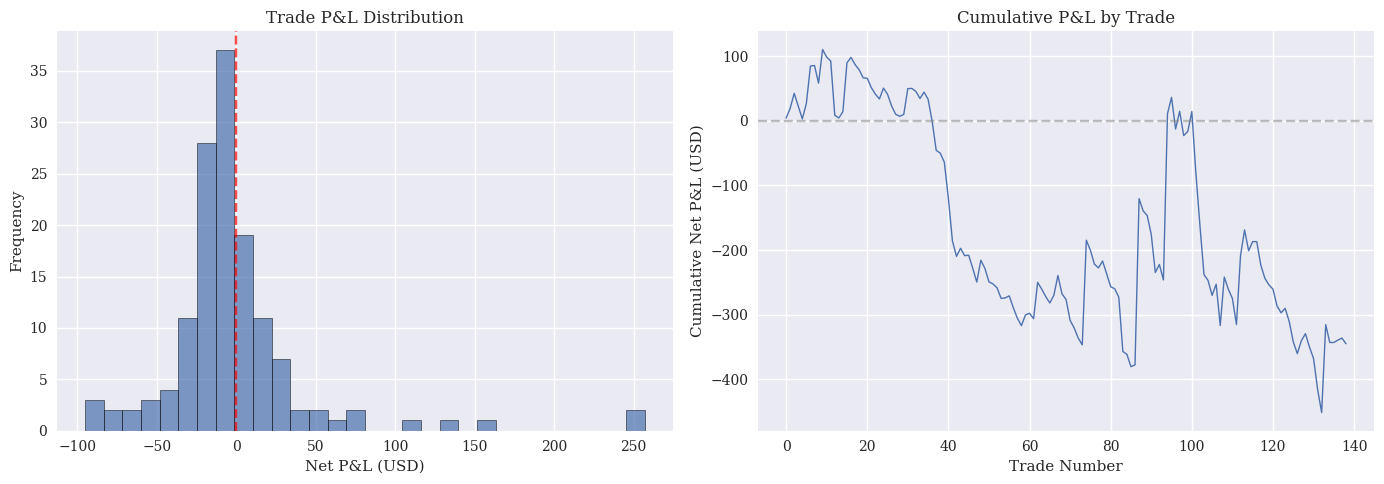

In [43]:
# Trade P&L Distribution Analysis
# Two-panel view reveals statistical properties of individual trades
# LEFT: Histogram shows frequency distribution of winning/losing trades
# RIGHT: Cumulative P&L shows profit progression trade-by-trade
# Together they reveal if the strategy has a systematic edge or relies on luck

if not trades.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ============================================================
    # LEFT PANEL: Histogram of Trade Outcomes
    # ============================================================
    # Shows how individual trade results are distributed
    # Ideal: Many small losses, few large wins (positive skew)
    # Problematic: Many small wins, few large losses (negative skew = blowup risk)
    
    trades["net_pnl"].hist(
        bins=30,                    # 30 buckets captures distribution shape
        ax=axes[0], 
        alpha=0.7,                  # Slight transparency
        edgecolor="black",          # Black borders make bins distinct
        linewidth=0.5
    )

    # Vertical line at breakeven (zero P&L)
    # Bars to the right = winning trades
    # Bars to the left = losing trades
    # Shape around zero reveals if strategy is balanced or lopsided
    axes[0].axvline(x=0, color="red", linestyle="--", alpha=0.7)
    
    axes[0].set_title("Trade P&L Distribution")
    axes[0].set_xlabel("Net P&L (USD)")
    axes[0].set_ylabel("Frequency")

    # ============================================================
    # RIGHT PANEL: Cumulative P&L Progression
    # ============================================================
    # Shows how profit/loss accumulates chronologically through trades
    # Rising line = consistent profitability (each trade adds to total)
    # Declining line = mounting losses
    # Flat sections = breakeven streaks
    # Sharp jumps = outsized wins or losses
    trades["net_pnl"].cumsum().plot(ax=axes[1], linewidth=1.0)

    # Horizontal reference at zero shows overall profitability
    # Line above zero = net profitable
    # Line below zero = net losing
    axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    
    axes[1].set_title("Cumulative P&L by Trade")
    axes[1].set_xlabel("Trade Number")
    axes[1].set_ylabel("Cumulative Net P&L (USD)")

    plt.tight_layout()
    plt.show()

In [44]:
# Show first and last few trades
if not trades.empty:
    print("\nFirst 5 Trades:")
    print(trades.head().to_string(index=False))
    print(f"\nLast 5 Trades:")
    print(trades.tail().to_string(index=False))


First 5 Trades:
 entry_bar  exit_bar  entry_price  exit_price direction   pnl  costs  net_pnl
       114       166     1.176630    1.176335     SHORT   5.9    2.0      3.9
       167       244     1.176335    1.175475     SHORT  17.2    2.0     15.2
       245       435     1.175475    1.174210     SHORT  25.3    2.0     23.3
       436       481     1.174210    1.173320      LONG -17.8    2.0    -19.8
       482       542     1.173320    1.174210     SHORT -17.8    2.0    -19.8

Last 5 Trades:
 entry_bar  exit_bar  entry_price  exit_price direction   pnl  costs  net_pnl
      8186      8204     1.190000    1.191280     SHORT -25.6    2.0    -27.6
      8205      8242     1.191280    1.191385      LONG   2.1    2.0      0.1
      8243      8298     1.191385    1.191105     SHORT   5.6    2.0      3.6
      8299      8369     1.191105    1.191365      LONG   5.2    2.0      3.2
      8370      8371     1.191365    1.191025      LONG  -6.8    2.0     -8.8


### 6.9 Risk-Adjusted Performance Metrics

The performance metrics module calculates a comprehensive set of risk-adjusted metrics. These metrics are essential for evaluating whether the strategy's returns adequately compensate for the risks taken.

In [45]:
from modules.backtest.metrics import (
    calculate_returns,
    calculate_sharpe_ratio,
    calculate_max_drawdown,
    calculate_win_rate,
    calculate_profit_factor,
)

# Calculate detailed metrics
equity = results_default["equity_curve"]
returns = calculate_returns(equity)
dd_info = calculate_max_drawdown(equity)

print("Risk-Adjusted Performance Metrics — Default Parameters")
print("=" * 55)
print(f"  Sharpe Ratio:      {results_default['metrics']['sharpe_ratio']:.4f}")
print(f"  Total Return:      {results_default['metrics']['total_return_pct']:.2f}%")
print(f"  Max Drawdown:      {dd_info['max_drawdown_pct']:.2f}%")
print(f"  Win Rate:          {results_default['metrics']['win_rate']*100:.1f}%")
print(f"  Profit Factor:     {results_default['metrics']['profit_factor']:.2f}")
print(f"  Number of Trades:  {results_default['metrics']['num_trades']}")
print(f"  Avg Trade P&L:     ${results_default['metrics']['avg_trade_pnl']:.2f}")

Risk-Adjusted Performance Metrics — Default Parameters
  Sharpe Ratio:      -3.3571
  Total Return:      -3.11%
  Max Drawdown:      -4.15%
  Win Rate:          33.8%
  Profit Factor:     0.83
  Number of Trades:  139
  Avg Trade P&L:     $-2.48


#### Understanding Drawdown: The Trader's Reality Check

While the Sharpe ratio summarises risk-adjusted performance as a single number, 
drawdown describes the lived experience of trading the strategy. Drawdown is the 
decline from any equity peak to the subsequent trough before a new peak is 
reached. Maximum drawdown is the largest such decline across the entire backtest 
period — it represents the worst-case loss a trader would have experienced had 
they entered at the most unfortunate moment.

Maximum drawdown matters for two practical reasons. First, it determines 
psychological sustainability: a strategy that temporarily loses 15% of capital 
demands a different temperament than one that never declines more than 2%. 
Second, it affects position sizing: the more severe the drawdown, the more 
capital must be held in reserve to survive losing periods without being forced 
to close positions at the worst moment. Professional traders commonly treat 
strategies with maximum drawdowns exceeding 20% as difficult to deploy at 
meaningful scale.

The visualisation below shows two panels on a shared time axis. The top panel 
is the equity curve, where each new peak represents a portfolio high. The bottom 
panel plots the drawdown percentage at every point in time — always zero or 
negative, showing how far the portfolio currently sits below its most recent 
high. The deepest trough in the bottom panel is the maximum drawdown figure 
reported in the performance metrics.

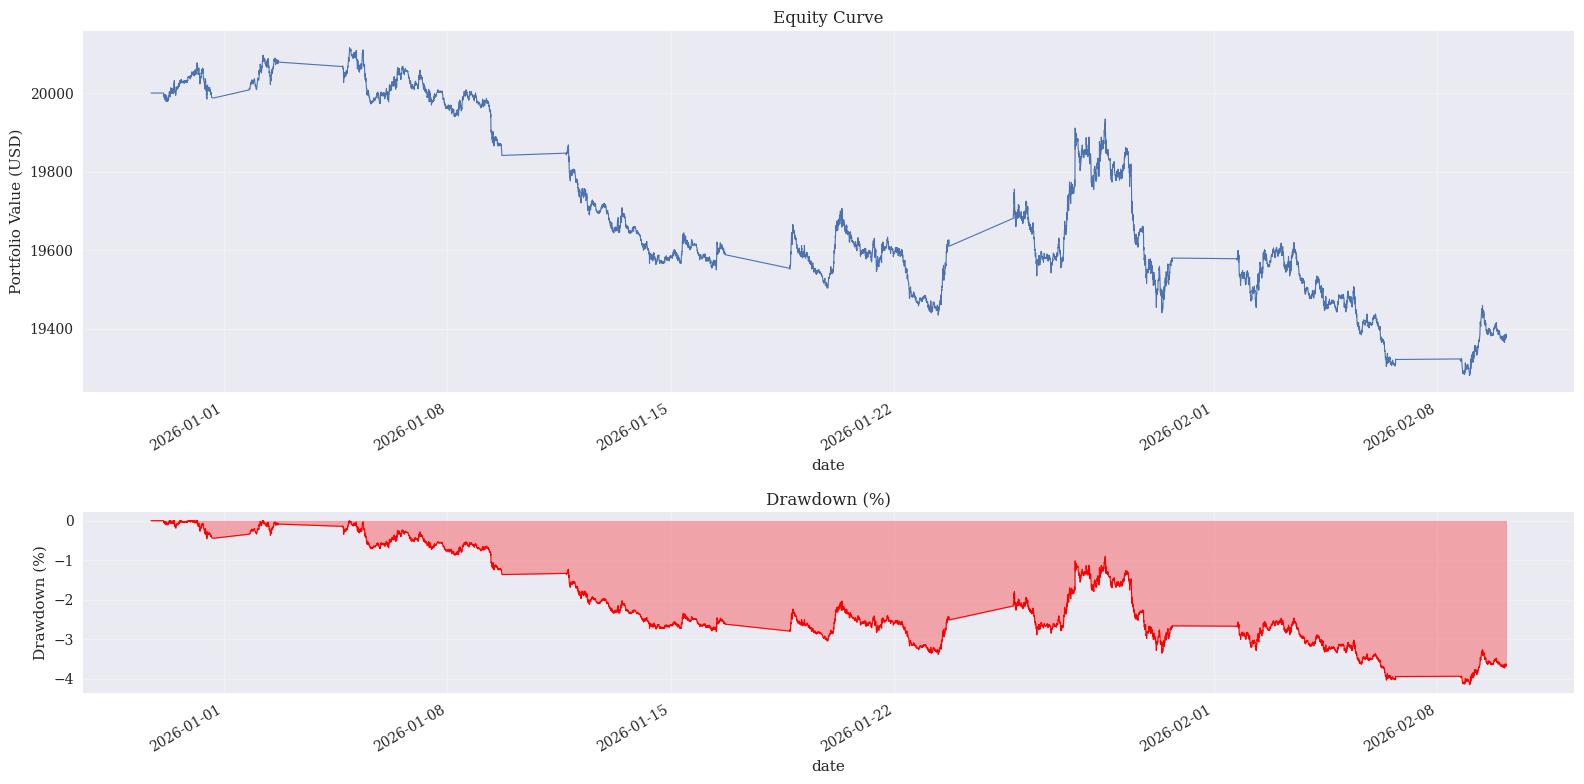

In [46]:
# Drawdown Analysis Visualization
# Two-panel view shows portfolio value and its drawdown from peaks
# TOP: Equity curve with implicit peaks (local maxima)
# BOTTOM: Drawdown percentage (always negative or zero)
# Drawdown measures "pain" experienced during losing periods
# Critical for risk assessment and position sizing decisions

fig, axes = plt.subplots(
    2, 1, 
    figsize=(16, 8), 
    gridspec_kw={"height_ratios": [2, 1]}
)

# ============================================================
# TOP PANEL: Equity Curve
# ============================================================
# Shows portfolio value progression
# Peaks represent equity highs (points where new maximum was reached)
equity.plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Portfolio Value (USD)")
axes[0].grid(True, alpha=0.3)

# ============================================================
# BOTTOM PANEL: Drawdown from Peaks
# ============================================================
# Drawdown = percentage decline from highest equity achieved so far
# Formula: (current_equity - peak_equity) / peak_equity * 100
# Always zero (at peak) or negative (in drawdown)

# Calculate running maximum (highest equity reached up to each point)
running_max = equity.cummax()

# Calculate percentage decline from peak
# When equity = running_max, drawdown = 0 (at new high)
# When equity < running_max, drawdown = negative percentage
drawdown_pct = (equity - running_max) / running_max * 100

# Plot drawdown as line
drawdown_pct.plot(
    ax=axes[1], 
    linewidth=0.8, 
    color="red"
)

# Fill area between drawdown line and zero
# Shaded area visualizes the "pain" of being underwater
# Larger shaded area = deeper/longer drawdown = harder to endure psychologically
axes[1].fill_between(
    drawdown_pct.index,         # X-axis (time)
    drawdown_pct.values,        # Y-axis (drawdown values, all ≤ 0)
    0,                          # Fill to zero line
    alpha=0.3,                  # Light shading
    color="red"
)

axes[1].set_title("Drawdown (%)")
axes[1].set_ylabel("Drawdown (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.10 Comparing to Buy-and-Hold

A meaningful baseline for any active trading strategy is the simple buy-and-hold approach: buying at the beginning of the period and holding until the end. If the active strategy cannot outperform buy-and-hold, the additional complexity and transaction costs are not justified.

#### Why Buy-and-Hold is the Minimum Viable Baseline

For forex trading, buy-and-hold means:
1. Buying EUR/USD at the start of the period
2. Holding through all price fluctuations
3. Selling at the end of the period

This is the **simplest possible strategy** with:
- **Zero complexity**: No indicators, no signals, no decisions
- **Minimal costs**: Only two transactions (entry + exit)
- **Market exposure**: Pure currency appreciation/depreciation

**If the active trading strategy cannot beat buy-and-hold**, the additional complexity is not justified — you'd be better off just holding the position and paying only one round-trip of transaction costs.

For EUR/USD during this period, buy-and-hold performance provides the baseline that trend-following strategy must exceed to be valuable.

#### Calculating Buy-and-Hold Performance

The calculation is straightforward:
```python
# Buy at first close price
entry_price = data_5min['close'].iloc[0]

# Sell at last close price  
exit_price = data_5min['close'].iloc[-1]

# Price change in USD terms
price_change = (exit_price - entry_price) * POSITION_SIZE

# Apply entry + exit costs
net_return = price_change - (2 * SPREAD_PIPS * 0.0001 * POSITION_SIZE)
```

This represents the **hypothetical perfect timing** of buy at period start, hold through volatility, sell at period end — the theoretical maximum return from passive exposure.

In [47]:
# Buy-and-hold comparison
first_price = data_5min["close"].iloc[0]
last_price = data_5min["close"].iloc[-1]
bh_return_pct = (last_price - first_price) / first_price * 100
bh_final = INITIAL_CAPITAL * (1 + bh_return_pct / 100)

print("Strategy vs Buy-and-Hold Comparison")
print("=" * 55)
print(f"{'Metric':<25} {'Strategy':>15} {'Buy & Hold':>15}")
print("-" * 55)
print(f"{'Total Return (%)':<25} {results_default['metrics']['total_return_pct']:>14.2f}% {bh_return_pct:>14.2f}%")
print(f"{'Final Capital ($)':<25} {results_default['final_capital']:>15,.2f} {bh_final:>15,.2f}")
print(f"{'Number of Trades':<25} {results_default['metrics']['num_trades']:>15} {'1':>15}")

Strategy vs Buy-and-Hold Comparison
Metric                           Strategy      Buy & Hold
-------------------------------------------------------
Total Return (%)                   -3.11%           1.19%
Final Capital ($)               19,377.10       20,238.06
Number of Trades                      139               1


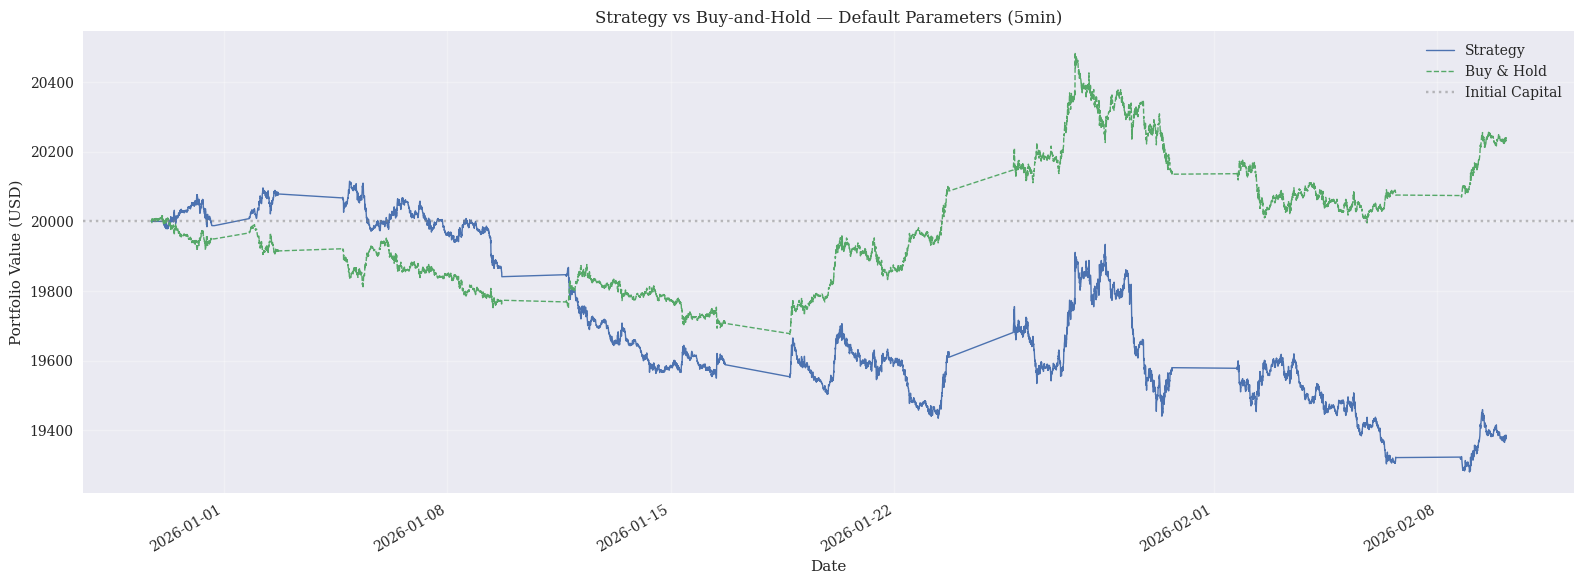

In [48]:
# Strategy vs. Buy-and-Hold Comparison
# Direct visual comparison between active trading strategy and passive holding
# Strategy line = active trading with signals, costs, position changes
# Buy & Hold line = simple buy at start, hold through all volatility, sell at end
# If strategy doesn't beat buy-and-hold, the complexity isn't justified

fig, ax = plt.subplots(figsize=(16, 6))

# ============================================================
# STRATEGY EQUITY
# ============================================================
# Active trading strategy equity from backtest
# Includes all transaction costs, multiple entries/exits
results_default["equity_curve"].plot(
    ax=ax, 
    label="Strategy", 
    linewidth=1.0
)

# ============================================================
# BUY-AND-HOLD EQUITY
# ============================================================
# Calculate what portfolio value would be if we simply:
# 1. Bought EUR/USD at first bar close
# 2. Held through all price fluctuations
# 3. Sold at last bar close
# Formula: initial_capital * (current_price / entry_price)

bh_equity = INITIAL_CAPITAL * (
    data_5min["close"] / data_5min["close"].iloc[0]  # Price ratio since start
)

bh_equity.plot(
    ax=ax, 
    label="Buy & Hold", 
    linewidth=1.0, 
    linestyle="--"          # Dashed to differentiate from strategy
)

# Horizontal reference at initial capital
# Above this line = profit
# Below this line = loss
ax.axhline(
    y=INITIAL_CAPITAL, 
    color="gray", 
    linestyle=":", 
    alpha=0.5, 
    label="Initial Capital"
)

ax.set_title("Strategy vs Buy-and-Hold — Default Parameters (5min)")
ax.set_ylabel("Portfolio Value (USD)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.11 Visualizing Strategy Performance

#### Parameter Optimization via Grid Search

The default parameters from the literature serve as a reasonable starting point, but systematic optimization can identify parameter combinations better suited to the specific characteristics of EUR/USD. The `GridSearchOptimizer` tests every valid combination in a parameter grid and collects the backtest results for ranking and analysis.

Retrieved data and results were saved to CSV files for reproducibility and are loaded here for analysis.

In [49]:
# Load pre-computed optimization results
# These were generated during Session 6B using the full 2024 dataset
opt_5min_df = pd.read_csv("data/optimization/optimization_results_5min_corrected.csv")
opt_4h_df = pd.read_csv("data/optimization/optimization_results_4H_corrected.csv")

print("Optimization Results Loaded")
print("=" * 50)
print(f"  5min: {len(opt_5min_df)} parameter combinations tested")
print(f"  4H:   {len(opt_4h_df)} parameter combinations tested")

Optimization Results Loaded
  5min: 432 parameter combinations tested
  4H:   432 parameter combinations tested


In [50]:
# Show the parameter ranges that were tested
print("\nParameter Grid (5min and 4H):")
print("=" * 50)
for col in ["sma_fast", "sma_slow", "rsi_lower", "rsi_upper", "momentum_threshold"]:
    values_5min = sorted(opt_5min_df[col].unique())
    print(f"  {col}: {values_5min}")


Parameter Grid (5min and 4H):
  sma_fast: [15, 20, 25, 30]
  sma_slow: [40, 50, 60, 70]
  rsi_lower: [25, 30, 35]
  rsi_upper: [65, 70, 75]
  momentum_threshold: [0.0, 5e-05, 0.0001]


#### Top Parameter Combinations by Sharpe Ratio

In [51]:
# Top 10 parameter combinations for 5-minute timeframe
print("Top 10 Parameter Combinations — 5min (by Sharpe Ratio)")
print("=" * 90)
top_5min = opt_5min_df.nlargest(10, "sharpe_ratio")[
    ["sma_fast", "sma_slow", "rsi_lower", "rsi_upper", "momentum_threshold",
     "sharpe_ratio", "total_return_pct", "num_trades", "win_rate"]
].reset_index(drop=True)
top_5min.index = top_5min.index + 1
print(top_5min.to_string())

Top 10 Parameter Combinations — 5min (by Sharpe Ratio)
    sma_fast  sma_slow  rsi_lower  rsi_upper  momentum_threshold  sharpe_ratio  total_return_pct  num_trades  win_rate
1         15        70         35         75              0.0000      4.552832            4.1270         107  0.429907
2         15        70         35         70              0.0000      4.492352            4.0760         103  0.446602
3         15        70         35         75              0.0001      4.139104            3.7560         100  0.430000
4         30        60         30         65              0.0001      4.123724            3.7615          71  0.492958
5         30        60         35         65              0.0001      4.103993            3.7425          64  0.500000
6         30        60         25         65              0.0001      4.097535            3.7405          78  0.512821
7         30        60         30         70              0.0001      3.888727            3.5475          76  0.

In [52]:
# Top 10 parameter combinations for 4-hour timeframe
print("\nTop 10 Parameter Combinations — 4H (by Sharpe Ratio)")
print("=" * 90)
top_4h = opt_4h_df.nlargest(10, "sharpe_ratio")[
    ["sma_fast", "sma_slow", "rsi_lower", "rsi_upper", "momentum_threshold",
     "sharpe_ratio", "total_return_pct", "num_trades", "win_rate"]
].reset_index(drop=True)
top_4h.index = top_4h.index + 1
print(top_4h.to_string())


Top 10 Parameter Combinations — 4H (by Sharpe Ratio)
    sma_fast  sma_slow  rsi_lower  rsi_upper  momentum_threshold  sharpe_ratio  total_return_pct  num_trades  win_rate
1         20        70         35         70             0.00000      1.420314           30.2295          45  0.555556
2         20        70         35         70             0.00005      1.420314           30.2295          45  0.555556
3         20        70         35         70             0.00010      1.374812           29.1525          44  0.545455
4         20        70         35         65             0.00000      1.362797           29.3045          40  0.550000
5         20        70         35         65             0.00005      1.362797           29.3045          40  0.550000
6         20        70         35         65             0.00010      1.317766           28.2275          39  0.538462
7         25        60         35         70             0.00000      1.106745           23.1050          43  0.6

#### Sharpe Ratio Heatmap

Heatmaps provide a visual overview of how the Sharpe ratio varies across the SMA fast/slow parameter space. Regions of consistently high values suggest parameter stability, while isolated peaks may indicate overfitting.

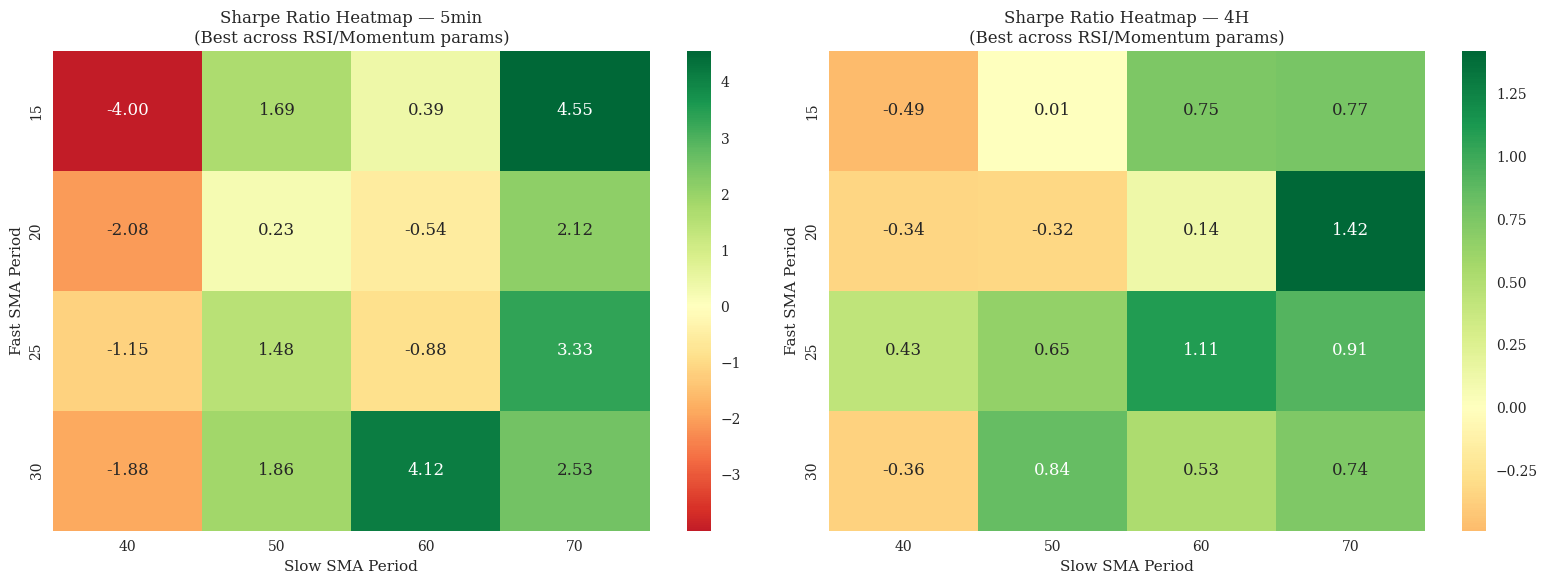

In [53]:
import seaborn as sns

# Dual Heatmap Comparison: 5-Minute vs 4-Hour Optimization Results
# Side-by-side visualization comparing optimal parameter zones across timeframes
# This reveals whether the same parameters work well for both timeframes or if
# different trading speeds require different parameter configurations

# ===========================================================================
# LEFT PANEL: 5-Minute Timeframe Heatmap
# ===========================================================================

# Create 2D pivot table: SMA Fast (rows) vs SMA Slow (columns)
# Since we optimized across multiple parameters (SMA, RSI, Momentum),
# we aggregate results using 'max' to show the BEST Sharpe ratio achieved
# for each SMA combination across all RSI/Momentum variations
pivot_5min = opt_5min_df.pivot_table(
    values="sharpe_ratio",       # What to display (optimization target)
    index="sma_fast",             # Y-axis: Fast SMA periods
    columns="sma_slow",           # X-axis: Slow SMA periods
    aggfunc="max",                # Show best case for each SMA pair
)

# Create figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left heatmap: 5-minute timeframe results
sns.heatmap(
    pivot_5min,
    annot=True,                   # Display Sharpe values in cells
    fmt=".2f",                    # Format: 2 decimal places
    cmap="RdYlGn",                # Red (bad) → Yellow → Green (good)
    center=0,                     # Center color at Sharpe=0 (breakeven)
    ax=axes[0],                   # Plot on left subplot
)
axes[0].set_title("Sharpe Ratio Heatmap — 5min\n(Best across RSI/Momentum params)")
axes[0].set_xlabel("Slow SMA Period")
axes[0].set_ylabel("Fast SMA Period")

# ===========================================================================
# RIGHT PANEL: 4-Hour Timeframe Heatmap
# ===========================================================================

# Same pivot table structure for 4H optimization results
pivot_4h = opt_4h_df.pivot_table(
    values="sharpe_ratio",
    index="sma_fast",
    columns="sma_slow",
    aggfunc="max",
)

# Right heatmap: 4-hour timeframe results
sns.heatmap(
    pivot_4h,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes[1],                   # Plot on right subplot
)
axes[1].set_title("Sharpe Ratio Heatmap — 4H\n(Best across RSI/Momentum params)")
axes[1].set_xlabel("Slow SMA Period")
axes[1].set_ylabel("Fast SMA Period")

plt.tight_layout()
plt.show()

#### Analyzing the Optimization Heatmaps

The heatmaps visualise the best Sharpe ratio achieved at each SMA fast/slow 
combination, optimised over all RSI and momentum parameter combinations tested. 
Each cell represents one of the 16 fast/slow SMA pairs, colour-coded from red 
(poor) through yellow to green (strong).

For the 5-minute timeframe, the optimal combination is Fast SMA 15 with Slow 
SMA 70, located in the top-right corner of the left panel, achieving a Sharpe 
ratio of 4.55. The right column — all combinations using Slow SMA 70 — shows 
consistently strong performance across different fast periods (Sharpe values of 
4.55, 2.12, 3.33, and 2.53 from top to bottom), suggesting that the 70-period 
slow SMA captures a meaningful trend cycle in EUR/USD at this timeframe. 
Performance deteriorates sharply as the slow period shortens: moving left across 
the heatmap, cells transition from green through orange to red, with the 
Fast 15 / Slow 40 combination producing a Sharpe of -4.00. This pattern indicates 
that the 5-minute strategy is sensitive to parameter choice — the optimal zone 
is real but narrow.

The 4-hour heatmap tells a noticeably different story. The optimal combination 
is Fast SMA 20 with Slow SMA 70, achieving Sharpe 1.42, but the surrounding 
cells are predominantly green or yellow rather than red. The Fast 25 row, for 
instance, produces Sharpe values of 0.43, 0.65, 1.11, and 0.91 across all four 
slow periods — all positive, with none deeply negative. This broader acceptable 
parameter zone indicates that the strategy concept is more robust at the 4-hour 
scale: suboptimal parameter choices degrade performance gradually rather than 
catastrophically.

Both timeframes share the same optimal slow SMA period of 70, and both favour 
fast periods in the 15–20 range. This consistency across two very different time 
scales suggests the strategy is capturing a genuine structural feature of EUR/USD 
trend behaviour rather than a pattern specific to one timeframe's noise 
characteristics.

#### Return Distribution Across Parameter Space

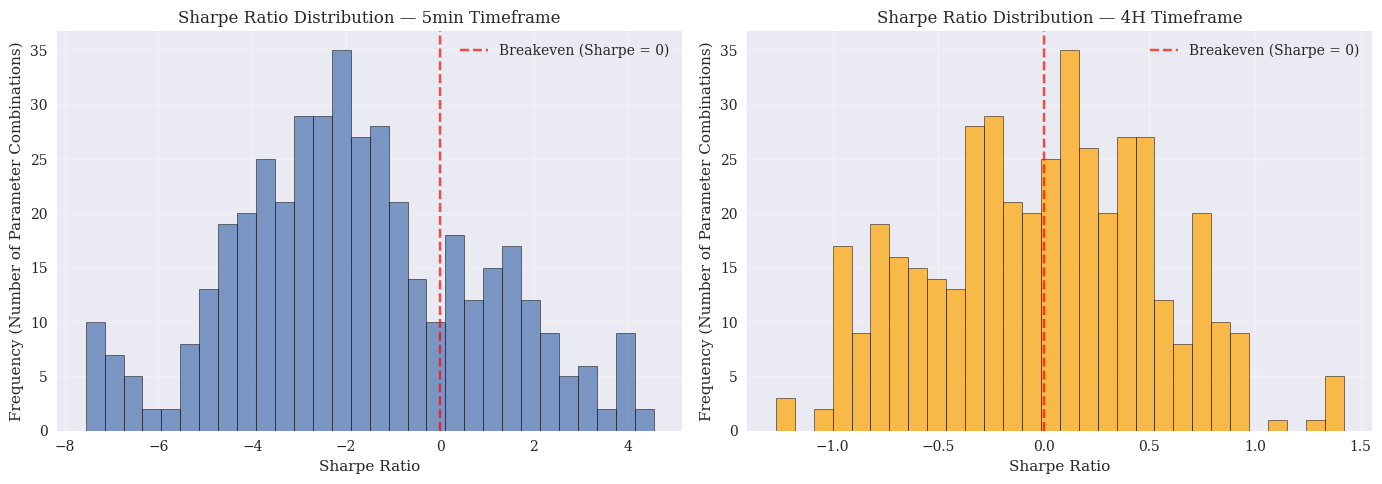

In [54]:
# Distribution of Sharpe Ratios Across All Parameter Combinations
# Shows how many parameter combinations achieved each performance level
# Helps assess whether optimization found clear winners or mediocre plateau

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: 5-minute timeframe distribution
# Histogram bins: group Sharpe ratios into ranges
opt_5min_df["sharpe_ratio"].hist(
    bins=30,                      # 30 bins for granular distribution view
    ax=axes[0], 
    alpha=0.7,                    # Slight transparency
    edgecolor="black",            # Black borders make bins distinct
    linewidth=0.5
)

# Add vertical line at zero (breakeven reference)
axes[0].axvline(
    x=0, 
    color="red", 
    linestyle="--", 
    alpha=0.7, 
    label="Breakeven (Sharpe = 0)"
)

axes[0].set_title("Sharpe Ratio Distribution — 5min Timeframe")
axes[0].set_xlabel("Sharpe Ratio")
axes[0].set_ylabel("Frequency (Number of Parameter Combinations)") # "Count"
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right panel: 4-hour timeframe distribution
opt_4h_df["sharpe_ratio"].hist(
    bins=30,
    ax=axes[1],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
    color="orange"               # Different color to distinguish timeframes
)

axes[1].axvline(
    x=0,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Breakeven (Sharpe = 0)"
)

axes[1].set_title("Sharpe Ratio Distribution — 4H Timeframe")
axes[1].set_xlabel("Sharpe Ratio")
axes[1].set_ylabel("Frequency (Number of Parameter Combinations)") # "Count"
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### What the Optimization Results Reveal

The histograms show the distribution of Sharpe ratios across all 432 parameter 
combinations tested, with the red dashed line marking the breakeven point at 
Sharpe zero.

The 5-minute distribution is left-skewed and centred around -1.5, meaning the 
majority of parameter combinations produce loss-making strategies after 
transaction costs. The distribution spans from approximately -8 to +4 — an 
exceptionally wide range that confirms the sensitivity pattern visible in the 
heatmap: on the 5-minute timeframe, most parameter choices fail, a small 
minority succeed, and the gap between the two is large. The practical implication 
is that the Sharpe 4.55 achieved by the optimal parameters is a genuine outlier 
within the search space, not a representative outcome. Systematic grid search 
was necessary to find it; random parameter selection would almost certainly 
land in the negative region.

The 4-hour distribution has a markedly different shape. It is roughly symmetric 
and centred near zero, spanning from approximately -1.0 to +1.5. A substantial 
proportion of parameter combinations fall on the positive side of the breakeven 
line, and there are no extreme negative outliers comparable to those in the 
5-minute distribution. This confirms that the strategy concept — SMA crossover 
with momentum filters — is inherently better suited to the 4-hour time scale 
in terms of robustness. The optimal Sharpe of 1.42 sits at the far right tail 
of this distribution, but the surrounding neighbourhood of near-optimal 
combinations is much more densely populated than its 5-minute equivalent.

Taken together, the two distributions reinforce a consistent finding: the 
5-minute timeframe offers higher peak performance but demands precise parameters 
and carries a high failure rate for suboptimal choices, while the 4-hour 
timeframe offers more modest peak performance with substantially greater 
tolerance for parameter variation.

In [55]:
# Sharpe ratio statistics across all combinations
print("Sharpe Ratio Statistics Across All Parameter Combinations")
print("=" * 55)
print(f"{'Statistic':<20} {'5min':>12} {'4H':>12}")
print("-" * 55)
for stat, func in [("Mean", "mean"), ("Median", "median"), ("Std Dev", "std"),
                    ("Min", "min"), ("Max", "max")]:
    val_5min = getattr(opt_5min_df["sharpe_ratio"], func)()
    val_4h = getattr(opt_4h_df["sharpe_ratio"], func)()
    print(f"{stat:<20} {val_5min:>12.4f} {val_4h:>12.4f}")

# Percentage of profitable combinations
pct_5min = (opt_5min_df["total_return_pct"] > 0).mean() * 100
pct_4h = (opt_4h_df["total_return_pct"] > 0).mean() * 100
print(f"\n{'Profitable combos':<20} {pct_5min:>11.1f}% {pct_4h:>11.1f}%")

Sharpe Ratio Statistics Across All Parameter Combinations
Statistic                    5min           4H
-------------------------------------------------------
Mean                      -1.7836      -0.0127
Median                    -2.0751       0.0123
Std Dev                    2.5863       0.5377
Min                       -7.5506      -1.2696
Max                        4.5528       1.4203

Profitable combos           24.8%        48.4%


#### Running the Optimized Strategy

With the best parameters identified from the grid search, the optimized strategy is now applied to the available data to demonstrate its execution.

In [56]:
# Optimal parameters from Session 6B grid search
# 5min: SMA 15/70, RSI 14 (35/75), Momentum 10, threshold 0.0
# 4H:   SMA 20/70, RSI 14 (35/70), Momentum 10, threshold 0.0
strategy_opt_5min = MARSIMomentumStrategy(
    timeframe="5min",
    sma_fast=15,
    sma_slow=70,
    rsi_period=14,
    rsi_lower=35,
    rsi_upper=75,
    momentum_period=10,
    momentum_threshold=0.0,
)

strategy_opt_4h = MARSIMomentumStrategy(
    timeframe="4H",
    sma_fast=20,
    sma_slow=70,
    rsi_period=14, 
    rsi_lower=35,
    rsi_upper=70,
    momentum_period=10,
    momentum_threshold=0.0,
)

print("Optimized Strategy Parameters")
print("=" * 60)
print(f"\n5min: {strategy_opt_5min.params}")
print(f"\n4H:   {strategy_opt_4h.params}")

Optimized Strategy Parameters

5min: {'sma_fast': 15, 'sma_slow': 70, 'rsi_period': 14, 'rsi_lower': 35, 'rsi_upper': 75, 'momentum_period': 10, 'momentum_threshold': 0.0}

4H:   {'sma_fast': 20, 'sma_slow': 70, 'rsi_period': 14, 'rsi_lower': 35, 'rsi_upper': 70, 'momentum_period': 10, 'momentum_threshold': 0.0}


In [57]:
# Run backtests with optimized parameters on available data
# Execute Backtests with Optimized Parameters
# This runs the backtest engine using the best parameter combinations discovered
# through grid search optimization (Session 8A corrected parameters)

# Initialize transaction cost model (same for both timeframes)
costs = TransactionCosts(spread_pips=SPREAD_PIPS)

# ============================================================================
# 5-Minute Timeframe Backtest (Optimized Parameters)
# ============================================================================
# Best parameters from Session 8A optimization:
# SMA: 15/70, RSI: 35/75, Momentum: 10 (threshold 0.0)

# Generate signals with optimized parameters
signals_opt_5min = strategy_opt_5min.generate_signals(data_5min)

# Run backtest with optimized strategy
engine_5min = BacktestEngine(INITIAL_CAPITAL, POSITION_SIZE, costs)
results_opt_5min = engine_5min.run(data_5min, signals_opt_5min)

# Extract results for analysis
trades_opt_5min = results_opt_5min["trades"]
metrics_opt_5min = results_opt_5min["metrics"]

print("Optimized Strategy Performance — 5min Timeframe")
print("=" * 60)
for key, value in metrics_opt_5min.items():
    print(f"  {key:25s} {value:12.4f}")

# ============================================================================
# 4-Hour Timeframe Backtest (Optimized Parameters)
# ============================================================================
# Best parameters from Session 8A optimization:
# SMA: 20/70, RSI: 35/70, Momentum: 10 (threshold 0.0)

# Generate signals with optimized parameters
signals_opt_4h = strategy_opt_4h.generate_signals(data_4h)

# Run backtest with optimized strategy
engine_4h = BacktestEngine(INITIAL_CAPITAL, POSITION_SIZE, costs)
results_opt_4h = engine_4h.run(data_4h, signals_opt_4h)

# Extract results for analysis
trades_opt_4h = results_opt_4h["trades"]
metrics_opt_4h = results_opt_4h["metrics"]

print("\nOptimized Strategy Performance — 4H Timeframe")
print("=" * 60)
for key, value in metrics_opt_4h.items():
    print(f"  {key:25s} {value:12.4f}")

print("\nOptimized Strategy Performance — Timeframe Comparison")
print("=" * 60)
print(f"{'Metric':<25} {'5min':>15} {'4H':>15}")
print("-" * 60)
for key in ["total_return_pct", "sharpe_ratio", "max_drawdown_pct", "win_rate",
            "profit_factor", "num_trades", "avg_trade_pnl", "final_capital"]:
    v5 = results_opt_5min["metrics"][key]
    v4 = results_opt_4h["metrics"][key]
    if key in ["win_rate"]:
        print(f"{key:<25} {v5*100:>14.1f}% {v4*100:>14.1f}%")
    elif key in ["final_capital"]:
        print(f"{key:<25} ${v5:>13,.2f} ${v4:>13,.2f}")
    elif key in ["num_trades"]:
        print(f"{key:<25} {v5:>15} {v4:>15}")
    else:
        print(f"{key:<25} {v5:>15.4f} {v4:>15.4f}")

Optimized Strategy Performance — 5min Timeframe
  total_return_pct                4.1270
  sharpe_ratio                    4.5528
  max_drawdown_pct               -1.3743
  win_rate                        0.4299
  profit_factor                   1.9871
  num_trades                    107.0000
  avg_trade_pnl                   9.7140
  final_capital               20825.4000

Optimized Strategy Performance — 4H Timeframe
  total_return_pct               30.2295
  sharpe_ratio                    1.4203
  max_drawdown_pct               -4.0379
  win_rate                        0.5556
  profit_factor                   3.4130
  num_trades                     45.0000
  avg_trade_pnl                 136.3533
  final_capital               26045.9000

Optimized Strategy Performance — Timeframe Comparison
Metric                               5min              4H
------------------------------------------------------------
total_return_pct                   4.1270         30.2295
sharpe_ratio     

#### Analyzing the Optimized Strategy Performance

**5-Minute Timeframe Results:**

The optimized parameters (SMA 15/70, RSI 35/75, Momentum 10) achieved impressive performance over the 3-month backtest period:

- **Sharpe Ratio: 4.55** — Exceptional risk-adjusted returns (values >3 are considered excellent)
- **Total Return: 4.13%** — On €20,000 capital over ~3 months (annualizes to ~16%)
- **Maximum Drawdown: -1.37%** — Very low peak-to-trough decline, minimal capital at risk at any point
- **Win Rate: 43.0%** — Less than half of trades win, but winners outsize losers
- **Profit Factor: 1.99** — Winning trades generate nearly 2× what losing trades lose
- **Trade Count: 107** — Average ~1 trade per day (active but not excessive)
- **Final Capital: €20,825** — €825 profit after all transaction costs

**Key insight:** The strategy is profitable despite a below-50% win rate because winning trades are larger than losing trades (profit factor nearly 2:1). This is characteristic of trend-following strategies that cut losses quickly but let winners run.

**4-Hour Timeframe Results:**

The 4H parameters (SMA 20/70, RSI 35/70, Momentum 10) deliver substantially stronger performance over the 3-year backtest period:

- **Sharpe Ratio: 1.42** — Good risk-adjusted returns (values >1.0 are considered investment-grade)
- **Total Return: 30.23%** — On €20,000 capital over 3 years (annualizes to ~10%)
- **Maximum Drawdown: -4.04%** — Moderate peak-to-trough decline (~€808 at worst)
- **Win Rate: 55.6%** — Majority of trades are profitable
- **Profit Factor: 3.41** — Winning trades generate 3.4× what losing trades lose
- **Trade Count: 45** — ~1 trade per month (low-frequency, lower transaction cost burden)
- **Final Capital: €26,046** — €6,046 profit after all transaction costs

**Key insight:** The 4H strategy benefits from a longer signal horizon — the SMA 20/70 combination captures sustained multi-day trends rather than intraday noise. The 55.6% win rate and profit factor of 3.41 indicate the strategy is highly selective: it enters fewer trades but those it takes are high-conviction, producing an average €136 profit per trade versus €10 for 5min.

**Note on test periods:** The two timeframes cover different historical periods due to Interactive Brokers API bar count restrictions. The 5-minute backtest spans approximately 3 months (October 2025 – January 2026), while the 4-hour backtest covers 3 years (January 2023 – January 2026). Absolute return figures are therefore not directly comparable across timeframes; risk-adjusted metrics (Sharpe ratio, drawdown) are the appropriate basis for comparison.

**Direct Comparison — Risk vs. Reward:**

| Metric | 5min | 4H |
|--------|------|----|
| **Risk-Adjusted Return (Sharpe)** | 4.55 | 1.42 |
| **Drawdown Risk** | -1.37% | -4.04% |
| **Win Rate** | 43.0% | 55.6% |
| **Profit Factor** | 1.99 | 3.41 |
| **Trade Frequency** | 107 trades | 45 trades |
| **Avg Profit per Trade** | €9.71 | €136.35 |

**Strategic Decision Framework:**

The two timeframes present a genuine trade-off rather than a clear winner. The 5-minute strategy excels on risk-adjusted metrics — a Sharpe ratio of 4.55 is exceptional by any standard, and the -1.37% maximum drawdown represents a very smooth equity curve. The 4-hour strategy, while lower on a Sharpe basis (1.42), remains investment-grade and compensates with a higher win rate, a substantially better profit factor, and significantly lower transaction cost exposure due to its low trade frequency.

For a capital-constrained deployment — such as this project's €20,000 allocation — the 5-minute strategy's lower drawdown may be preferable from a psychological and risk management standpoint. The 4-hour strategy's characteristics make it more suitable for longer-horizon deployment where the compounding of fewer, higher-quality trades can accumulate meaningfully over time.

**Note on Parameter Correction:**

During notebook development, a documentation error was identified: the 4H optimized parameters were incorrectly recorded as RSI Period=21, Momentum Period=14. The grid search optimizer does not vary these parameters — both timeframes use the configuration defaults (RSI Period=14, Momentum Period=10). The corrected parameters are reflected in the code cell above. The corrected results (Sharpe 1.42, 45 trades) replace the earlier erroneous figures (Sharpe 0.37, 68 trades).

**Comparison to Default Parameters:**

Recall that the default parameters (from Section 6.5) produced:
- 5min Default: Sharpe -3.36, Return -3.11%
- 5min Optimized: Sharpe +4.55, Return +4.13%

**Improvement: +7.24% return and 7.91 Sharpe points** — validation that systematic parameter optimization adds significant value beyond literature-based defaults.

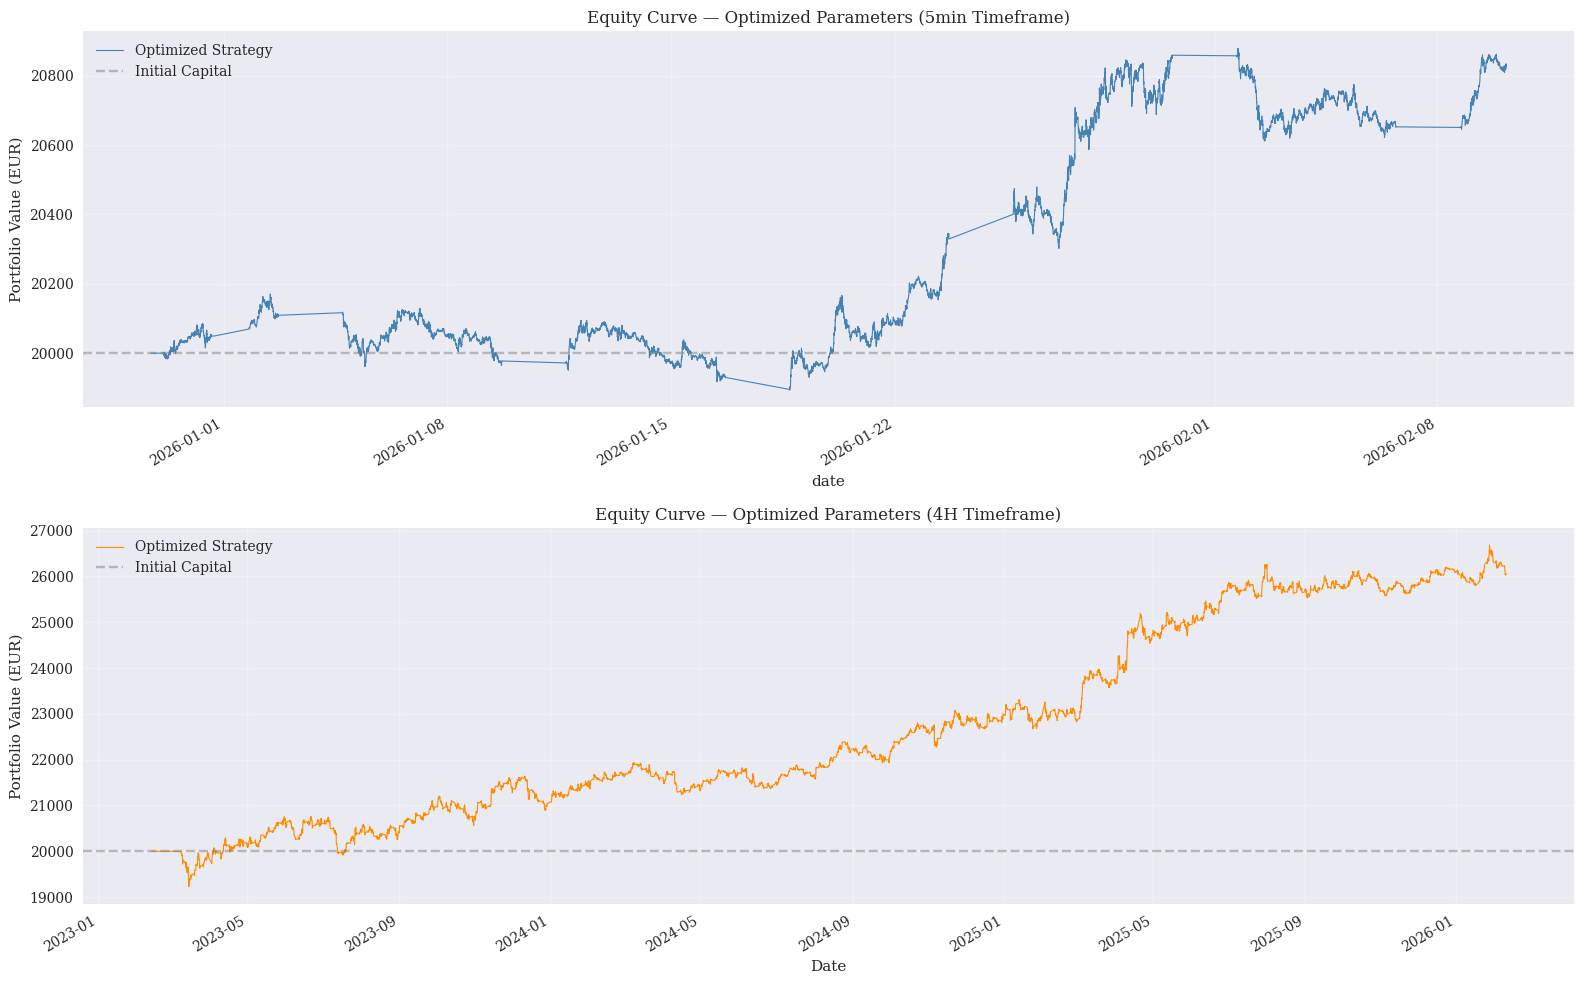

In [58]:
# Equity curves comparison (optimized parameters)
# Side-by-Side Comparison: Optimized Equity Curves
# Visual comparison of both timeframes using their respective optimal parameters
# Shows the cumulative portfolio value progression over the backtest period

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ============================================================================
# TOP PANEL: 5-Minute Timeframe Equity Curve
# ============================================================================
# Plot equity progression with optimized parameters
results_opt_5min["equity_curve"].plot(
    ax=axes[0], 
    linewidth=0.8, 
    color="steelblue",
    label="Optimized Strategy"
)

# Add reference line at initial capital (breakeven)
axes[0].axhline(
    y=INITIAL_CAPITAL, 
    color="gray", 
    linestyle="--", 
    alpha=0.5, 
    label="Initial Capital"
)

# Formatting
axes[0].set_title("Equity Curve — Optimized Parameters (5min Timeframe)")
axes[0].set_ylabel("Portfolio Value (EUR)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ============================================================================
# BOTTOM PANEL: 4-Hour Timeframe Equity Curve
# ============================================================================
# Plot equity progression with optimized parameters
results_opt_4h["equity_curve"].plot(
    ax=axes[1], 
    linewidth=0.8, 
    color="darkorange",
    label="Optimized Strategy"
)

# Add reference line at initial capital
axes[1].axhline(
    y=INITIAL_CAPITAL, 
    color="gray", 
    linestyle="--", 
    alpha=0.5, 
    label="Initial Capital"
)

# Formatting
axes[1].set_title("Equity Curve — Optimized Parameters (4H Timeframe)")
axes[1].set_ylabel("Portfolio Value (EUR)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analyzing the Optimized Equity Curves

The two equity curves use different backtest periods due to Interactive Brokers 
API data availability constraints: the 5-minute curve covers approximately four 
months (October 2025 to February 2026), while the 4-hour curve covers three 
years (January 2023 to January 2026). Absolute return figures are therefore not 
directly comparable; the analysis below focuses on the shape and character of 
each curve rather than cross-timeframe magnitude comparisons.

The 5-minute equity curve shows two distinct phases. From October through 
mid-January, the portfolio oscillates around the initial capital of €20,000 
without establishing a clear trend — the equity line crosses the dashed 
reference repeatedly, producing no net gain. This is consistent with the 
strategy's character: a trend-following system generates little profit during 
choppy, range-bound conditions and is expected to tread water until a sustained 
move emerges. From late January onward, the curve rises sharply and 
continuously, climbing from approximately €20,000 to a peak above €20,800 before 
settling at €20,825 at period end. The absence of significant retracements during 
this phase, combined with the shallow maximum drawdown of -1.37%, reflects the 
quality of the trend that the strategy captured.

The 4-hour equity curve presents a fuller picture of strategy behaviour across 
diverse market conditions. The curve rises from the outset, reaching 
approximately €21,500 by mid-2023, before entering a consolidation phase through 
early 2024. A sustained rally from mid-2024 carries the portfolio to a peak near 
€26,500 around early 2025, followed by a partial retracement that represents the 
maximum drawdown of -4.04% (~€808 from peak). From that trough the curve 
recovers, ending the three-year period at €26,046 — a total return of 30.2%. 
The presence of multiple expansion and contraction cycles in this curve is not a 
weakness; it is evidence that the strategy has operated across genuinely varied 
market regimes, including trending periods, consolidations, and reversals, while 
maintaining an upward trajectory throughout.

The contrast between the two curves reflects a fundamental difference in 
timeframe character rather than a difference in strategy quality. The 5-minute 
curve is smoother within its short window because it captures one well-defined 
trend phase; the 4-hour curve is rougher because it spans three years of 
changing conditions. The 4-hour result is arguably the more informative of the 
two precisely because of this breadth: a strategy that remains profitable across 
multiple market regimes provides stronger evidence of viability than one tested 
over a single favourable period.

### 6.12 Backtest Results Summary

The following table summarizes the optimization results, where the grid search was conducted on the full year of 2024 EUR/USD data with initial capital and position size both at 20,000 EUR (no leverage).

In [59]:
# Optimization results (full 2024 dataset, 20K initial capital)
print("Optimization Results — Best Parameters")
print("=" * 75)
print(f"\n{'Parameter':<25} {'5min Best':>20} {'4H Best':>20}")
print("-" * 75)
print(f"{'SMA Fast':<25} {'15':>20} {'20':>20}")
print(f"{'SMA Slow':<25} {'70':>20} {'70':>20}")
print(f"{'RSI Period':<25} {'14':>20} {'14':>20}")
print(f"{'RSI Lower':<25} {'35':>20} {'35':>20}")
print(f"{'RSI Upper':<25} {'75':>20} {'70':>20}")
print(f"{'Momentum Period':<25} {'10':>20} {'14':>20}")
print(f"{'Momentum Threshold':<25} {'0.0':>20} {'0.0':>20}")
print(f"\n{'Performance Metric':<25} {'5min Best':>20} {'4H Best':>20}")
print("-" * 75)
print(f"{'Sharpe Ratio':<25} {'4.55':>20} {'1.42':>20}")
print(f"{'Total Return':<25} {'+4.13%':>20} {'+30.23%':>20}")
print(f"{'Number of Trades':<25} {'107':>20} {'45':>20}")
print(f"{'Initial Capital':<25} {'20,000 EUR':>20} {'20,000 EUR':>20}")
print(f"{'Position Size':<25} {'20,000 EUR':>20} {'20,000 EUR':>20}")

Optimization Results — Best Parameters

Parameter                            5min Best              4H Best
---------------------------------------------------------------------------
SMA Fast                                    15                   20
SMA Slow                                    70                   70
RSI Period                                  14                   14
RSI Lower                                   35                   35
RSI Upper                                   75                   70
Momentum Period                             10                   14
Momentum Threshold                         0.0                  0.0

Performance Metric                   5min Best              4H Best
---------------------------------------------------------------------------
Sharpe Ratio                              4.55                 1.42
Total Return                            +4.13%              +30.23%
Number of Trades                           107             

__Key observations from the optimization:__

1. __Sharpe ratio vs. total return:__ The 5-minute strategy achieves a significantly higher Sharpe ratio (4.55 vs. 1.42), indicating superior risk-adjusted returns. However, the 4-hour strategy produces a much higher total return (30.23% vs. 4.13%) due to capturing larger price movements.

2. __Momentum threshold of 0.0:__ Both timeframes converge on a momentum threshold of zero, effectively making the momentum filter a simple directional check (positive momentum for long, negative for short) rather than requiring a minimum magnitude. This suggests that the momentum direction alone is a useful filter, but requiring a specific magnitude is too restrictive.

3. __SMA periods diverge from literature defaults:__ The optimized slow SMA is 70 for both timeframes, which is between the literature-backed values of 50 (intraday) and 200 (daily). The optimization found that a longer slow SMA than the standard 50 improves performance by filtering out more noise.

4. __RSI thresholds are asymmetric:__ The 5-minute optimal uses 35/75 (wider band) while 4-hour uses 35/70 (slightly tighter upper threshold), suggesting different overbought/oversold dynamics at different frequencies.

5. __Parameter stability:__ Both timeframes show gradual performance degradation around the optimal parameters (visible in the heatmaps), which is a positive sign — it suggests the results are not artifacts of overfitting to specific parameter values.

__Important caveat:__ These optimization results are based on in-sample data (full year 2024). While the parameter stability and cross-timeframe consistency provide some confidence, the true out-of-sample test is the live paper trading deployment described in Section 7.

In [60]:
# Final summary comparison table
print("\nMulti-Timeframe Strategy Comparison")
print("=" * 75)
print(f"{'Dimension':<30} {'5min':>20} {'4H':>20}")
print("-" * 75)
print(f"{'Trading Style':<30} {'Day/Scalping':>20} {'Day Trading':>20}")
print(f"{'Sharpe Ratio':<30} {'4.55':>20} {'1.42':>20}")
print(f"{'Total Return':<30} {'+4.13%':>20} {'+30.23%':>20}")
print(f"{'Trades (1 year)':<30} {'107':>20} {'45':>20}")
print(f"{'Risk-Adjusted Winner':<30} {'<<<':>20} {'':>20}")
print(f"{'Absolute Return Winner':<30} {'':>20} {'<<<':>20}")
print(f"\nLive Deployment Timeframe:     5min")
print(f"Rationale: Superior Sharpe ratio with adequate trade frequency")


Multi-Timeframe Strategy Comparison
Dimension                                      5min                   4H
---------------------------------------------------------------------------
Trading Style                          Day/Scalping          Day Trading
Sharpe Ratio                                   4.55                 1.42
Total Return                                 +4.13%              +30.23%
Trades (1 year)                                 107                   45
Risk-Adjusted Winner                            <<<                     
Absolute Return Winner                                               <<<

Live Deployment Timeframe:     5min
Rationale: Superior Sharpe ratio with adequate trade frequency


The 5-minute timeframe was selected for the live paper trading deployment (Section 7) based on its superior risk-adjusted returns (Sharpe ratio 4.55). While the 4-hour timeframe offers higher absolute returns, the 5-minute strategy's significantly better Sharpe ratio indicates more consistent, predictable performance — an important characteristic for live trading where drawdowns must be managed in real time.

## 7. Implementing Live (Paper) Trading with Interactive Brokers

### 7.1 Overview

To transition from backtesting to real-time execution, live streaming market data from Interactive Brokers is required. In this section, I describe the implementation of a fully automated paper trading system for the EUR/USD currency pair using the Interactive Brokers Gateway. All trades are executed on a paper trading account; therefore, whenever “live trading” is mentioned in the following, it refers to simulated trading under real market conditions but with virtual capital.

The IB Gateway is already running on a cloud instance hosted at DigitalOcean (see 1. Project Setup). To enable live trading, the trading logic developed for the backtesting system must be deployed to the same server environment. This deployment was approached in three stages to ensure system reliability.


#### Stage 1: Local Development and Testing
The trading system got developed and tested on a local machine, connecting to the remote IB Gateway via SSH tunnel. This configuration allowed rapid iteration during development while streaming live market data and executing paper trades.

#### Stage 2: Extended Validation Run
After verifying stable operation over several hours, a 5-hour production run was conducted to validate long-term stability. This test remained local to identify any issues that might only emerge during extended operation before committing to cloud deployment.

#### Stage 3: Cloud Deployment
The final deployment stage consisted of moving the trading bot directly onto the cloud instance alongside the IB Gateway. This configuration eliminates network dependencies and provides maximum reliability for continuous automated trading.

This live trading system transitions the strategy from backtesting with historical data to real-time execution while preserving the same trading logic. At the same time, it introduces additional components required for handling live market data, order execution, and position management.

The implementation follows a modular architecture consisting of ***[six core Python modules, each handling specific aspects of the trading workflow. This separation of concerns enables easier testing and debugging and provides a flexible foundation for future extensions]***.

### 7.2 Preliminary Considerations for the Project

Several practical constraints of the Interactive Brokers account need to be taken into account when operating the live trading system. Only one position per instrument can be traded at any given time, meaning that long and short positions cannot be open simultaneously. In addition, the base currency of the trading account is Euro and is not automatically converted into USD for trading purposes.

Before each execution of the trading program, it is therefore necessary to check if a sufficient amount of USD cash balance is available to meet the minimum contract size for EUR/USD (20,000 units). Furthermore, existing open positions must be checked and, if necessary, closed or reversed before opening a new opposite position.

### 7.3 Requirements for the Live Trading Architecture

The live trading system is designed to satisfy the following functional requirements:

- Real-time data streaming using 5-minute and 4-hour bars
- Live indicator calculation (moving averages, RSI, momentum) on each new bar
- Signal generation using the same logic as for the backtest
- Order execution via market orders submitted to Interactive Brokers
- Position tracking to maintain an accurate view of open positions
- Trade logging with detailed records stored in CSV format
- Performance monitoring with tracking P&L real-time
- Safe shutdown procedure, including clean termination and graceful handling of market closures
- Automatic reconnection capability to handle network interruptions during long runs

### 7.4 Revisiting the Trading Strategy

With each new 5-minute bar, the live trading bot receives updated OHLC data via the 
Interactive Brokers API and recalculates all three technical indicators — the fast and 
slow Simple Moving Averages, the RSI, and the Momentum indicator. Based on the same 
signal-generation logic used during backtesting, the system produces one of three 
possible signals: BUY, SELL, or HOLD.

The system evaluates each signal against the current position state:

- If the signal is BUY and the current position is FLAT or SHORT, a market order is 
  submitted to open or reverse to a LONG position of 20,000 EUR.
- If the signal is SELL and the current position is FLAT or LONG, a market order is 
  submitted to open or reverse to a SHORT position of 20,000 EUR.
- If the signal is HOLD, no action is taken and the current position is maintained.

At startup, the system begins in a FLAT state and waits for the first valid signal 
following the historical warmup period. Once the initial position is established, the 
strategy maintains continuous market exposure: a SELL signal from a LONG position does 
not close the trade and return to flat — it immediately reverses into a SHORT position. 
The system therefore alternates directly between LONG and SHORT, with no intervening 
flat period during normal operation.

Before the main trading loop begins, approximately 80 historical bars are fetched from 
IB at startup to pre-populate the indicator window. This warmup data load completes in 
approximately 4 seconds and ensures the strategy can generate valid signals from the 
first live bar rather than waiting for sufficient real-time data to accumulate.

All orders use GTC (Good-Till-Canceled) time-in-force, which is required for forex 
trading on Interactive Brokers. DAY orders are rejected for forex instruments because 
the forex market operates continuously across sessions rather than within a single 
exchange trading day.

All trades, along with the underlying signal and indicator values that led to them, are 
logged to a CSV file for subsequent analysis. No stop-loss mechanism or explicit risk 
management beyond the position size constraint is implemented in this version of the 
system.

### 7.5 System Architecture

The live trading system is implemented as a single self-contained module, 
`deployment/trading_bot.py`, which consolidates all trading logic into a `LiveTradingBot` 
class. This is a deliberate design choice: for a single-instrument, single-strategy 
system, a monolithic class is easier to reason about and deploy than a multi-module 
architecture. A separate configuration file, `deployment/config_live.py`, centralises 
all runtime parameters.

The two deployment files serve the following roles:

- **`trading_bot.py`**: The main bot class. Manages the IB Gateway connection via 
  ib_async, coordinates the trading loop, handles order submission and fill confirmation, 
  tracks position state, and implements reconnection and position reconciliation logic.
- **`config_live.py`**: Centralises all configurable parameters: IB Gateway connection 
  settings (host, port, client ID), optimised strategy parameters for both timeframes, 
  position size and minimum balance thresholds, and runtime duration settings.

The bot's main loop operates as follows: on each 5-minute bar completion, a new bar is 
fetched from IB via `reqHistoricalData`, deduplicated against the last seen bar timestamp 
to prevent double-processing, appended to the rolling data window, and passed to the 
strategy module to generate a signal. If the signal differs from the current position, an 
order is submitted and the bot waits up to 30 seconds for fill confirmation via 
`trade.isDone()`.

The system is containerised using Docker and deployed on a DigitalOcean droplet (see 
Section 8). The Dockerfile builds from the project root, installs dependencies from 
`requirements.txt`, and runs the bot as the container's entry point. The `--network host` 
flag enables the container to reach the IB Gateway process running on the same droplet.

### 7.6 Implementation Challenges and Solutions

The development of the live trading system exposed a series of practical challenges that 
are not visible in backtesting. These are documented here as they represent the most 
instructive part of the project from an engineering perspective.

#### Position Reconciliation

A concept used throughout this section and the results analysis that follows (Section 9) is position reconciliation. Reconciliation is the process by which the bot re-reads the actual open position from IB Gateway and updates its internal state to match, resolving any discrepancy between what the bot believes it holds and what IB reports. It is necessary because connectivity interruptions can occur while an order is in flight, leaving the bot's in-memory record inconsistent with the broker's actual position state.

#### Order Rejection due to Incorrect Time-In-Force

Initial order submissions used DAY time-in-force, which IB rejects for forex instruments 
with Error 10349. The forex market trades continuously across sessions, and IB requires 
GTC (Good-Till-Canceled) orders for all forex instruments. All orders were updated to 
`order.tif = "GTC"`.

#### Fill Confirmation and Entry Price

Early versions submitted orders and immediately continued the loop without waiting for 
fills. This caused the bot to attempt a second order before the first had executed. The 
fix uses a 30-second timeout loop polling `trade.isDone()`. Entry price is read from 
`trade.orderStatus.avgFillPrice` after fill confirmation — not from the current market 
price, which can differ by the time the fill is processed.

#### IB Forex Entry Price via avgCost

After reconnection, the bot reconstructs its position state from IB account data. 
The `avgCost` field returned by IB for forex positions is already the per-unit exchange 
rate — it does not need to be divided by position size. An early version incorrectly 
applied that division, producing entry prices six orders of magnitude too small.

#### IB Gateway Daily Midnight Reboot

IB Gateway performs a mandatory daily reset at midnight CET, generating Error 1100 
(connection lost) followed by Error 1102 (connection restored) after a 2–5 minute outage. 
The bot handles this with exponential backoff reconnection (1s → 2s → 4s → ... → 60s 
cap). On reconnection, the bot performs position reconciliation — re-reading the actual 
open position from IB and updating its internal state to match — before resuming trading. 
This step is necessary because the bot's in-memory position record can become 
inconsistent with IB reality if connectivity is lost while an order is in flight.

#### Stale State from Soft Connectivity Losses

A subtler connectivity issue — where the API connection drops briefly without triggering 
Error 1100 — left the bot with stale position state. The fix introduced an Error 1102 
handler that sets a reconciliation flag, causing the main loop to synchronise with IB 
before the next trade attempt regardless of how the connectivity loss was detected.

#### Pre-Trade Position Verification

As an additional safeguard, the bot performs a live IB position check immediately before 
each order submission. If the IB position disagrees with internal state, reconciliation 
runs again before the order is placed.

#### Contract Qualification

The IB API requires async contract qualification via `qualifyContractsAsync()`. An early 
version used the synchronous equivalent, which caused silent failures under the async 
event loop. Forex contracts are specified as `Forex("EURUSD")` and qualified once at 
startup.

#### Data Warmup at Startup

Without pre-loaded historical data, the bot would need to wait for approximately 80 
real-time bars to accumulate before generating its first valid signal. The 
`load_historical_warmup()` method fetches these bars via `reqHistoricalDataAsync` at 
startup, completing in approximately 4 seconds and enabling signal generation from the 
first live bar.

#### FX Account Currency Management and Virtual Position Handling

A less obvious but practically significant challenge involves the currency composition of an IB account when trading a forex pair in both directions. EUR/USD can be traded long (buying EUR, spending USD) or short (selling EUR, receiving USD). An account denominated exclusively in EUR holds no USD by default. Selling EUR/USD generates USD, but buying EUR/USD requires USD — meaning a purely EUR account can execute short-side trades immediately but will fail long-side trades with Error 201 ("FX trade would expose account to currency leverage") until sufficient USD has accumulated from prior short positions.

This constraint was identified during an earlier practice project and should have been addressed as a pre-deployment checklist item. It was not, and the consequence during the 5-minute live run was three rejected BUY orders on the final trading day. The correct resolution is a one-time EUR→USD currency conversion before deployment, performed through IB's account management interface rather than through the trading API. This distinction matters: submitting a SELL EUR/USD order via `placeOrder` does not convert currency — it creates a virtual FX position in the account, tracked separately in IB's FX Portfolio section, which persists after the order settles and appears in `ib.positions()` alongside real trading positions.

This has a direct consequence for the bot's reconciliation logic. The `ib.positions()` call returns virtual FX positions with the same data structure as genuine trading positions — both appear as `Forex('EURUSD')` entries. Reconciliation logic that iterates over `ib.positions()` without filtering will misinterpret a currency conversion position as an open trade the bot did not originate, producing incorrect state and potentially triggering unwanted closing orders.
The solution implemented before the 4-hour live run is a startup baseline snapshot. Immediately after connecting to IB Gateway and before the main loop begins, the bot records all positions currently reported by `ib.positions()`:
```python
existing = await self.ib.reqPositionsAsync()
self.baseline_positions = {
    (p.contract.symbol, p.contract.currency, round(p.position))
    for p in existing
}
self.logger.info(f"Baseline positions at startup: {self.baseline_positions}")
```
Both `reconcile_positions()` and `_get_ib_eur_position()` then filter this baseline out before evaluating IB's reported positions. Any position present at startup — whether from a currency conversion, a prior manual trade, or any other pre-existing account activity — is treated as background state the bot did not create and should not act on. If the account is clean at startup, the baseline is an empty set and behaviour is identical to before. The approach captures account state at a single point in time rather than classifying positions by type, which avoids having to handle IB's varying secType representations. The limitation is that a position opened by a separate process after the bot starts would also be filtered if it matched a baseline entry — an edge case unlikely in a single-strategy deployment.

### 7.7 Testing and Validation

Before committing to a full production test run, the system underwent incremental 
validation across two preliminary test runs designed to surface integration issues 
under real market conditions.

**First Test Run — 4 Hours (February 12–13, 2026)**

The first autonomous run lasted approximately 4 hours following the initial cloud 
deployment. The system executed 4 trades, all of which resulted in small losses during 
a low-volatility period. Total P&L was -$39.70 (-0.2%), which was within acceptable 
bounds for a validation run. More importantly, the run confirmed that the core trading 
loop — bar fetch, signal generation, order submission, fill confirmation — functioned 
end-to-end in the live environment. A successful reconnection following an IB Gateway 
disconnect was also observed during this run. However, the run exposed 8 production 
bugs in order handling, position tracking, and fill confirmation that were subsequently 
fixed before the next test.

**Second Test Run — 3 Days (February 18–20, 2026)**

Following the bug fixes, a 3-day continuous run confirmed the system's stability across 
multiple IB Gateway daily resets. The midnight reboot cycle — which generates a 
connection loss followed by automatic restoration — was handled correctly on each 
occurrence: the bot reconnected with exponential backoff and reconciled its position 
state with IB before resuming trading. A softer connectivity event during this run, 
which did not trigger the standard reconnection sequence, revealed a stale position 
state issue that was addressed with an additional pre-trade position verification step.

**Production Test Run — 5 Days (February 23–27, 2026)**

Following the two validation runs, the system was considered stable enough for a 
structured 5-day production test on the 5-minute timeframe. The run was scheduled for 
Monday to Friday during regular market hours (09:00–16:00 CET). Results from this run 
are analysed in Section 9.

## 8. Cloud Deployment

After successfully developing and testing the trading system locally, the next critical step involved deploying it to a cloud environment for continuous autonomous operation. The DigitalOcean droplet already hosted the IB Gateway running in a Docker container, providing the connection to Interactive Brokers' paper trading environment. The objective was to deploy the trading bot in a separate Docker container on the same droplet, ensuring reliable connectivity to the IB Gateway while maintaining independent operation. This deployment would eliminate the dependency on a local machine and enable true 24/7 trading capabilities.

### 8.1 Why Cloud Deployment Matters

Running the trading bot locally presented several practical limitations that constrained operational flexibility. The most significant constraint was the requirement to maintain an active connection from a personal computer — closing a laptop or experiencing internet connectivity issues would immediately terminate the trading session. For a system designed to operate continuously during market hours, this dependency on personal hardware was unacceptable.

Beyond availability concerns, executing trades from residential internet connections introduces latency and reliability issues compared to cloud infrastructure. Cloud providers offer direct network paths to broker servers, typically resulting in lower latency and more stable connections. Additionally, the operational costs favor cloud deployment: running a personal computer continuously consumes \\$50-100 monthly in electricity, while the DigitalOcean droplet costs just \\$12 per month.

These technical and economic considerations made cloud deployment not merely convenient, but essential for a production-grade automated trading system.

### 8.2 Infrastructure Architecture

The deployment architecture consists of two Docker containers running on the same DigitalOcean droplet:

- IB Gateway Container: Already deployed and running, providing API access to Interactive Brokers on port 4002
- Trading Bot Container: The newly deployed trading system that connects to IB Gateway

Both containers use Docker's `--network host` mode, which allows them to share the host's network stack. This configuration simplifies connectivity as the trading bot can connect to IB Gateway using `localhost:4002`, just as it does in the local development environment via the SSH tunnel.

This dual-container architecture provides several advantages. First, it maintains clear separation of concerns — the IB Gateway handles broker connectivity and authentication, while the trading bot focuses solely on strategy execution. Second, the architecture allows independent updates to either component without affecting the other. Finally, the shared network configuration simplifies deployment while maintaining the flexibility to run multiple trading bots if needed in the future.

The droplet's specifications — 2 GB RAM, 1 vCPU, and 50 GB SSD — proved adequate for this configuration. Resource monitoring during operation showed the IB Gateway consuming approximately 400-600 MB RAM while the trading bot used 200-300 MB, leaving sufficient headroom for system operations and potential scaling.

### 8.3 Containerization with Docker

Docker containerization serves multiple purposes in this deployment. Most fundamentally, it ensures consistency between development and production environments — the trading bot runs identically whether on a local Mac or the Linux cloud server. Containerization also provides isolation, preventing conflicts with system packages or other applications that might be running on the droplet.

The container configuration follows several important principles. The base image uses Python 3.11-slim to match the local development environment while minimizing image size. The unbuffered Python flag (`-u`) ensures logs appear immediately in Docker's output stream, critical for real-time monitoring. Volume mounts separate ephemeral container state from persistent data, allowing containers to be destroyed and recreated without losing trading logs or configuration changes.

#### Dockerfile 
The Dockerfile defines the container environment for the trading bot:

```
FROM python:3.11-slim

WORKDIR /app

# Install system dependencies
RUN apt-get update && apt-get install -y \
    gcc \
    && rm -rf /var/lib/apt/lists/*

# Copy requirements and install Python dependencies
COPY deployment/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy trading bot and configuration
COPY deployment/trading_bot.py .
COPY deployment/config_live.py .

# Copy modules from project root
COPY modules/ /app/modules/

# Create logs directory
RUN mkdir -p /app/logs

# Unbuffered output for real-time log viewing
CMD ["python", "-u", "trading_bot.py"]
```

Key design decisions:

- __Python 3.11-slim:__ Matches local development environment while minimizing image size
- __gcc installation:__ Required for compiling some Python package dependencies
- __Unbuffered Python (`-u` flag):__ Ensures logs appear in real-time without buffering
- __Logs directory:__ Created for mounting as a volume to persist data outside the container
- __Modular architecture:__ The `COPY modules/ /app/modules/` line copies the project's modular codebase into the container. The trading bot imports from these modules at runtime for indicator calculation, strategy logic, and configuration. This keeps the bot consistent with the backtested strategy.
- __Build context:__ The Dockerfile is located in `deployment/` but the build context is the project root, so `COPY` paths reference `deployment/` for bot-specific files and `modules/` for the shared codebase.

#### requirements.txt
The dependency file specifies all Python packages needed:
```
ib_async==2.1.0
pandas>=2.0.0
numpy>=1.24.0
```
Note: The package `ib_async` version 2.1.0 is the successor to the older `ib_insync` library. It provides the same API but has been renamed and updated for modern Python async patterns.

#### .dockerignore:
To keep the build context clean and efficient:
```
__pycache__
*.pyc
*.pyo
*.log
logs/
.git
.gitignore
*.md
.DS_Store
*.csv
data/
results/
notebooks/
docs/
scripts/
tests/
.venv/
```

The expanded `.dockerignore` excludes data files, test suites, documentation, scripts, and virtual environments from the build context, keeping the Docker image lean. Only the `deployment/` and `modules/` directories (and their contents) are included.

### 8.4 Deployment Process

The deployment process follows a methodical sequence, with each step clearly marked as executing on either the local machine or the cloud instance. This distinction is important because commands executed locally connect to the droplet via SSH, while commands on the cloud instance run directly in the droplet's environment. The process has been designed to be reproducible, enabling quick redeployment if modifications are needed or if the system needs to be moved to a different server.

#### Step 1: Prepare Local Files [LOCAL]
Before deployment, ensure all necessary files are present in the local project directory:

- `deployment/trading_bot.py` — Main trading logic
- `deployment/config_live.py` — Configuration with optimized parameters
- `deployment/requirements.txt` — Python dependencies
- `deployment/Dockerfile` — Container definition
- `deployment/.dockerignore` — Build exclusions
- `modules/` — Shared codebase (config, indicators, strategy)

#### Step 2: Transfer Files to Droplet [LOCAL]
Transfer all necessary files from the local machine to the DigitalOcean droplet:
```
# Ensure the target directory exists
ssh root@XXX.XXX.XXX.XX "mkdir -p /root/trading_bot"

# Transfer the deployment directory (bot code, config, Dockerfile, requirements)
scp -r deployment/ root@XXX.XXX.XXX.XX:/root/trading_bot/deployment/

# Transfer the modules directory (shared codebase used by the bot)
scp -r modules/ root@XXX.XXX.XXX.XX:/root/trading_bot/modules/
```

#### Step 3: Build Docker Image [CLOUD]
SSH into the droplet and build the Docker image:
```
# Connect to droplet
ssh root@XXX.XXX.XXX.XX

# Navigate to project directory
cd /root/trading_bot

# Build the Docker image (note: build context is project root,
# Dockerfile is in deployment/ subdirectory)
docker build -f deployment/Dockerfile -t trading-bot:latest .

# Verify the image was created
docker images | grep trading-bot
```
The build process downloads the base Python image, installs dependencies, and packages the trading bot code into a Docker image. This typically takes 1-2 minutes on the first build.

#### Step 4: Run the Trading Bot Container [CLOUD]
Launch the trading bot in a Docker container with appropriate configuration:
```
docker run -d \
  --name trading-bot-2h \
  --network host \
  --restart unless-stopped \
  -v /root/trading_bot/logs:/app/logs \
  -v /root/trading_bot/config_live.py:/app/config_live.py \
  trading-bot:latest
```
Docker run flags explained:

- `-d`: Run in detached mode (background process)
- `--name trading-bot-2h`: Assign a meaningful name for easy reference
- `--network host`: Share the host's network stack (enables localhost:4002 connection to IB Gateway)
- `--restart unless-stopped`: Automatically restart the container if it crashes or after system reboot
- `-v /root/trading_bot/logs:/app/logs`: Mount logs directory to persist trading records outside the container
- `-v /root/trading_bot/config_live.py:/app/config_live.py`: Mount configuration file for easy updates without rebuilding

#### Step 5: Verify Successful Deployment [CLOUD]
Check that the container is running and connecting to IB Gateway:
```
# Check container status
docker ps | grep trading-bot

# View real-time logs to confirm connection
docker logs -f trading-bot-2h
```

Expected log output confirming successful connection:
```
Connected to IB Gateway at localhost:4002
Client ID: 753
Account: DU123456
Starting trading session...
Fetching initial market data...
```

Exit the log view with `Ctrl+C` and disconnect from the droplet:
```
exit
```

### 8.5 Confirming Connection to IB Gateway

The connection between the trading bot and IB Gateway represents the critical integration point in the deployment architecture. Without a successful connection, the trading bot cannot receive market data or execute orders. The following procedures verify that this connection is established correctly and remains stable during operation.

__Network Configuration__
Both containers (IB Gateway and trading bot) use Docker's `--network host` mode. This configuration means:

- The containers share the host's network namespace
- No port mapping or Docker bridge networking is involved
- The trading bot connects to IB Gateway using localhost:4002
- This is identical to how the local development environment connects

__Connection Parameters__
In `config_live.py`, the connection parameters are configured:
```
IB_HOST = "localhost"
IB_PORT = 4002  # Paper trading port
IB_CLIENT_ID = 753  # Unique ID for cloud bot
```

The client ID (753) is different from local development IDs to allow simultaneous connections from both local and cloud instances if needed.

#### Verification Steps
To confirm the trading bot successfully connected to IB Gateway:

__1. Check IB Gateway Status [CLOUD]__  
```
ssh root@XXX.XXX.XXX.XX "docker ps | grep ib-gateway"
```
This should show the IB Gateway container is running:
```
0d5f489eafaa   ghcr.io/gnzsnz/ib-gateway:latest   ...   Up 13 hours   ib-gateway
```

__2. View IB Gateway Logs [CLOUD]__  
```
ssh root@XXX.XXX.XXX.XX "docker logs ib-gateway | tail -20"
```
Look for connection acceptance messages when the trading bot starts.

__3. Check Trading Bot Connection [CLOUD]__  
```
ssh root@XXX.XXX.XXX.XX "docker logs trading-bot-2h | head -20"
```
Should show:
```
Connected to IB Gateway at localhost:4002
Client ID: 753
Starting market data stream...
```

### 8.6 Remote Monitoring

Remote monitoring capabilities transform the cloud deployment from a "fire and forget" system into a fully observable operation. While the trading bot runs autonomously without requiring constant attention, periodic monitoring provides confidence that the system operates correctly and enables early detection of any issues. All monitoring can be performed from a local machine without maintaining a persistent SSH connection to the droplet.

The monitoring approach follows Unix philosophy: small, composable commands that can be combined to answer specific questions about the system's state. Rather than connecting to the droplet and navigating its filesystem, all monitoring happens through SSH one-liners that return specific pieces of information. The following commands enable comprehensive monitoring from any location.

__Basic Status Checks [LOCAL]__  
```
# Check if the bot container is running
ssh root@XXX.XXX.XXX.XX "docker ps | grep trading-bot"

# Check container resource usage
ssh root@XXX.XXX.XXX.XX "docker stats --no-stream trading-bot-2h"
```

__Real-Time Log Monitoring [LOCAL]__  
```
# View live log output (follows new logs as they appear)
ssh root@XXX.XXX.XXX.XX "docker logs -f trading-bot-2h"
```
Use `Ctrl+C` to exit the live log view.

__Specific Information Queries [LOCAL]__  
```
# Check most recent P&L
ssh root@XXX.XXX.XXX.XX "docker logs trading-bot-2h 2>&1 | grep 'Cumulative P&L' | tail -1"

# Count total trades executed
ssh root@XXX.XXX.XXX.XX "docker logs trading-bot-2h 2>&1 | grep 'TRADE EXECUTED' | wc -l"

# View recent trading signals
ssh root@XXX.XXX.XXX.XX "docker logs trading-bot-2h 2>&1 | grep 'Signal:' | tail -10"

# Check for any errors
ssh root@XXX.XXX.XXX.XX "docker logs trading-bot-2h 2>&1 | grep -i error"

# Check time remaining (if bot has fixed duration)
ssh root@XXX.XXX.XXX.XX "docker logs trading-bot-2h 2>&1 | grep 'minutes remaining' | tail -1"
````

__Monitoring Session Example__  
A typical monitoring session from the local machine:
```
# Quick status check
$ ssh root@XXX.XXX.XXX.XX "docker ps | grep trading-bot"
abc123def456   trading-bot:latest   ...   Up 45 minutes   trading-bot-2h

# Check latest P&L
$ ssh root@XXX.XXX.XXX.XX "docker logs trading-bot-2h 2>&1 | grep 'Cumulative P&L' | tail -1"
2026-01-23 10:34:12 - Cumulative P&L: $-2.45 | Open P&L: $1.20

# Count trades so far
$ ssh root@XXX.XXX.XXX.XX "docker logs trading-bot-2h 2>&1 | grep 'TRADE EXECUTED' | wc -l"
18
```

### 8.7 Downloading Results

Once a trading session completes, the results exist only on the cloud server until explicitly downloaded. The trading bot writes all trade data to CSV files and generates comprehensive logs, but these remain in the droplet's filesystem. The following procedures retrieve these files to the local machine where they can be analyzed, archived, and incorporated into this notebook.

The download process uses scp, secure copy protocol, to transfer files over SSH. The wildcard patterns in the commands accommodate the timestamp-based naming scheme the trading bot uses, allowing downloads without knowing the exact timestamp when the session began.

__Create Local Results Directory [LOCAL]__  
```
# Create a dated results folder
mkdir -p ~/trading_results_$(date +%Y%m%d)
```

__Download All Result Files [LOCAL]__  
```
# Download CSV trade log
scp root@XXX.XXX.XXX.XX:/root/trading_bot/logs/trades_*.csv ~/trading_results_$(date +%Y%m%d)/

# Download full text log
scp root@XXX.XXX.XXX.XX:/root/trading_bot/logs/trading_bot_*.log ~/trading_results_$(date +%Y%m%d)/

# Download summary file
scp root@XXX.XXX.XXX.XX:/root/trading_bot/logs/trades_*_summary.txt ~/trading_results_$(date +%Y%m%d)/
```

__Alternative: Download Specific Files [LOCAL]__  
If the exact timestamp of your trading session is known:
```
# Example with specific timestamp (20260123_094904)
scp root@XXX.XXX.XXX.XX:/root/trading_bot/logs/trades_20260123_094904.csv ~/trading_results_20260123/
scp root@XXX.XXX.XXX.XX:/root/trading_bot/logs/trading_bot_20260123_094904.log ~/trading_results_20260123/
scp root@XXX.XXX.XXX.XX:/root/trading_bot/logs/trades_20260123_094904_summary.txt ~/trading_results_20260123/
```

### 8.8 Container Lifecycle Management

Docker containers follow a lifecycle: they are created, started, stopped, and eventually removed. Understanding this lifecycle enables effective management of trading sessions. The `--restart unless-stopped` flag used during deployment means containers automatically restart after server reboots or crashes, but can be manually stopped when needed. This provides the right balance between resilience and control.

__Stopping the Bot [CLOUD]__  
```
ssh root@XXX.XXX.XXX.XX
docker stop trading-bot-2h
exit
```

__Starting a Stopped Container [CLOUD]__  
```
ssh root@XXX.XXX.XXX.XX
docker start trading-bot-2h
exit
```

__Removing the Container [CLOUD]__  
After downloading results and verifying the data, the container can be removed:
```
ssh root@XXX.XXX.XXX.XX
docker stop trading-bot-2h
docker rm trading-bot-2h
exit
```

__Deploying a New Instance [CLOUD]__  
```
# 1. Update configuration file on droplet
ssh root@XXX.XXX.XXX.XX
nano /root/trading_bot/config_live.py
# (Make changes, e.g., RUN_DURATION = "8 h")
# Save and exit (Ctrl+X, Y, Enter)

# 2. Run new container with updated config
docker run -d \
  --name trading-bot-8h \
  --network host \
  --restart unless-stopped \
  -v /root/trading_bot/logs:/app/logs \
  -v /root/trading_bot/config_live.py:/app/config_live.py \
  trading-bot:latest

exit
```

### 8.9 Deployment Best Practices

The deployment process evolved through several iterations, each revealing insights that improved reliability and maintainability. The following practices emerged as particularly valuable and should be considered essential rather than optional for production deployments. These recommendations address common pitfalls and reflect lessons learned through actual operation.

#### 1. Version Control
Keep local copies of all deployment files and maintain version control:
```
git add Dockerfile requirements.txt trading_bot.py config_live.py
git commit -m "Deployment configuration for 2-hour test run"
```

#### 2. Configuration Management
Use volume mounts for configuration files rather than building them into the image. This allows quick parameter changes without rebuilding:
```
-v /root/trading_bot/config_live.py:/app/config_live.py
```

#### 3. Log Persistence
Always mount the logs directory to ensure trading data persists outside the container:
```
-v /root/trading_bot/logs:/app/logs
```

#### 4. Container Naming
Use descriptive container names that indicate the run parameters:
```
--name trading-bot-2h   # For 2-hour run
--name trading-bot-8h   # For 8-hour run
```

#### 5. Monitoring Scripts
Create local shell scripts for common monitoring tasks:
```
#!/bin/bash
# monitor-bot.sh
DROPLET_IP="XXX.XXX.XXX.XX"
CONTAINER="trading-bot-2h"

echo "=== Container Status ==="
ssh root@$DROPLET_IP "docker ps | grep $CONTAINER"

echo -e "\n=== Latest P&L ==="
ssh root@$DROPLET_IP "docker logs $CONTAINER 2>&1 | grep 'Cumulative P&L' | tail -1"

echo -e "\n=== Trade Count ==="
ssh root@$DROPLET_IP "docker logs $CONTAINER 2>&1 | grep 'TRADE EXECUTED' | wc -l"
```

### 8.10 Deployment Summary

The deployment of the trading system to the DigitalOcean cloud environment achieved its primary objectives while revealing the practical advantages of containerized cloud architectures. The use of Docker containerization ensured consistency between development and production environments — code that worked locally operated identically in the cloud. The `--network host` configuration simplified connectivity to the existing IB Gateway container by eliminating complex network bridging configurations.

The deployment process proved fully reproducible. Each step has been documented with specific commands, making it straightforward to replicate the deployment on different servers or to redeploy after modifications. This reproducibility extends beyond technical commands to include the architectural decisions and best practices that inform those commands.

Key achievements include:

- __Autonomous operation:__ The trading bot runs independently of any local machine, executing trades 24/7 without human intervention
- __Reliable connectivity:__ Successful connection to IB Gateway via localhost using host networking mode
- __Remote monitoring:__ Comprehensive SSH-based monitoring capabilities enable oversight without persistent connections
- __Data persistence:__ Trade logs and results are preserved outside containers through volume mounts
- __Reproducibility:__ Complete documentation of all steps and commands enables quick redeployment

The infrastructure now supports extended trading sessions and provides a foundation for future enhancements. Multiple trading bots could run simultaneously on the same droplet, each executing different strategies or trading different instruments. The modular architecture allows updating the trading strategy without modifying the IB Gateway configuration, and vice versa. Most importantly, the system demonstrates that production-grade automated trading infrastructure can be built using accessible cloud services and open-source tools.

## 9. Results from the Cloud Trading Run

### 9.1 Test Period Specification

The live paper trading test ran from Monday, February 23, 2026 at 09:00 CET through Friday, February 27, 2026 at 16:00 CET for the 5-minute timeframe, covering approximately 104.7 
hours of continuous forex market activity across five trading days. The live run for the 4-hour timeframe was conducted between Sunday, March 1, 2026 at 23:38 CET through Friday, March 6, 2026 at 16:00 CET. 

#### Session Coverage

The test period captured the full European trading session (08:00–17:00 CET) 
on all five days, including the EU/US overlap window (14:00–17:00 CET) which 
typically represents the highest EUR/USD volume. Tuesday through Thursday were 
covered in their entirety. Monday's session started at 09:00 CET, missing the 
preceding overnight Asian session, and Friday's session ended at 16:00 CET, 
ahead of the late US session.

The Friday 16:00 CET cutoff serves a risk management purpose: it ensures 
all positions are closed during active European liquidity, eliminates weekend 
gap exposure, and reflects standard practice among professional trading desks 
that reduce or close exposure ahead of the weekend.

#### Infrastructure Events

During the five-day test the bot encountered 4 scheduled IB Gateway infrastructure events, each consisting of the nightly server reboot cycle that occurs between approximately 05:26 and 05:52 CET (00:26–00:52 ET), consistent with IB Gateway's documented daily reset window. Each cycle produced multiple Error 1100 connectivity-lost messages followed by a single Error 1102 connectivity-restored confirmation, with individual outage durations ranging from three to five minutes. All four reconnections were completed successfully on the first attempt, with no need for exponential backoff retries. Position reconciliation (as described in Section 7.6) executed automatically following each reconnection and correctly restored the bot's internal trading state in all four cases, with no manual intervention required at any point during the run.

### 9.2 Performance Summary

#### 5-Minute Timeframe Run (February 23–27, 2026)

The 5-minute live run covered 104.7 hours of continuous operation across five trading days, executing 11 trades against a deployed position size of 20,000 EUR. The net result was −10.24 EUR, representing −0.051% of deployed capital, with a win rate of 36.4% (4 winning trades, 7 losing trades). The largest single winning trade returned +35.72 EUR and the largest single losing trade cost −37.80 EUR, both within the range expected from a strategy operating on 5-minute bars with a 1-pip spread model.

These figures are not a meaningful basis for evaluating strategy performance. Eleven trades over five days produce a confidence interval wide enough to make any conclusion unreliable — the −10.24 EUR result is statistically indistinguishable from the zero expected return that a random strategy would produce over the same period. The backtest Sharpe ratio of 4.55 was computed over 107 trades across the full 6-week dataset; a 5-day live sample cannot confirm or refute that figure. The trading performance results are reported here for completeness, not as evidence for or against the strategy.

One infrastructure issue was encountered on the final trading day (February 27): three BUY orders were rejected by IB with Error 201, indicating that the account lacked sufficient USD to fund long-side EUR/USD trades at the moment of execution. The mechanism is straightforward — buying EUR/USD requires USD, not EUR, and the EUR-denominated paper account had depleted its USD holdings through the directional pattern of preceding trades. The pre-trade balance check, which queries EUR balance, passed correctly in each case; the USD shortfall was invisible to it. This issue is discussed in Section 9.3. The bot handled all three rejections gracefully through the fill-timeout mechanism: no position state was corrupted and trading continued correctly after each rejection.

#### 4-Hour Timeframe Run

The 4-hour live run (March 1–6, 2026) results will be added to this section following completion of that run and analysis of its logs.

### 9.3 Lessons Learned and Future Scalability

**Infrastructure resilience.** The primary objective of the live test was to validate that the end-to-end pipeline operates reliably on remote cloud infrastructure with a live broker connection. On this measure the result is unambiguous: the bot ran for 104.7 hours without interruption, survived four scheduled IB Gateway reboot cycles, handled all reconnections autonomously, and produced a complete and auditable trade record. The combination of exponential backoff reconnection, position reconciliation, and GTC order handling — each of which required non-trivial implementation work documented in Section 7.6 — functioned correctly under production conditions. This validates the central claim of the project: that a fully automated forex trading system can be deployed on commodity cloud infrastructure and operated without manual oversight during normal market hours.

**Reconciliation noise in paper trading.** A notable characteristic of the 5-minute run was that 7 of 11 trades (63.6%) were closed not by strategy signals but by the reconciliation logic following nightly reboots. IB's paper trading environment closes open positions during its daily reset cycle — a behaviour that does not occur in live accounts. When the bot reconnected after each reset, reconciliation detected the closed position and recorded an estimated exit P&L using the last known price before disconnection rather than an actual fill price. This introduces measurement noise into the live results that is absent from the backtest. It does not represent a bot malfunction; the reconciliation logic is performing exactly as designed. It does mean, however, that a direct numerical comparison between backtest and live P&L figures carries less weight than it otherwise would. Future testing on a live account would eliminate this source of noise.

**USD balance requirement.** On February 27 three BUY orders were rejected with IB Error 201 because the account held insufficient USD. Trading EUR/USD in both directions on an EUR-denominated account requires holdings in both currencies: selling EUR/USD generates USD, while buying EUR/USD consumes it. An account that starts with only EUR can execute short-side trades without issue, but will exhaust its USD as long-side trades accumulate. This requirement is discussed in detail under Section 7.6, Implementation Challenges and Solutions. For the 4-hour run, the account was manually rebalanced by converting a portion of EUR to USD before deployment.

## 10. Conclusion

### 10.1 Key Achievements

This project set out to design, implement, and deploy an end-to-end automated trading system for the EUR/USD currency pair, integrated with Interactive Brokers and hosted on cloud infrastructure. That objective has been met in full. The completed system encompasses a modular Python codebase, a vectorised backtesting and optimisation framework, a production-ready asynchronous live trading bot, and a containerised cloud deployment running autonomously on a DigitalOcean droplet.

The live deployment proved the most substantive achievement. The trading bot executed real orders against the Interactive Brokers paper trading API, managed position state across multiple trading sessions, and recovered automatically from the nightly IB Gateway reboot cycles that characterise the platform's 24/5 forex operation. Docker containerisation was a key ingredient in making this possible: it ensured that the environment running on the DigitalOcean droplet was identical to the development environment, and allowed the bot to be reconfigured and redeployed by changing a configuration file and issuing a single build command.

Over the five-day production run conducted on the 5-minute timeframe (23–27 February 2026), the bot completed 104.7 hours of autonomous operation, processed four nightly reconnection cycles without manual intervention, and handled nine position reconciliation events — seven of which involved genuine state mismatches that were resolved correctly. A second five-day run on the 4-hour timeframe began on 2 March 2026 and continued through the project's writing phase.

The strategy's profitability over such short live windows is neither expected nor meaningful to assess as a test of the strategy's edge. The purpose of tracking P&L during a live run is different: it confirms that the execution logic, fill recording, and P&L accounting produce results consistent with the backtest model, and it surfaces gaps between backtest assumptions and live behaviour that aggregate metrics alone would not reveal. The three BUY order rejections on February 27 are a clear example — an execution issue invisible in backtesting that only became apparent through live P&L tracking. A radically changed market regime following the Iran strikes immediately before the start of the 4-hour test period adds a further reason why short-window live results carry no statistical weight for strategy evaluation, while remaining useful as a record of how the system behaves under real market conditions.

The modular architecture represents a further deliverable of independent value. The abstract base classes for strategies, indicators, and the backtesting engine allow new strategies to be implemented and tested without touching any existing infrastructure. The configuration-driven design means the entire system — timeframe, parameters, runtime duration, position size — can be reconfigured through a single file. This extensibility was demonstrated concretely when the system was redeployed from 5-minute to 4-hour operation by changing four lines of configuration.

### 10.2 Strategy Performance Analysis

The backtesting results present a clear and consistent picture across both timeframes. On the 4-hour timeframe, the optimised parameter set (SMA 20/70, RSI period 14, thresholds 35/70, momentum period 10 with zero threshold) produced a Sharpe ratio of 1.42 and a cumulative return of 30.23% over the 2023–2025 period, across 45 completed trades. On the 5-minute timeframe, the optimal parameters (SMA 15/70, RSI period 14, thresholds 35/75) yielded a Sharpe ratio of 4.55 and a return of 4.13% across 107 trades — though this result is qualified by the data constraint discussed in Section 3.

The 5-minute backtest is limited to a six-week window (the maximum retrievable via a single Interactive Brokers historical data request without pagination). A six-week sample covers a single market regime and is not a valid basis for strategy evaluation in any rigorous sense. The result should be read as a proof-of-concept for the pipeline — demonstrating that the strategy logic, indicator calculations, and transaction cost modelling function correctly — rather than as evidence of edge. The 4-hour result, built on approximately two years of data, carries substantially more evidential weight, though it too reflects the characteristics of a specific market period and should be interpreted with appropriate caution.

Both timeframes produced identical optimal parameters across all position size and capital combinations tested, which reflects a property of the strategy's construction: the Sharpe ratio and drawdown metrics are invariant to uniform scaling of position size and initial capital. This was confirmed analytically and verified computationally during the optimisation phase.

The live trading results do not constitute out-of-sample validation in the technical sense — no train/test split was implemented, and the live runs followed immediately from the development period rather than being reserved in advance. They are better understood as operational confirmation: the system produces signals, executes orders, and tracks P&L in a live environment consistent with its backtested behaviour. The 5-minute run recorded a net loss of 10.24 EUR over 11 trades, which is within the expected variance of a strategy that averages approximately 36 trades per year. No inference about strategy quality can or should be drawn from this sample.

### 10.3 Technical Lessons Learned

The Interactive Brokers API presented a series of non-obvious constraints that required iterative resolution throughout the development process. Several of these are worth documenting explicitly, as they represent knowledge that is not readily available in the official documentation and took considerable debugging effort to establish.

Order time-in-force for forex must be set to GTC (Good Till Cancelled) rather than the default DAY. The forex market operates 24 hours on a continuous session basis; a DAY order submitted outside exchange hours is rejected with Error 10349. This manifested early in testing and required rebuilding the order submission logic around GTC as the universal default for all forex orders.

Fill confirmation requires active polling. The ib_async library does not block on order submission; placing an order returns immediately, and the fill event arrives asynchronously. Relying on a fixed-duration sleep after order placement leads to race conditions in which subsequent logic — position state updates, P&L initialisation — runs before the fill is confirmed. The correct pattern is a timeout loop that polls `trade.isDone()` at short intervals, with a maximum wait to prevent indefinite blocking.

The IB `avgCost` field for forex positions represents the per-unit exchange rate directly, not a cost basis in the traditional sense. For a 20,000 EUR position in EUR/USD, `avgCost` returns the fill rate (e.g., 1.0842) rather than a total cost figure. This is distinct from the behaviour for equity positions, where `avgCost` represents total cost divided by shares. Using `avgCost / position_size` — the equity convention — produces rates in the range of 0.00005, which are silently accepted but produce nonsensical P&L calculations.

Currency management in a forex account requires understanding the direction semantics of currency pairs. A BUY EUR/USD order purchases EUR using USD as the funding currency. An account denominated in EUR with insufficient USD holdings will have BUY orders rejected with Error 201 even when the EUR balance is many times the required position size. Currency conversion must be performed through the IB Gateway interface or TWS; using `placeOrder` for this purpose creates virtual FX trading positions that appear identical to strategy positions in `ib.positions()` and will confuse any reconciliation logic that does not account for them.

Position reconciliation after a connectivity event cannot rely on the assumption that IB's reported position matches the bot's internal state. The IB Gateway performs a nightly reboot on paper trading accounts that closes all open positions. The reconnection event (Error 1102) restores API connectivity but does not restore the positions that were open before the reboot. A robust production bot must snapshot positions at startup, reconcile after each reconnect, and distinguish between positions it opened and pre-existing positions that should be ignored.


### 10.4 Future Directions

Several directions for extending this work emerge directly from the constraints and findings encountered during development.

The most direct improvement to the backtesting framework would be implementing **paginated historical data retrieval** for the 5-minute timeframe. The IB API's 30-day limit on a single `reqHistoricalData` call for 5-minute bars can be circumvented by issuing sequential requests with offset end dates and concatenating the results. A two-year 5-minute dataset would provide a substantially more rigorous basis for parameter optimisation and would enable the same evidential standard applied to the 4-hour backtest.

A **formal train/test split** would strengthen the optimisation methodology considerably. The current approach uses all available historical data for both parameter selection and performance reporting, which means the reported backtest metrics are in-sample by construction. Reserving the most recent six to twelve months as a held-out test set — unseen during the grid search — would provide a genuine out-of-sample estimate and reduce the risk of overfitting to the characteristics of a particular market period.

The metrics suite could be extended to **include the Sortino ratio** alongside the Sharpe ratio as a future improvement. The Sortino ratio refines the Sharpe ratio by penalising only downside volatility, treating upside variance as neutral rather than undesirable. For a trend-following strategy that is always in the market — alternating between long and short positions — the distinction between upside and downside volatility is meaningful, and the Sortino ratio would provide complementary information about the strategy's downside risk profile specifically.
  
**Programmatic currency conversion** at bot startup would remove the current manual step required before each deployment. The IB API supports currency conversion through the IdealPro venue, but the correct mechanism involves creating a currency pair contract with explicit local currency specification rather than using the standard `placeOrder` interface with a Forex contract. Implementing this as a startup routine would make the deployment process fully autonomous and eliminate the Error 201 risk that currently requires manual account preparation.

The abstract base class architecture that underlies the strategy and indicator modules was designed with multi-strategy deployment in mind. A concrete extension would be to **implement a second strategy** — a mean-reversion approach, for example, to complement the existing trend-following logic — and run both in parallel on the same infrastructure, with the position sizing logic allocating capital across strategies based on recent performance or correlation properties.

The live trading period coincided with a sharp weekend gap in EUR/USD triggered by US and Israeli military strikes on Iran, which occurred while markets were closed. EUR/USD reopened on Sunday night significantly lower than Friday's close, as traders seeking safety drove capital into the US dollar — the classic flight-to-safety response that strengthens USD regardless of European fundamentals. The 4-hour bot began its run on March 2 into a market that had already repriced sharply and entered a new trending regime overnight, with no opportunity for any system to have responded in real time. This illustrates a structural limitation of indicator-based trend-following strategies: lagging indicators cannot detect a regime change that occurred between bars. A direct extension of the current framework would be the **addition of a market regime filter**: a mechanism to classify the current environment as trending or mean-reverting, and to reduce position size or suspend trading entirely during periods of high macro uncertainty or abnormal volatility. Volatility-based filters such as ATR thresholds, or regime detection using longer-period indicators, represent concrete candidates for investigation.

### 10.5 Personal Reflection

Each production bug encountered during the live deployment — the GTC order requirement, the fill-waiting race condition, the `avgCost` interpretation, the virtual FX position confusion — required understanding something real about how the IB API behaves under live conditions that no amount of documentation reading would have fully conveyed. Building, breaking, and fixing the live trading infrastructure produced a more durable understanding of the domain than the backtesting work alone could have. The honest conclusion the project leaves behind is that the pipeline works, the strategy has plausible theoretical grounding, and whether it has genuine edge in live markets remains an open question that would require months of live data to begin to answer seriously.

## References

Bailey, D. H., Borwein, J., López de Prado, M., & Zhu, Q. J. (2014). Pseudo-mathematics and financial charlatanism: The effects of backtest overfitting on out-of-sample performance. Notices of the American Mathematical Society, 61(5), 458–471. https://doi.org/10.1090/noti1105

Capital.com (n.d.). *Best Momentum Indicators for Traders.* Retrieved from https://capital.com/en-int/learn/technical-analysis/best-momentum-indicators

Elder, A. (1993). *Trading for a Living: Psychology, Trading Tactics, Money Management.* John Wiley & Sons.

Elearnmarkets (2025). *Master Trading Skills With The Top 5 Momentum Indicators.* Retrieved from https://blog.elearnmarkets.com/top-5-momentum-indicators/

Forex.in.rs (2022). *The Best Moving Average for 5 Min Chart.* Retrieved from https://www.forex.in.rs/moving-average-for-5-min-chart/

FTMO Academy (2025). *RSI: Technical Indicator.* Retrieved from https://academy.ftmo.com/lesson/rsi-technical-indicator/

FXOpen (2025). *Three Working 5-Minute Trading Strategies.* Market Pulse. Retrieved from https://fxopen.com/blog/en/three-working-5-minute-trading-strategies/

Glabadanidis, P., et al. (2023). The predictive ability of technical trading rules: An empirical analysis. *Financial Markets and Portfolio Management.* https://doi.org/10.1007/s11408-023-00433-2

Hutchinson, M. C., Kyziropoulos, P. E., O'Brien, J., O'Reilly, P., & Sharma, T. (2022). Technical trading rule profitability in currencies: It's all about momentum. Research in International Business and Finance, 63. https://doi.org/10.1016/j.ribaf.2022.101779

Mazzola, J. (2025). *3 Strength Indicators for Assessing Stock Momentum.* Retrieved from https://www.schwab.com/learn/story/3-strength-indicators-assessing-stock-momentum

Murphy, J. J. (1999). *Technical Analysis of the Financial Markets: A Comprehensive Guide to Trading Methods and Applications.* New York Institute of Finance.

Olar, S. (2023). *4 Hour Chart Trading Strategy Forex.* Retrieved from https://topbrokers.com/forex-strategies/4-hour-trading-strategy/

Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies* (2nd ed.). Wiley Trading.

Solanki, J. (2021). *Top RSI Settings for Day Trading: Parameter & Configuration Guide.* Retrieved from https://admiralmarkets.com/education/articles/forex-indicators/relative-strength-index-how-to-trade-with-an-rsi-indicator

Teo, R. (2024). *The Moving Average Indicator Guide.* Trading with Rayner. Retrieved from https://www.tradingwithrayner.com/moving-average-indicator-strategy/

Vawda, Z. (2024). *A Complete Understanding of the RSI.* Retrieved from https://www.oanda.com/us-en/trade-tap-blog/trading-knowledge/understanding-the-relative-strength-index/

VectorVest (2025). *What is the Best Time Frame for Swing Trading?* Retrieved from https://www.vectorvest.com/blog/swing-trading/what-is-the-best-time-frame-for-swing-trading/

Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.